<a href="https://colab.research.google.com/github/Alberto-RodriguezS/SCOUT/blob/main/notebooks/Avance1.Equipo44.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SCOUT — Exploratory Data Analysis and Preprocessing of the MIT TRACE Incident Dataset
**Avance 1 · Equipo 44 · Maestría en Inteligencia Artificial Aplicada (Tecnológico de Monterrey)**

**Dataset:** `MIT TRACE Incidents - Sep 28 2026.csv` (797 incidents × 28 variables)  
**Reference:** *MIT TRACE — Master Incident Research, Eligibility, Classification, Reliability and Enrichment Specification* (cited as **spec §x**)  
**Project:** SCOUT — a questionnaire-driven tool that retrieves the *top-k* historical supply-chain cyber incidents most similar to an organization's profile.

### Objective
Characterize the structure, quality and content of the TRACE incident export; document every preprocessing decision with evidence; and produce one semantic document per incident, validated with embeddings, as the input for SCOUT's retrieval (RAG) stage.

### Index
| Part | Content |
|---|---|
| **0. Environment and loading** | Reproducible setup, plotting style, data loading with fallbacks, schema guard |
| **1. Data structure** | Column roles, types and dates, missingness, duplicates and identity, cardinality, taxonomy audit against the spec catalogs, reliability bands |
| **2. Univariate analysis** | Numeric distributions and outliers, multi-label frequencies, time, geography, threat actors, text length and language, vocabulary |
| **3. Bivariate / multivariate analysis** | Numeric correlations, attack × impact, attack × sector, attack × supply-chain section, severity by group, cross-border spillover, text ↔ label alignment, near-duplicates |
| **4. Preprocessing** | Text-quality audit and cleaning, label normalization, missing-value / outlier / cardinality strategies, data-quality flags, feature selection, incident documents, tokenization, embeddings, PCA and clustering, retrieval demo |
| **5. Conclusions** | Decision log, key metrics, conclusions, feedback for the dataset creators, coverage and QA |

Each analysis is followed by an **Interpretation** block. Numbers quoted in interpretations come from this export; the metrics table in Part 5 recomputes the key ones on every run.

# Part 0 — Environment and loading

The notebook runs top to bottom in Google Colab. The source CSV is never modified: `df_raw` is an untouched copy and every transformation happens on derived columns or dataframes.

**Execution protocol:** *Runtime → Restart and run all*. The embedding section (Part 4) downloads `BAAI/bge-small-en-v1.5` (~130 MB) the first time; set `RUN_EMBEDDINGS = False` to skip it, in which case a TF-IDF + SVD representation is used so that every later cell still runs.

In [1]:
# --- 0.1 Installs (langdetect is not preinstalled in Colab; sentence-transformers usually is) ---
import importlib.util, subprocess, sys
for pkg, mod in [("langdetect", "langdetect"), ("sentence-transformers", "sentence_transformers")]:
    if importlib.util.find_spec(mod) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)
print("Dependencies checked.")

Dependencies checked.


In [2]:
# --- 0.2 Imports, configuration and plotting style ---
import re
import html
import json
import unicodedata
from collections import Counter
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.cluster import KMeans
from langdetect import detect, DetectorFactory

# Configuration
RANDOM_STATE   = 42
TOP_K          = 12                                  # labels shown in frequency charts
RUN_EMBEDDINGS = True                                # Part 4: sentence-transformer embeddings
EMBED_MODEL    = "BAAI/bge-small-en-v1.5"            # 384-d, 512-token limit, CLS pooling
CHUNK_TOKENS, CHUNK_OVERLAP = 256, 32                # chunking simulation (Part 4)
np.random.seed(RANDOM_STATE)
DetectorFactory.seed = RANDOM_STATE                  # deterministic language detection

# Plotting style (shared palette used throughout the notebook)
BLUE, ORANGE, MAROON, RED = "#2b6cb0", "#dd6b20", "#742a2a", "#c53030"
LIGHT, GREY, SLATE        = "#bee3f8", "#a0aec0", "#4a5568"
CAT = ["#2b6cb0", "#dd6b20", "#38a169", "#805ad5", "#d53f8c", "#319795", "#d69e2e", "#742a2a"]
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"axes.titleweight": "bold", "axes.titlesize": 12, "figure.dpi": 100})
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 220)

def bar_labels(ax, values, fmt="{:,.0f}", fontsize=8):
    """Write the value at the end of each horizontal bar."""
    for i, v in enumerate(values):
        ax.text(v, i, " " + fmt.format(v), va="center", fontsize=fontsize)

print("Environment ready.")

Environment ready.


In [3]:
# --- 0.3 Load the dataset: GitHub first, then Google Drive, then local copies ---
FILE_NAME      = "MIT TRACE Incidents - Sep 28 2026.csv"
GITHUB_CSV_URL = "https://github.com/Alberto-RodriguezS/SCOUT/blob/main/data/MIT%20TRACE%20Incidents%20-%20Sep%2028%202026.csv"
DRIVE_PATH     = Path("/content/drive/MyDrive/SCOUT") / FILE_NAME
LOCAL_PATHS    = [Path(FILE_NAME), Path("data") / FILE_NAME, Path("MIT_TRACE_Incidents_-_Sep_28_2026.csv")]

# sep=None + engine="python" sniffs the delimiter (the current export is comma-delimited; an old Excel
# re-save was semicolon-delimited). "NO INFORMATION" is the spec's sentinel for unsupported fields (§7.20).
READ_KW = dict(sep=None, engine="python", encoding="utf-8-sig", na_values=["NO INFORMATION"])

def github_to_raw(url: str) -> str:
    """Convert a GitHub 'blob' URL to raw.githubusercontent.com; raw URLs and local paths pass through."""
    if "github.com" in url and "/blob/" in url:
        return url.replace("github.com", "raw.githubusercontent.com").replace("/blob/", "/")
    return url

def load_trace():
    try:
        return pd.read_csv(github_to_raw(GITHUB_CSV_URL), **READ_KW), "GitHub"
    except Exception as err:
        print(f"GitHub load failed ({type(err).__name__}); trying Google Drive / local copies.")
    if "google.colab" in sys.modules:
        from google.colab import drive
        drive.mount("/content/drive")
        if DRIVE_PATH.exists():
            return pd.read_csv(DRIVE_PATH, **READ_KW), "Google Drive"
    for p in LOCAL_PATHS:
        if p.exists():
            return pd.read_csv(p, **READ_KW), f"local file {p}"
    raise FileNotFoundError(f"Could not find {FILE_NAME} on GitHub, Drive or locally.")

df_raw, SOURCE = load_trace()
df = df_raw.copy(deep=True)                          # working copy; df_raw stays untouched
print(f"Loaded from {SOURCE}: {df.shape[0]:,} rows x {df.shape[1]} columns")

# Schema guard: fail loudly if a future export renames or drops a field
EXPECTED_COLUMNS = [
    "ResearchRequestID", "State", "incidentId", "IncidentTitle", "Summary", "SourceLanguages",
    "TargetedCompany", "FinancialImpact", "AffectedTargetedCompanyDepartments", "SupplyChainRelations",
    "MostAffectedSupplyChainSection", "AffectedCountries", "AttackDurationDays", "ImpactedGeographicRegions",
    "ApproximateIncidentDate", "AttackTypes", "AffectedSectors", "ImpactTypes", "MainSources",
    "AdditionalSources", "ThreatActorNames", "CountryTargetedCompany", "EstimatedSeverity", "TimesEnriched",
    "created_at", "updated_at", "ReliabilityFeedback", "ReliabilityScore"]
missing_expected = sorted(set(EXPECTED_COLUMNS) - set(df.columns))
unexpected       = sorted(set(df.columns) - set(EXPECTED_COLUMNS))
print("Missing expected columns:", missing_expected or "None", "| Unexpected columns:", unexpected or "None")
assert not missing_expected, "Dataset schema changed. Review the notebook before continuing."
df.head(3)

Loaded from GitHub: 797 rows x 28 columns
Missing expected columns: None | Unexpected columns: None


,ResearchRequestID,State,incidentId,IncidentTitle,Summary,SourceLanguages,TargetedCompany,FinancialImpact,AffectedTargetedCompanyDepartments,SupplyChainRelations,MostAffectedSupplyChainSection,AffectedCountries,AttackDurationDays,ImpactedGeographicRegions,ApproximateIncidentDate,AttackTypes,AffectedSectors,ImpactTypes,MainSources,AdditionalSources,ThreatActorNames,CountryTargetedCompany,EstimatedSeverity,TimesEnriched,created_at,updated_at,ReliabilityFeedback,ReliabilityScore
0,req_01M0NS2S3KMP4HWB3WQE0SDQD2,PUBLISHED,req_01M0NS2S3KMP4HWB3WQE0SDQD2_1,Colonial Pipeline ransomware halts East Coast fuel flow,"On 07/05/2021, COLONIAL PIPELINE shut pipeline operations to contain a DarkSide ransomware intrusion in its IT netwo...",en,COLONIAL PIPELINE,4.4,"INFORMATION_TECHNOLOGY,FACILITIES_AND_PHYSICAL_OPERATIONS",NaN,DISTRIBUTION&FULFILLMENT,USA,6.0,"EAST_COAST(USA),SOUTHEAST(USA)",07/05/2021,"RANSOMWARE,USE_OF_STOLEN_CREDENTIALS,DATA_EXFILTRATION","ENERGY_AND_UTILITIES,TRANSPORTATION","TRANSPORTATION_DISRUPTION,SERVICE_UNAVAILABILITY,OPERATIONAL_DISRUPTION,LOGISTICS_DELAY","https://www.huntress.com/threat-library/ransomware/colonial-pipeline-ransomware,https://www.crowdstrike.com/en-us/bl...",https://blog.aristacyber.io/colonial-pipeline-cyber-attack-explained,DARKSIDE,USA,95,4.0,2026-09-22 02:26:14.539612+00,2026-09-22 02:26:14.539612+00,Event and material impact strongly verified. GAO and Energy.gov confirm DarkSide ransomware and that disconnecting s...,98.0
1,req_01M0NS2S3KMP4HWB3WQE0SDQD2,PUBLISHED,req_01M0NS2S3KMP4HWB3WQE0SDQD2_10,Ward Transport & Logistics ransomware halts operations,"In March 2024, WARD TRANSPORT AND LOGISTICS reportedly experienced a ransomware incident that disrupted services and...",en,WARD TRANSPORT AND LOGISTICS,NaN,"INFORMATION_TECHNOLOGY,LOGISTICS_AND_TRANSPORTATION",NaN,DISTRIBUTION&FULFILLMENT,USA,NaN,NaN,01/03/2024,RANSOMWARE,"TRANSPORTATION,LOGISTICS_AND_WAREHOUSING","TRANSPORTATION_DISRUPTION,SERVICE_UNAVAILABILITY,LOGISTICS_DELAY,OPERATIONAL_DISRUPTION",NaN,NaN,NaN,USA,65,4.0,2026-09-22 02:26:14.539612+00,2026-09-22 02:26:14.539612+00,A class action settlement site (wtldatasettlement.com) states a March 2024 ransomware incident impacted Ward’s opera...,78.0
2,req_01M0NS2S3KMP4HWB3WQE0SDQD2,PUBLISHED,req_01M0NS2S3KMP4HWB3WQE0SDQD2_11,Federated Co‑operatives cyber incident triggers grocery shortages,"In late June 2024, FEDERATED COOPERATIVES reported a cybersecurity incident affecting internal and customer‑facing s...",en,FEDERATED COOPERATIVES,NaN,"INFORMATION_TECHNOLOGY,INVENTORY_MANAGEMENT,DISTRIBUTION_AND_FULFILLMENT",NaN,"DISTRIBUTION&FULFILLMENT,SALES_RETAIL&ECOMMERCE",CAN,NaN,NORTH_AMERICA(CAN),26/06/2024,NaN,"RETAIL,WHOLESALE_AND_DISTRIBUTION,FOOD_AND_BEVERAGE","PRODUCT_AVAILABILITY_REDUCTION,INVENTORY_OR_DISTRIBUTION_IMPACT,SERVICE_UNAVAILABILITY,DOWNSTREAM_CUSTOMER_DISRUPTION","https://icsstrive.com/incident/operations-disrupted-at-co-op-locations-in-western-canada,https://www.cbc.ca/news/can...","https://www.ckom.com/2024/07/02/shortage-on-shelves-in-midst-of-co-op-cybersecurity-incident,https://www.lakelandtod...",NaN,CAN,60,4.0,2026-09-22 02:26:14.539612+00,2026-09-22 02:26:14.539612+00,"CBC and TheNews.coop report FCL’s disclosed cyber incident causing website outages, suspended online shopping, inven...",86.0


# Part 1 — Data structure and quality

This part answers *what is in the file and how trustworthy it is*: the role of each variable, types and dates, missingness, duplicates, cardinality, conformity with the controlled catalogs of the specification, and the evidence-reliability score.

## 1.1 Column roles and general profile
Every variable is assigned to exactly one analytical role. These roles drive the rest of the notebook (which fields are analysed as numbers, as label sets, as text, or kept only as metadata).

In [4]:
# --- Group columns by role; this drives every later section ---
ID_COLS     = ["ResearchRequestID", "incidentId", "State"]
TEXT_COLS   = ["IncidentTitle", "Summary", "ReliabilityFeedback"]            # free text
MULTI_COLS  = ["AttackTypes", "ImpactTypes", "AffectedSectors",              # comma-separated label sets
               "AffectedTargetedCompanyDepartments", "MostAffectedSupplyChainSection",
               "AffectedCountries", "ImpactedGeographicRegions", "SourceLanguages",
               "ThreatActorNames", "SupplyChainRelations"]
SINGLE_CAT  = ["TargetedCompany", "CountryTargetedCompany"]
NUM_COLS    = ["EstimatedSeverity", "FinancialImpact", "AttackDurationDays", "ReliabilityScore", "TimesEnriched"]
DATE_COLS   = ["ApproximateIncidentDate", "created_at", "updated_at"]
SOURCE_COLS = ["MainSources", "AdditionalSources"]
ROLES = [("id / admin", ID_COLS), ("text", TEXT_COLS), ("multi-label", MULTI_COLS), ("single categorical", SINGLE_CAT),
         ("numeric", NUM_COLS), ("date", DATE_COLS), ("source URLs", SOURCE_COLS)]

assigned = [c for _, cols in ROLES for c in cols]
assert sorted(assigned) == sorted(df.columns), set(df.columns) ^ set(assigned)   # every column exactly once

profile = pd.DataFrame({
    "role":      [next(r for r, cols in ROLES if c in cols) for c in df.columns],
    "dtype":     df.dtypes.astype(str),
    "non_null":  df.notna().sum(),
    "missing_%": (df.isna().mean() * 100).round(1),
    "n_unique":  df.nunique(),
    "example":   [df[c].dropna().astype(str).iloc[0][:70] if df[c].notna().any() else "" for c in df.columns],
}, index=df.columns)
profile["cardinality_%"] = (profile["n_unique"] / profile["non_null"].replace(0, np.nan) * 100).round(1)
display(profile.sort_values(["role", "missing_%"]))
print(df["State"].value_counts().to_dict(), "-> State is constant (spec §13: only PUBLISHED records are exported)")

,role,dtype,non_null,missing_%,n_unique,example,cardinality_%
created_at,date,object,797,0.0,21,2026-09-22 02:26:14.539612+00,2.6
updated_at,date,object,797,0.0,21,2026-09-22 02:26:14.539612+00,2.6
ApproximateIncidentDate,date,object,788,1.1,572,07/05/2021,72.6
ResearchRequestID,id / admin,object,797,0.0,21,req_01M0NS2S3KMP4HWB3WQE0SDQD2,2.6
State,id / admin,object,797,0.0,1,PUBLISHED,0.1
incidentId,id / admin,object,797,0.0,797,req_01M0NS2S3KMP4HWB3WQE0SDQD2_1,100.0
SourceLanguages,multi-label,object,797,0.0,70,en,8.8
AffectedSectors,multi-label,object,796,0.1,118,"ENERGY_AND_UTILITIES,TRANSPORTATION",14.8
ImpactTypes,multi-label,object,764,4.1,324,"TRANSPORTATION_DISRUPTION,SERVICE_UNAVAILABILITY,OPERATIONAL_DISRUPTIO",42.4
AffectedCountries,multi-label,object,737,7.5,108,USA,14.7


{'PUBLISHED': 797} -> State is constant (spec §13: only PUBLISHED records are exported)


### Interpretation

The export has **797 incidents × 28 variables**: 3 identifier/administrative fields, 3 free-text fields, 10 multi-label fields, 2 single categorical fields, 5 numeric fields, 3 dates and 2 source-URL fields. `incidentId`, `IncidentTitle`, `Summary` and `ReliabilityFeedback` are unique per record, and `TargetedCompany` has 786 distinct values among 796 records, so these fields identify or describe incidents rather than group them. `State` is constant (`PUBLISHED`), which matches the spec's lifecycle: only incidents shown to general users are exported (§13). The variables that can actually group incidents are the multi-label classifications, which is why most of the analysis treats them as label sets.

## 1.2 Types and dates
`ApproximateIncidentDate` is defined by the spec as `dd/mm/yyyy` (§7.6). Parsing it without `dayfirst` silently swaps day and month (7 May → 5 July), so the parser is explicit and its output is checked against a plausibility window. `created_at` / `updated_at` are record-processing timestamps, not incident dates.

In [5]:
# --- Robust incident-date parser (day-first text; Excel serial numbers from old re-saves) ---
def parse_incident_date(series: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(series, errors="coerce")
    parsed_numeric = pd.to_datetime(numeric, unit="D", origin="1899-12-30", errors="coerce")
    text = series.where(numeric.isna())
    parsed_text = pd.to_datetime(text, format="%d/%m/%Y", errors="coerce")          # spec format first
    parsed_text = parsed_text.fillna(                                                 # anything else, day-first
        pd.to_datetime(text.where(parsed_text.isna()), errors="coerce", format="mixed", dayfirst=True))
    return parsed_numeric.fillna(parsed_text)

df["incident_date"] = parse_incident_date(df["ApproximateIncidentDate"])
df["incident_year"] = df["incident_date"].dt.year
for c in ["created_at", "updated_at"]:
    df[c] = pd.to_datetime(df[c], utc=True, errors="coerce", format="mixed")

# Side-by-side check: Colonial Pipeline must parse to 2021-05-07 (its summary says 07/05/2021)
display(df[["IncidentTitle", "ApproximateIncidentDate", "incident_date"]].head(4))

out_of_range = df["incident_date"].notna() & ~df["incident_date"].between("2000-01-01", pd.Timestamp.today())
date_summary = pd.DataFrame({"metric": ["non-null raw dates", "parsed", "missing", "out-of-range (2000–today)"],
                             "count": [df["ApproximateIncidentDate"].notna().sum(), df["incident_date"].notna().sum(),
                                       df["incident_date"].isna().sum(), out_of_range.sum()]})
display(date_summary)
print("Incident dates:", df["incident_date"].min().date(), "->", df["incident_date"].max().date())
print("Records created:", df["created_at"].min(), "->", df["created_at"].max())

,IncidentTitle,ApproximateIncidentDate,incident_date
0,Colonial Pipeline ransomware halts East Coast fuel flow,07/05/2021,2021-05-07
1,Ward Transport & Logistics ransomware halts operations,01/03/2024,2024-03-01
2,Federated Co‑operatives cyber incident triggers grocery shortages,26/06/2024,2024-06-26
3,MOVEit Transfer zero-day mass data theft campaign,31/05/2023,2023-05-31


,metric,count
0,non-null raw dates,788
1,parsed,788
2,missing,9
3,out-of-range (2000–today),0


Incident dates: 2017-11-07 -> 2026-09-09
Records created: 2026-09-22 02:26:14.539612+00:00 -> 2026-09-25 20:54:08.536356+00:00


### Interpretation

All **788** non-empty incident dates parse, **9** records have no date, and no parsed date falls outside 2000–today. The range is **7 Nov 2017 → 9 Sep 2026**. The Colonial Pipeline check confirms the day-first reading: the raw value `07/05/2021` becomes 7 May 2021, which matches the date written inside its summary. The records themselves were created between 22 and 25 September 2026, so `created_at` / `updated_at` describe the research run, not the incidents, and are excluded from analysis.

## 1.3 Missing values and missingness patterns
A missing value is not automatically an error: the spec prefers `NO INFORMATION` over unsupported values (§7.20). The analysis quantifies missingness per variable, shows whether it comes in blocks, and checks which fields tend to be missing together. Imputation is decided later, in Part 4.

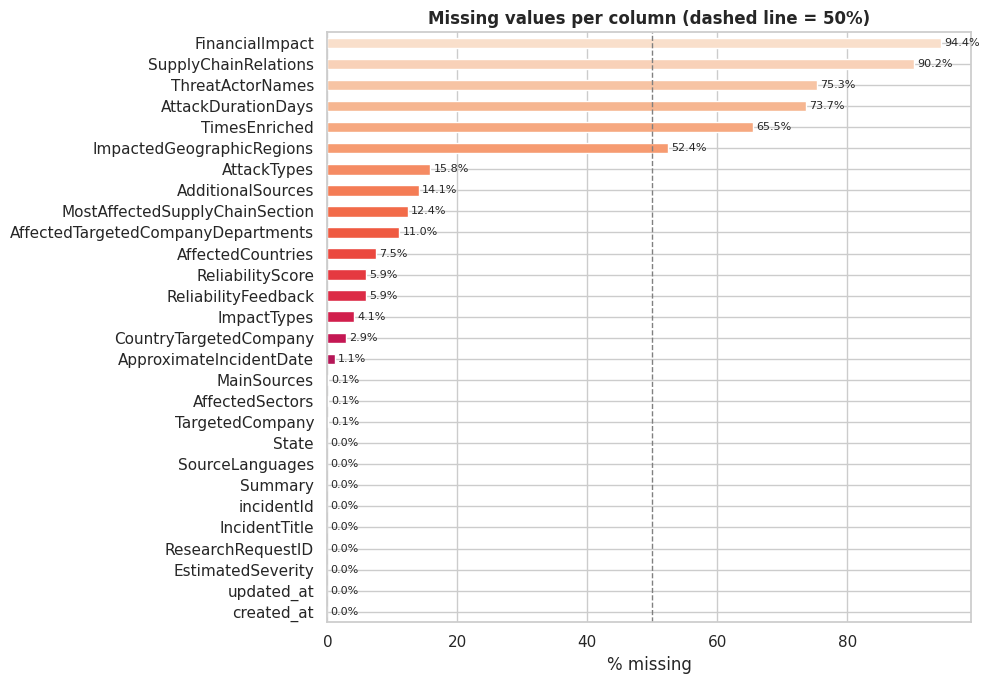

In [6]:
# --- Missingness per column ---
null_pct = df_raw.isna().mean().sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=(10, 7))
null_pct.plot.barh(ax=ax, color=sns.color_palette("rocket_r", len(null_pct)))
ax.invert_yaxis()
ax.axvline(50, ls="--", lw=1, color="grey")
for i, v in enumerate(null_pct):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=8)
ax.set_xlabel("% missing"); ax.set_title("Missing values per column (dashed line = 50%)")
plt.tight_layout(); plt.show()

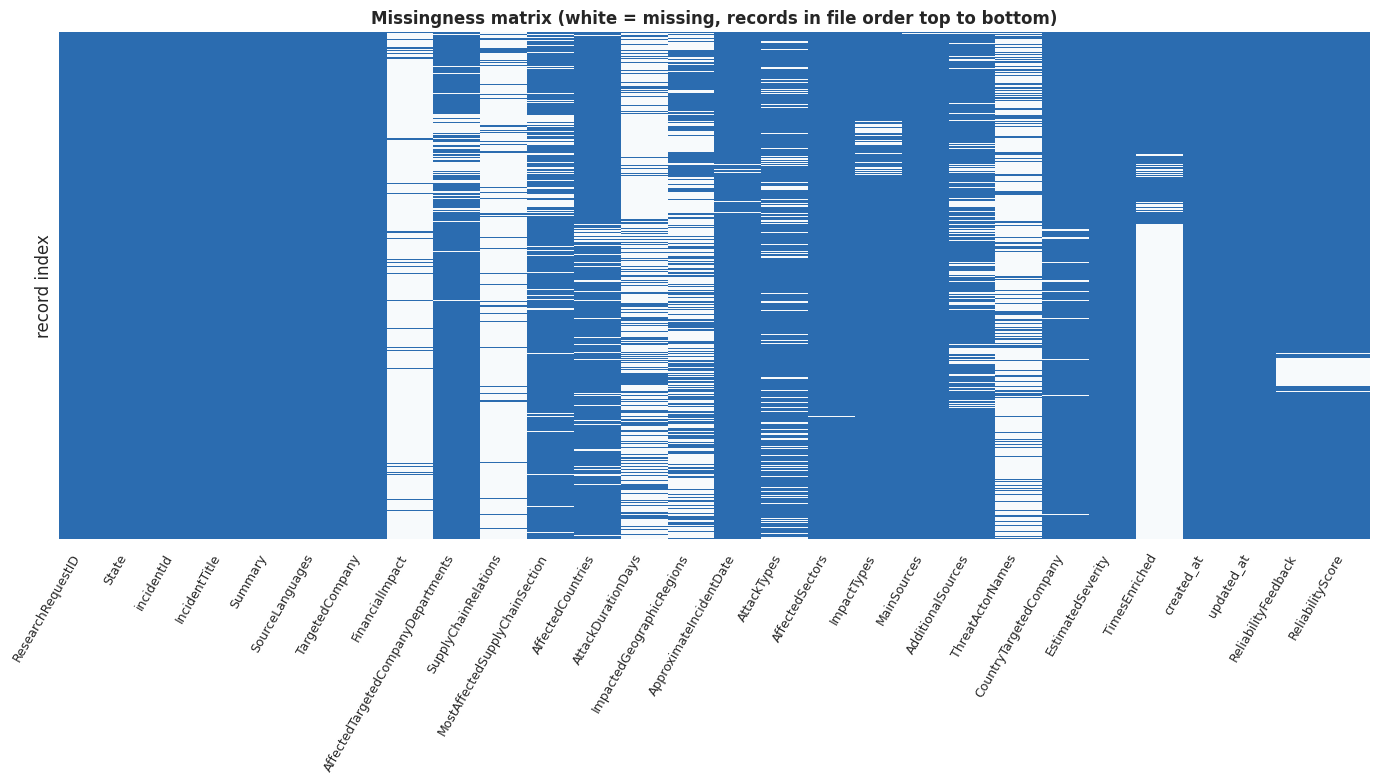

In [7]:
# --- Missingness matrix (records x columns), laid out like the spreadsheet ---
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(df_raw.isna(), cbar=False, cmap=[BLUE, "#f7fafc"], ax=ax, yticklabels=False)
ax.set_xticks(np.arange(df_raw.shape[1]) + 0.5)
ax.set_xticklabels(df_raw.columns, rotation=60, ha="right", fontsize=9)
ax.set_title("Missingness matrix (white = missing, records in file order top to bottom)")
ax.set_ylabel("record index"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

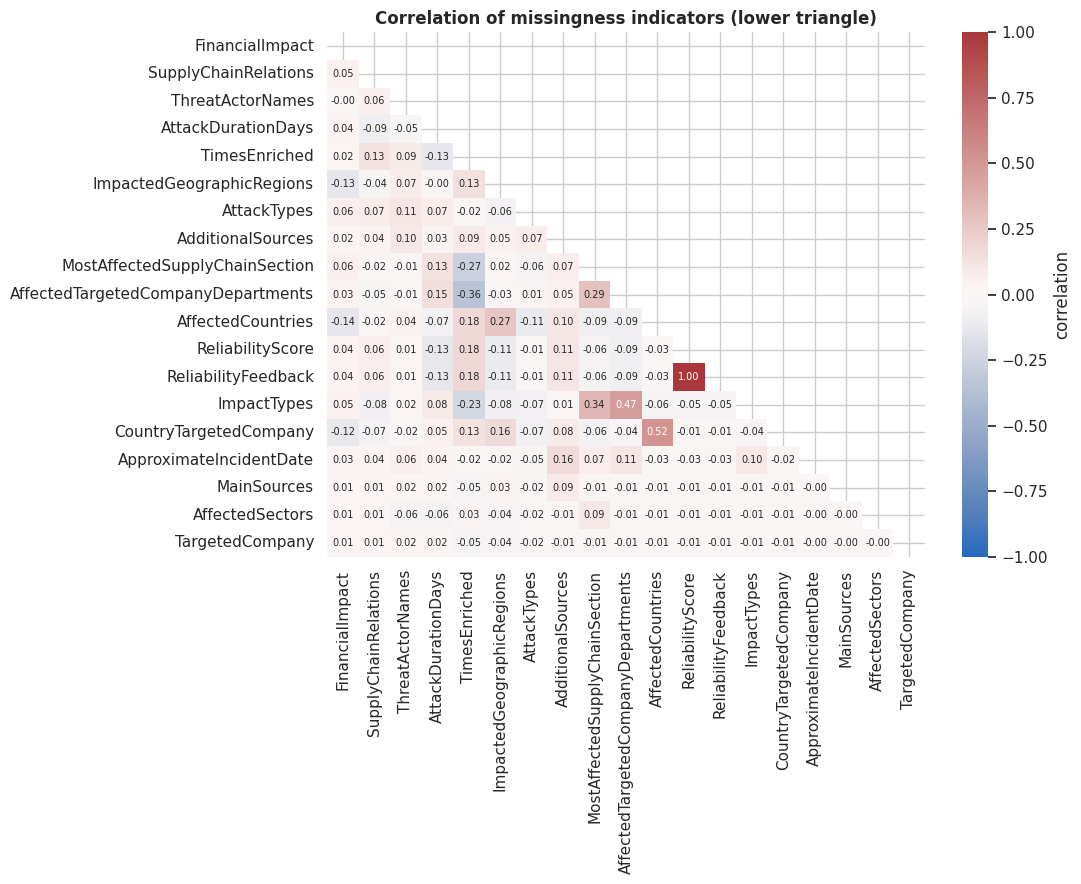

,correlation,variable_1,variable_2
0,1.000,ReliabilityScore,ReliabilityFeedback
1,0.519,AffectedCountries,CountryTargetedCompany
2,0.469,AffectedTargetedCompanyDepartments,ImpactTypes
3,-0.359,TimesEnriched,AffectedTargetedCompanyDepartments
4,0.342,MostAffectedSupplyChainSection,ImpactTypes
5,0.292,MostAffectedSupplyChainSection,AffectedTargetedCompanyDepartments
6,0.272,ImpactedGeographicRegions,AffectedCountries
7,-0.271,TimesEnriched,MostAffectedSupplyChainSection


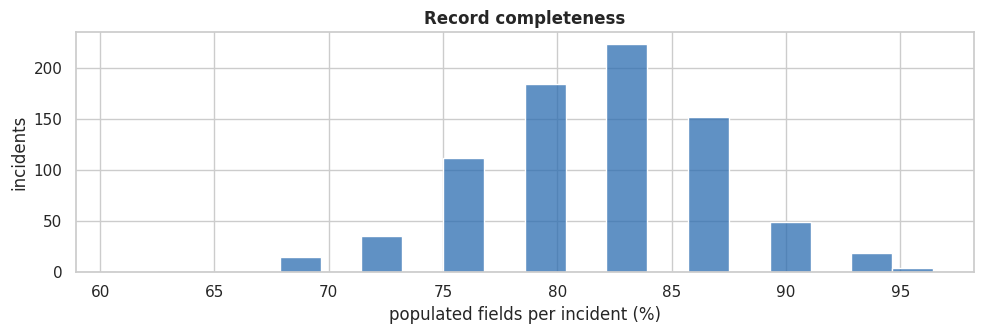

{'count': 797.0, 'mean': 81.0, 'std': 5.3, 'min': 60.7, '25%': 78.6, '50%': 82.1, '75%': 85.7, 'max': 96.4}


In [8]:
# --- Which fields are missing together? (correlation of missingness indicators) ---
miss_cols = null_pct[null_pct > 0].index.tolist()
miss_corr = df_raw[miss_cols].isna().astype(int).corr()
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(miss_corr, dtype=bool))
sns.heatmap(miss_corr, mask=mask, cmap="vlag", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f",
            annot_kws={"fontsize": 7}, ax=ax, cbar_kws={"label": "correlation"})
ax.set_title("Correlation of missingness indicators (lower triangle)")
plt.tight_layout(); plt.show()

pairs = [(miss_corr.loc[a, b], a, b) for i, a in enumerate(miss_cols) for b in miss_cols[i + 1:]]
top_pairs_missing = pd.DataFrame(sorted(pairs, key=lambda t: -abs(t[0]))[:8], columns=["correlation", "variable_1", "variable_2"])
display(top_pairs_missing.round(3))

# Row-level completeness: share of the 28 raw fields populated per incident
df["row_completeness_pct"] = df_raw.notna().mean(axis=1) * 100
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.histplot(df["row_completeness_pct"], bins=20, color=BLUE, ax=ax)
ax.set_xlabel("populated fields per incident (%)"); ax.set_ylabel("incidents"); ax.set_title("Record completeness")
plt.tight_layout(); plt.show()
print(df["row_completeness_pct"].describe().round(1).to_dict())

### Interpretation

Missingness is concentrated, not diffuse. Six fields are missing in at least half of the records: `FinancialImpact` (**94.4%**), `SupplyChainRelations` (**90.2%**), `ThreatActorNames` (**75.3%**), `AttackDurationDays` (**73.7%**), `TimesEnriched` (**65.5%**) and `ImpactedGeographicRegions` (**52.4%**). The fields SCOUT depends on are nearly complete: `Summary` and `IncidentTitle` 0%, `AffectedSectors` 0.1%, `ImpactTypes` 4.1%, `AffectedTargetedCompanyDepartments` 11.0%, `MostAffectedSupplyChainSection` 12.4% and `AttackTypes` 15.8%. The matrix shows no block of empty records; gaps are scattered, and the typical incident has **82%** of its fields filled (minimum 61%).

The co-missingness matrix adds three patterns. `ReliabilityScore` and `ReliabilityFeedback` are always missing together (ρ = 1.00): they come from the same verification step, so 47 records were never verified. Departments, impact types and supply-chain section tend to be missing together (ρ = 0.29–0.47), meaning a subset of records is under-classified rather than each field failing independently. `TimesEnriched` is *negatively* related to those gaps (ρ ≈ −0.27 to −0.36): enriched records were precisely the ones with classification gaps, which is consistent with the enrichment workflow in §11. This supports keeping sparse fields as optional context and never imputing them.

## 1.4 Duplicates and incident identity
Three complementary checks: (1) exact and string-level duplicates; (2) the spec's duplicate-analysis identity `TargetedCompany + CountryTargetedCompany` (§12.2), under which the date alone must not separate duplicates (§12.3); (3) the same company recorded under *different* countries, which the spec key cannot see. Semantic (paraphrased) duplicates are tested with TF-IDF in Part 3.

In [9]:
# --- (1) Exact and string-level duplicates ---
def light_norm(text):
    """Used ONLY for duplicate detection: NFKC, collapse whitespace, lowercase."""
    return re.sub(r"\s+", " ", unicodedata.normalize("NFKC", str(text))).strip().lower()

dup_checks = pd.DataFrame({
    "check": ["Exact duplicate rows", "Duplicate incidentId", "Duplicate IncidentTitle", "Duplicate Summary",
              "Duplicate IncidentTitle (NFKC + lowercase)", "Duplicate Summary (NFKC + lowercase)"],
    "count": [df_raw.duplicated().sum(), df["incidentId"].duplicated().sum(), df["IncidentTitle"].duplicated().sum(),
              df["Summary"].duplicated().sum(), df["IncidentTitle"].map(light_norm).duplicated().sum(),
              df["Summary"].dropna().map(light_norm).duplicated().sum()]})
display(dup_checks)
assert df["incidentId"].notna().all() and df["incidentId"].is_unique

,check,count
0,Exact duplicate rows,0
1,Duplicate incidentId,0
2,Duplicate IncidentTitle,0
3,Duplicate Summary,0
4,Duplicate IncidentTitle (NFKC + lowercase),0
5,Duplicate Summary (NFKC + lowercase),0


In [10]:
# --- (2) Spec identity key (§12.2): same TargetedCompany + CountryTargetedCompany ---
ID_KEY = ["TargetedCompany", "CountryTargetedCompany"]
df["identity_key_repeat"] = df.groupby(ID_KEY)["incidentId"].transform("size").fillna(0) > 1
repeats = df[df["identity_key_repeat"]].sort_values(ID_KEY + ["incident_date"])
print(f"Identity keys used more than once: {repeats.groupby(ID_KEY).ngroups} ({len(repeats)} records)")
display(repeats[ID_KEY + ["incident_date", "IncidentTitle", "AttackTypes"]])

# --- (3) Same company under any country (catches inconsistent CountryTargetedCompany) ---
comp = df["TargetedCompany"].dropna()
same_company = df[df["TargetedCompany"].isin(comp[comp.duplicated()])]
cross_country = same_company[~same_company["identity_key_repeat"]]
print(f"Company names used more than once: {same_company['TargetedCompany'].nunique()} ({len(same_company)} records); "
      f"{len(cross_country)} of them differ only by country")
display(same_company[["TargetedCompany", "CountryTargetedCompany", "IncidentTitle", "incident_date", "AttackTypes"]]
        .sort_values(["TargetedCompany", "incident_date"]))

Identity keys used more than once: 6 (12 records)


,TargetedCompany,CountryTargetedCompany,incident_date,IncidentTitle,AttackTypes
67,FOXCONN,MEX,2020-11-29,Ransomware at FOXCONN Mexico facility (Nov 2020),"RANSOMWARE,DATA_EXFILTRATION,DATA_DESTRUCTION"
248,FOXCONN,MEX,2022-05-31,Foxconn Tijuana plant ransomware disrupts production; recovery via capacity adjustments,RANSOMWARE
263,INSTITUTO NACIONAL DE VIGILANCIA DE MEDICAMENTOS Y ALIMENTOS,COL,2022-02-06,"Ransomware at Colombia’s INVIMA disables platforms, delaying trade procedures",RANSOMWARE
292,INSTITUTO NACIONAL DE VIGILANCIA DE MEDICAMENTOS Y ALIMENTOS,COL,2022-10-03,"Invima suspends procedures after Oct. 3, 2022 hack; deadlines paused to Oct. 31",RANSOMWARE
470,INTERNET ARCHIVE,USA,2024-05-26,Sustained DDoS attack repeatedly knocks Internet Archive services offline,DDOS
418,INTERNET ARCHIVE,USA,2024-10-09,DDoS attacks knock Internet Archive and Open Library services offline,DDOS
441,MEDUZA,LVA,2024-03-11,DDoS campaign degrades and intermittently disables Meduza,DDOS
479,MEDUZA,LVA,2024-04-23,DDoS campaign degrades access to Meduza's website,DDOS
626,ORION TELECOM,RUS,2025-12-11,DDoS attack disrupts Orion Telecom connectivity in Krasnoyarsk,DDOS
524,ORION TELECOM,RUS,2026-05-24,DDoS waves disrupt Orion Telecom home internet services,DDOS


Company names used more than once: 9 (19 records); 7 of them differ only by country


,TargetedCompany,CountryTargetedCompany,IncidentTitle,incident_date,AttackTypes
67,FOXCONN,MEX,Ransomware at FOXCONN Mexico facility (Nov 2020),2020-11-29,"RANSOMWARE,DATA_EXFILTRATION,DATA_DESTRUCTION"
248,FOXCONN,MEX,Foxconn Tijuana plant ransomware disrupts production; recovery via capacity adjustments,2022-05-31,RANSOMWARE
43,FOXCONN,TWN,Cyberattack disrupts FOXCONN North American factories; NITROGEN claims,2026-05-12,"UNAUTHORIZED_ACCESS, EXTORTION"
263,INSTITUTO NACIONAL DE VIGILANCIA DE MEDICAMENTOS Y ALIMENTOS,COL,"Ransomware at Colombia’s INVIMA disables platforms, delaying trade procedures",2022-02-06,RANSOMWARE
292,INSTITUTO NACIONAL DE VIGILANCIA DE MEDICAMENTOS Y ALIMENTOS,COL,"Invima suspends procedures after Oct. 3, 2022 hack; deadlines paused to Oct. 31",2022-10-03,RANSOMWARE
470,INTERNET ARCHIVE,USA,Sustained DDoS attack repeatedly knocks Internet Archive services offline,2024-05-26,DDOS
418,INTERNET ARCHIVE,USA,DDoS attacks knock Internet Archive and Open Library services offline,2024-10-09,DDOS
233,LKQ,USA,LKQ 8-K: Cyber incident disrupted Canadian business unit operations for weeks,2024-11-13,UNAUTHORIZED_ACCESS
404,LKQ,CAN,LKQ cyberattack disrupts Canadian business unit for several weeks,2024-11-13,UNAUTHORIZED_ACCESS
441,MEDUZA,LVA,DDoS campaign degrades and intermittently disables Meduza,2024-03-11,DDOS


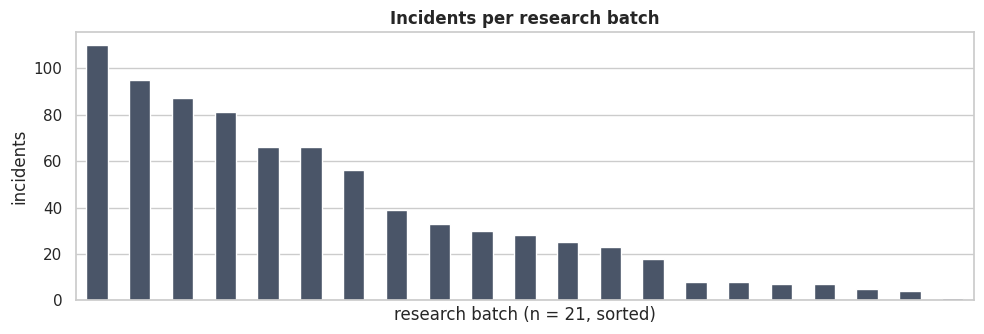

Top 5 batches hold 439 incidents (55% of the dataset)


In [11]:
# --- Research batches: how many incidents each ResearchRequestID produced ---
batch = df.groupby("ResearchRequestID").size().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 3.5))
batch.reset_index(drop=True).plot.bar(ax=ax, color=SLATE)
ax.set_xticks([]); ax.set_xlabel(f"research batch (n = {len(batch)}, sorted)"); ax.set_ylabel("incidents")
ax.set_title("Incidents per research batch")
plt.tight_layout(); plt.show()
print(f"Top 5 batches hold {batch.head(5).sum()} incidents ({batch.head(5).sum() / len(df):.0%} of the dataset)")

### Interpretation

There are no exact duplicate rows, IDs, titles or summaries, even after Unicode normalization and lower-casing. Two kinds of repeated companies appear, and they mean different things:

* **Same company and country (spec key): 6 companies, 12 records.** Every pair has *different dates* — Internet Archive (May and Oct 2024), Meduza (Mar and Apr 2024), Orion Telecom, Rosselkhoznadzor, INVIMA, Foxconn Mexico. These are recurring attacks on the same victim, which is legitimate and even useful for SCOUT ("this organization was hit more than once").
* **Same company, different country: 7 records.** LKQ (USA/CAN), Radiant Logistics (USA/CAN) and Sensata (USA/GBR) appear twice with the **same date** and near-identical titles. These look like the same incident recorded twice with a different `CountryTargetedCompany`; because the spec's identity key includes the country, the disagreement hides the duplicate (§7.5, §12.2). Foxconn TWN is a separate 2026 event.

Research batches are unbalanced: the top 5 of 21 batches produced **439 incidents (55%)**, so topics favoured by those requests are over-represented.

## 1.5 Cardinality of categorical and multi-label variables
Two kinds of high cardinality coexist: naturally unique fields (titles, companies, URLs) and multi-label fields whose raw strings combine several labels. For the latter, raw combinations are compared with *canonical* combinations (labels stripped, de-duplicated and sorted) and with the number of individual labels.

In [12]:
# --- Helpers to parse label cells ---
def split_labels(cell):
    """'A, B,C' -> ['A','B','C'] (stripped, upper-case); NaN -> []"""
    if pd.isna(cell):
        return []
    return [tok.strip().upper() for tok in str(cell).split(",") if tok.strip()]

def relation_roles(cell):
    """SupplyChainRelations holds 'COMPANY(ROLE)' items -> the ROLE codes (spec §7.13)."""
    return re.findall(r"\(([A-Z_]+)\)", str(cell)) if pd.notna(cell) else []

def canonical(labels):
    return ", ".join(sorted(dict.fromkeys(labels))) if labels else np.nan

for col in MULTI_COLS:
    df[f"{col}_raw_list"] = df[col].apply(split_labels)
df["SupplyChainRoles_raw_list"] = df["SupplyChainRelations"].apply(relation_roles)

rows = []
for col in MULTI_COLS + ["SupplyChainRoles"]:
    lists = df[f"{col}_raw_list"]
    rows.append({"column": col,
                 "records_with_labels": int((lists.str.len() > 0).sum()),
                 "raw_combinations": df[col].nunique() if col in df else np.nan,
                 "canonical_combinations": lists.apply(canonical).nunique(),
                 "individual_labels": lists.explode().nunique(),
                 "mean_labels_per_record": round(lists[lists.str.len() > 0].str.len().mean(), 2),
                 "max_labels": int(lists.str.len().max())})
cardinality = pd.DataFrame(rows).set_index("column")
display(cardinality)

,records_with_labels,raw_combinations,canonical_combinations,individual_labels,mean_labels_per_record,max_labels
column,,,,,,
AttackTypes,671,170.0,130,32,1.75,6
ImpactTypes,764,324.0,211,32,2.73,12
AffectedSectors,796,118.0,85,29,1.22,7
AffectedTargetedCompanyDepartments,709,138.0,82,17,1.70,7
MostAffectedSupplyChainSection,698,33.0,21,7,1.11,4
AffectedCountries,737,108.0,105,91,1.08,10
ImpactedGeographicRegions,379,204.0,203,214,1.09,8
SourceLanguages,797,70.0,48,31,1.16,3
ThreatActorNames,197,94.0,94,97,1.05,2


### Interpretation

Part of the apparent cardinality is formatting, not meaning. Sorting and de-duplicating labels reduces `ImpactTypes` from **324** raw combinations to **211**, `AffectedTargetedCompanyDepartments` from **138** to **82**, `AttackTypes` from **170** to **130** and `MostAffectedSupplyChainSection` from **33** to **21**, without discarding any label. The underlying vocabularies are small: 32 attack types, 32 impact types, 29 sector labels, 17 departments and 7 section labels (6 after remapping in 1.6). Incidents carry on average **2.73** impact labels and **1.75** attack labels. Country, region and actor fields are genuinely high-cardinality (91 countries, 214 regions, 97 actors) and are better used as filters than as grouping variables.

## 1.6 Taxonomy audit against the specification catalogs
The spec freezes the controlled vocabulary of six fields (§14) and defines when `OTHER(...)` may be used (§8.7). Every label is validated instead of guessed at. Codes such as `DOS`/`DDOS` or `SUPPLY_CHAIN_COMPROMISE`/`SOFTWARE_SUPPLY_CHAIN_COMPROMISE` are *distinct* frozen codes and must not be merged (§8.4).

In [13]:
# --- Frozen catalogs (spec §14) ---
CATALOGS = {
    "AttackTypes": {
        "ACCOUNT_TAKEOVER", "ADVERSARY_IN_THE_MIDDLE", "BACKDOOR", "BRUTE_FORCE", "BUSINESS_EMAIL_COMPROMISE",
        "CREDENTIAL_STUFFING", "CROSS_SITE_REQUEST_FORGERY", "CROSS_SITE_SCRIPTING", "CRYPTOCURRENCY_MINING",
        "DATA_BREACH", "DATA_DESTRUCTION", "DATA_EXFILTRATION", "DATA_MODIFICATION", "DOS",
        "DISABLE_SECURITY_CONTROLS", "DDOS", "EXPLOIT_MISCONFIGURATION", "EXPLOIT_VULNERABILITY", "EXTORTION",
        "HARDWARE_SUPPLY_CHAIN_COMPROMISE", "ICS_OT_COMPROMISE", "IN_MEMORY_MALWARE", "MALWARE",
        "MALWARE_DOWNLOADER", "PROMPT_BOMBING", "PASS_THE_HASH", "PASSWORD_DUMPING", "PASSWORD_SPRAYING",
        "PHISHING", "PRETEXTING", "PRIVILEGE_ABUSE", "RANSOMWARE", "REMOTE_ACCESS_TROJAN", "ROOTKIT",
        "SOCIAL_ENGINEERING", "SOFTWARE_SUPPLY_CHAIN_COMPROMISE", "SOFTWARE_UPDATE_COMPROMISE", "SPEARPHISHING",
        "SPYWARE_KEYLOGGER", "SQL_INJECTION", "SUPPLY_CHAIN_COMPROMISE", "THIRD_PARTY_PARTNER_COMPROMISE",
        "TROJAN", "UNAUTHORIZED_ACCESS", "USE_OF_STOLEN_CREDENTIALS", "WEB_APPLICATION_ATTACK", "WIPER", "WORM",
        "ZERO_DAY_EXPLOITATION"},
    "ImpactTypes": {
        "BACKLOG_OR_ORDER_ACCUMULATION", "CAPACITY_REDUCTION", "DOWNSTREAM_CUSTOMER_DISRUPTION",
        "DOWNSTREAM_PRODUCTION_INTERRUPTION", "ERP_OR_BUSINESS_SYSTEM_DISRUPTION", "FACILITY_SHUTDOWN",
        "INVENTORY_OR_DISTRIBUTION_IMPACT", "LOGISTICS_DELAY", "MATERIAL_OR_COMPONENT_SHORTAGE",
        "OPERATIONAL_DISRUPTION", "ORDER_FULFILLMENT_OR_DELIVERY_DISRUPTION", "ORDER_PROCESSING_DISRUPTION",
        "OT_OR_ICS_DISRUPTION", "PHYSICAL_DAMAGE", "PLANNING_OR_SCHEDULING_DISRUPTION", "PROCUREMENT_DISRUPTION",
        "PRODUCT_AVAILABILITY_REDUCTION", "PRODUCT_OR_PROCESS_QUALITY_IMPACT", "PRODUCT_RECALL_OR_WITHDRAWAL",
        "PRODUCTION_INTERRUPTION", "PRODUCTION_SLOWDOWN", "QUALITY_CONTROL_DISRUPTION", "SAFETY_IMPACT",
        "SERVICE_DEGRADATION", "SERVICE_UNAVAILABILITY", "SHIPPING_DISRUPTION", "SUPPLIER_DELIVERY_DELAY",
        "SUPPLIER_OPERATION_DISRUPTION", "SUPPLY_CHAIN_COORDINATION_DISRUPTION",
        "SUPPLY_CHAIN_DATA_INTEGRITY_IMPACT", "SUPPLY_CHAIN_VISIBILITY_LOSS", "SUPPLY_SHORTAGE",
        "TRANSPORTATION_DISRUPTION", "WAREHOUSING_DISRUPTION"},
    "SupplyChainRoles": {   # role of the TargetedCompany toward each materially affected organization (§7.13)
        "BUSINESS_PROCESS_OUTSOURCER", "CLOUD_SERVICE_PROVIDER", "COMPONENT_OR_MATERIAL_SUPPLIER",
        "CONTRACT_MANUFACTURER", "CONTRACTOR_OR_SUBCONTRACTOR", "CYBERSECURITY_SERVICE_PROVIDER",
        "DATA_CENTER_OR_HOSTING_PROVIDER", "DIGITAL_PLATFORM_PROVIDER", "DISTRIBUTOR_OR_RESELLER",
        "DOWNSTREAM_CUSTOMER", "ENGINEERING_OR_MAINTENANCE_SERVICE_PROVIDER", "EQUIPMENT_OR_MACHINERY_SUPPLIER",
        "HARDWARE_VENDOR_OR_MANUFACTURER", "IT_SERVICE_PROVIDER", "LOGISTICS_INFRASTRUCTURE_OPERATOR",
        "LOGISTICS_PROVIDER", "MANAGED_SERVICE_PROVIDER", "OT_ICS_SERVICE_PROVIDER",
        "PAYMENT_OR_FINANCIAL_SERVICE_PROVIDER", "SOFTWARE_VENDOR", "SUBTIER_SUPPLIER", "SYSTEM_INTEGRATOR",
        "TELECOMMUNICATIONS_PROVIDER", "THIRD_PARTY_SERVICE_PROVIDER", "TRANSPORTATION_PROVIDER",
        "UPSTREAM_SUPPLIER", "UTILITY_PROVIDER", "WAREHOUSING_PROVIDER"},
    "AffectedSectors": {
        "AGRICULTURE_FORESTRY_AND_FISHING", "CHEMICALS", "CONSTRUCTION_AND_ENGINEERING", "EDUCATION_AND_RESEARCH",
        "ENERGY_AND_UTILITIES", "ENVIRONMENTAL_AND_WASTE_SERVICES", "FINANCE_AND_INSURANCE", "FOOD_AND_BEVERAGE",
        "FUNERAL_SERVICES", "GOVERNMENT_AND_PUBLIC_ADMINISTRATION", "HEALTHCARE_AND_PUBLIC_HEALTH",
        "HOSPITALITY_AND_TRAVEL", "LOGISTICS_AND_WAREHOUSING", "MANUFACTURING", "MEDIA_AND_ENTERTAINMENT",
        "MINING_AND_RAW_MATERIALS", "MUSEUMS_AND_CULTURAL_HERITAGE", "PHARMACEUTICALS_AND_LIFE_SCIENCES",
        "PHYSICAL_SECURITY_SERVICES", "PROFESSIONAL_AND_BUSINESS_SERVICES", "REAL_ESTATE_AND_COMMERCIAL_FACILITIES",
        "RETAIL", "TECHNOLOGY_AND_IT_SERVICES", "TELECOMMUNICATIONS", "TRANSPORTATION", "WATER_AND_WASTEWATER",
        "WHOLESALE_AND_DISTRIBUTION"},
    "AffectedTargetedCompanyDepartments": {
        "ACCOUNTING", "CUSTOMER_SERVICE", "DISTRIBUTION_AND_FULFILLMENT", "ENGINEERING_AND_MAINTENANCE",
        "FACILITIES_AND_PHYSICAL_OPERATIONS", "FINANCE", "HUMAN_RESOURCES", "INFORMATION_TECHNOLOGY",
        "INVENTORY_MANAGEMENT", "LEGAL_RISK_AND_COMPLIANCE", "LOGISTICS_AND_TRANSPORTATION", "MARKETING",
        "ORDER_MANAGEMENT", "PROCUREMENT_AND_SOURCING", "PRODUCTION_AND_MANUFACTURING", "QUALITY_MANAGEMENT",
        "RETURNS_AND_REVERSE_LOGISTICS", "SALES", "SUPPLY_CHAIN_PLANNING", "WAREHOUSING"},
    "MostAffectedSupplyChainSection": {
        "DISTRIBUTION&FULFILLMENT", "PROCUREMENT&SOURCING", "PRODUCTION&MANUFACTURING", "WAREHOUSING",
        "SALES_RETAIL&ECOMMERCE", "SERVICE_DELIVERY"},
}
OTHER_ALLOWED = {"AttackTypes", "ImpactTypes", "SupplyChainRoles", "AffectedSectors"}   # §8.7 fallback policy
OTHER_RX = re.compile(r"^OTHER\(([A-Z0-9_&]+)\)$")

# 1) Separator consistency
sep_rows = [{"field": c, "cells_with_', '": int(df[c].dropna().str.contains(r",\s").sum()),
             "cells_with_','": int(df[c].dropna().str.contains(r",\S").sum())} for c in CATALOGS if c in df]
display(pd.DataFrame(sep_rows).set_index("field"))

# 2) Every label checked against its catalog and the OTHER(...) policy
issues, off_catalog = [], {i: [] for i in df.index}
for col, catalog in CATALOGS.items():
    for idx, labels in df[f"{col}_raw_list"].items():
        for lab in labels:
            if lab in catalog:
                continue
            m = OTHER_RX.match(lab)
            if m and m.group(1) in catalog:
                issue = "OTHER(...) duplicates a frozen code -> remap"
            elif m and col not in OTHER_ALLOWED:
                issue = "OTHER(...) forbidden in this field"
            elif m:
                issue = "OTHER(...) permitted"
            else:
                issue = "not in catalog (typo / truncation)"
            issues.append({"field": col, "label": lab, "issue": issue})
            if issue != "OTHER(...) permitted":
                off_catalog[idx].append(f"{col}:{lab}")
df["off_catalog_labels"] = pd.Series(off_catalog)
issues = pd.DataFrame(issues)
display(issues.value_counts().rename("records").reset_index())

# 3) Catalog coverage: frozen codes that never occur (SCOUT cannot retrieve examples of them)
coverage = pd.DataFrame([{"field": col, "catalog_size": len(cat),
                          "codes_used": len(cat & set(df[f"{col}_raw_list"].explode().dropna())),
                          "unused_codes": ", ".join(sorted(cat - set(df[f"{col}_raw_list"].explode().dropna())))}
                         for col, cat in CATALOGS.items()]).set_index("field")
display(coverage)

# 4) Format checks for the geographic and language fields (§7.15–7.17)
regions = df["ImpactedGeographicRegions_raw_list"].explode().dropna()
bad_regions = regions[~regions.str.match(r"^[A-Z_]+\([A-Z]{3}\)$")]
print(f"ImpactedGeographicRegions items not in REGION(ISO3) form: {len(bad_regions)} of {len(regions)} "
      f"-> {bad_regions.value_counts().head(8).to_dict()}")
countries = df["AffectedCountries_raw_list"].explode().dropna()
print(f"AffectedCountries not ISO-3: {(~countries.str.match(r'^[A-Z]{3}$')).sum()} | "
      f"CountryTargetedCompany not ISO-3: {(~df['CountryTargetedCompany'].dropna().str.match(r'^[A-Z]{3}$')).sum()}")

,"cells_with_', '","cells_with_','"
field,,
AttackTypes,200,100
ImpactTypes,459,226
AffectedSectors,91,55
AffectedTargetedCompanyDepartments,211,115
MostAffectedSupplyChainSection,47,23


,field,label,issue,records
0,MostAffectedSupplyChainSection,OTHER(SERVICE_DELIVERY),OTHER(...) duplicates a frozen code -> remap,20
1,AffectedSectors,OTHER(MUSEUMS_AND_CULTURAL_HERITAGE),OTHER(...) duplicates a frozen code -> remap,2
2,AffectedSectors,OTHER(LABOR_UNIONS),OTHER(...) permitted,1
3,AffectedSectors,OTHER(FUNERAL_SERVICES),OTHER(...) duplicates a frozen code -> remap,1
4,AffectedSectors,OTHER(PHYSICAL_SECURITY_SERVICES),OTHER(...) duplicates a frozen code -> remap,1
5,ImpactTypes,DOWNSTREAM,not in catalog (typo / truncation),1
6,SupplyChainRoles,PARENT_ORGANIZATION,not in catalog (typo / truncation),1
7,SupplyChainRoles,SUBSIDIARY,not in catalog (typo / truncation),1


,catalog_size,codes_used,unused_codes
field,,,
AttackTypes,49,32,"ADVERSARY_IN_THE_MIDDLE, BUSINESS_EMAIL_COMPROMISE, CROSS_SITE_REQUEST_FORGERY, CROSS_SITE_SCRIPTING, DISABLE_SECURI..."
ImpactTypes,34,31,"PHYSICAL_DAMAGE, PRODUCT_RECALL_OR_WITHDRAWAL, QUALITY_CONTROL_DISRUPTION"
SupplyChainRoles,28,15,"CLOUD_SERVICE_PROVIDER, CONTRACT_MANUFACTURER, DATA_CENTER_OR_HOSTING_PROVIDER, DISTRIBUTOR_OR_RESELLER, ENGINEERING..."
AffectedSectors,27,25,"CHEMICALS, ENVIRONMENTAL_AND_WASTE_SERVICES"
AffectedTargetedCompanyDepartments,20,17,"QUALITY_MANAGEMENT, RETURNS_AND_REVERSE_LOGISTICS, SUPPLY_CHAIN_PLANNING"
MostAffectedSupplyChainSection,6,6,


ImpactedGeographicRegions items not in REGION(ISO3) form: 37 of 413 -> {'UNITED KINGDOM(GBR)': 5, 'LATIN AMERICA(AR)': 2, 'NEWFOUNDLAND AND LABRADOR(CAN)': 2, 'KRASNOYARSK KRAI(RUS)': 2, 'NEW YORK(USA)': 2, 'ASIA(JP)': 1, 'LATIN AMERICA(CO)': 1, 'SOUTH DAKOTA(USA)': 1}
AffectedCountries not ISO-3: 0 | CountryTargetedCompany not ISO-3: 0


In [14]:
# --- Analysis labels: OTHER(X) that duplicates a frozen code is mapped to X (spec §8.7) ---
# Every chart and statistic from here on uses these lists, so SERVICE_DELIVERY is not split in two.
# Labels that are not in any catalog (e.g. a truncated 'DOWNSTREAM') are kept and flagged, never guessed.
def remap_other(labels, catalog):
    out = []
    for lab in labels:
        m = OTHER_RX.match(lab)
        out.append(m.group(1) if (m and m.group(1) in catalog) else lab)
    return list(dict.fromkeys(out))                       # de-duplicate, keep order

for col in MULTI_COLS + ["SupplyChainRoles"]:
    raw = df[f"{col}_raw_list"]
    df[f"{col}_list"] = raw.apply(lambda l: remap_other(l, CATALOGS[col])) if col in CATALOGS else raw

def has_redundant_other(labels, catalog):
    return any((m := OTHER_RX.match(x)) and m.group(1) in catalog for x in labels)
remapped = {c: int(df[f"{c}_raw_list"].apply(has_redundant_other, catalog=CATALOGS[c]).sum()) for c in CATALOGS}
print("Records with a redundant OTHER(...) remapped to its frozen code:", {c: n for c, n in remapped.items() if n})

Records with a redundant OTHER(...) remapped to its frozen code: {'AffectedSectors': 4, 'MostAffectedSupplyChainSection': 20}


### Interpretation

Conformity with the spec is high but not perfect:

* **Redundant `OTHER(...)`**: 20 records use `OTHER(SERVICE_DELIVERY)` in `MostAffectedSupplyChainSection`, where `OTHER` is forbidden and `SERVICE_DELIVERY` is a frozen code; 4 sector values (`OTHER(MUSEUMS_…)`, `OTHER(FUNERAL_SERVICES)`, `OTHER(PHYSICAL_SECURITY_SERVICES)`) also have frozen codes. These are remapped for analysis, so `SERVICE_DELIVERY` counts 365 incidents instead of being split 345 + 20.
* **Labels in no catalog**: `DOWNSTREAM` in `ImpactTypes` (probably a truncated `DOWNSTREAM_…` code, but which one cannot be told), and the roles `SUBSIDIARY` and `PARENT_ORGANIZATION`. They are kept and flagged, not guessed.
* `OTHER(LABOR_UNIONS)` is a legitimate use of the fallback.
* **Unused codes**: 17 of 49 attack types, 13 of 28 supply-chain roles and 3 of 34 impact types never occur, so SCOUT cannot retrieve examples of, for instance, business-email compromise or phishing-led incidents from this export.
* **Format**: separators are mixed in every label field (e.g. 459 `ImpactTypes` cells use `", "` and 226 use `","`), and 37 of 413 region values break the `REGION(ISO3)` convention (`UNITED KINGDOM(GBR)`, `ASIA(JP)`). Country fields are all valid ISO-3.

## 1.7 Evidence reliability (spec scale)
`ReliabilityScore` (0–100) measures how well the record is supported by evidence; **≥ 85 means "TRACE-ready"** (§10.4). Reliability is distinct from eligibility: a published record may still be below the threshold (§10.6).

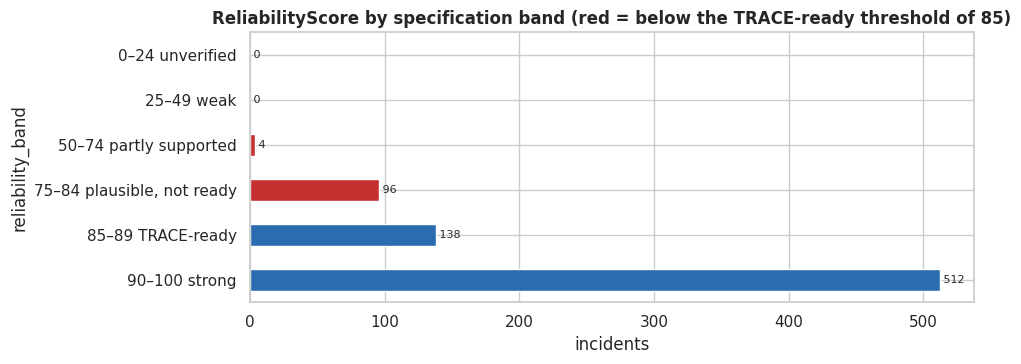

Scored: 750 | TRACE-ready (>=85): 650 (86.7% of scored) | published below 85: 100 | unscored: 47


In [15]:
# --- ReliabilityScore read through the spec's bands (§10.4) ---
REL_BINS   = [-0.1, 24, 49, 74, 84, 89, 100]
REL_LABELS = ["0–24 unverified", "25–49 weak", "50–74 partly supported",
              "75–84 plausible, not ready", "85–89 TRACE-ready", "90–100 strong"]
df["reliability_band"] = pd.cut(df["ReliabilityScore"], bins=REL_BINS, labels=REL_LABELS)

bands = df["reliability_band"].value_counts().reindex(REL_LABELS)
fig, ax = plt.subplots(figsize=(10, 3.8))
bands.plot.barh(ax=ax, color=[RED] * 4 + [BLUE] * 2)
bar_labels(ax, bands.values)
ax.invert_yaxis(); ax.set_xlabel("incidents")
ax.set_title("ReliabilityScore by specification band (red = below the TRACE-ready threshold of 85)")
plt.tight_layout(); plt.show()

scored = df["ReliabilityScore"].notna().sum()
ready  = (df["ReliabilityScore"] >= 85).sum()
print(f"Scored: {scored} | TRACE-ready (>=85): {ready} ({ready / scored:.1%} of scored) | "
      f"published below 85: {(df['ReliabilityScore'] < 85).sum()} | unscored: {df['ReliabilityScore'].isna().sum()}")

### Interpretation

Of the **750** scored records, **650 (86.7%)** reach the TRACE-ready threshold; 512 are in the strongest band (90–100). Still, **100 published records** sit below 85 (96 of them "plausible, not ready") and **47** have no score at all. Reliability is therefore a useful ranking signal for SCOUT: a weakly supported case can be shown with a caveat or down-ranked rather than presented as equally solid evidence.

# Part 2 — Univariate analysis

One variable at a time: numeric distributions and extreme values, label frequencies of the multi-label fields, time, geography, threat actors, and the text fields as a corpus.

## 2.1 Numeric distributions
Histograms describe shape and boxplots describe spread. `FinancialImpact` (USD millions, §7.8) and `AttackDurationDays` (§7.7) are heavy-tailed, so they are shown on a log scale **for visualization only**; stored values are never transformed.

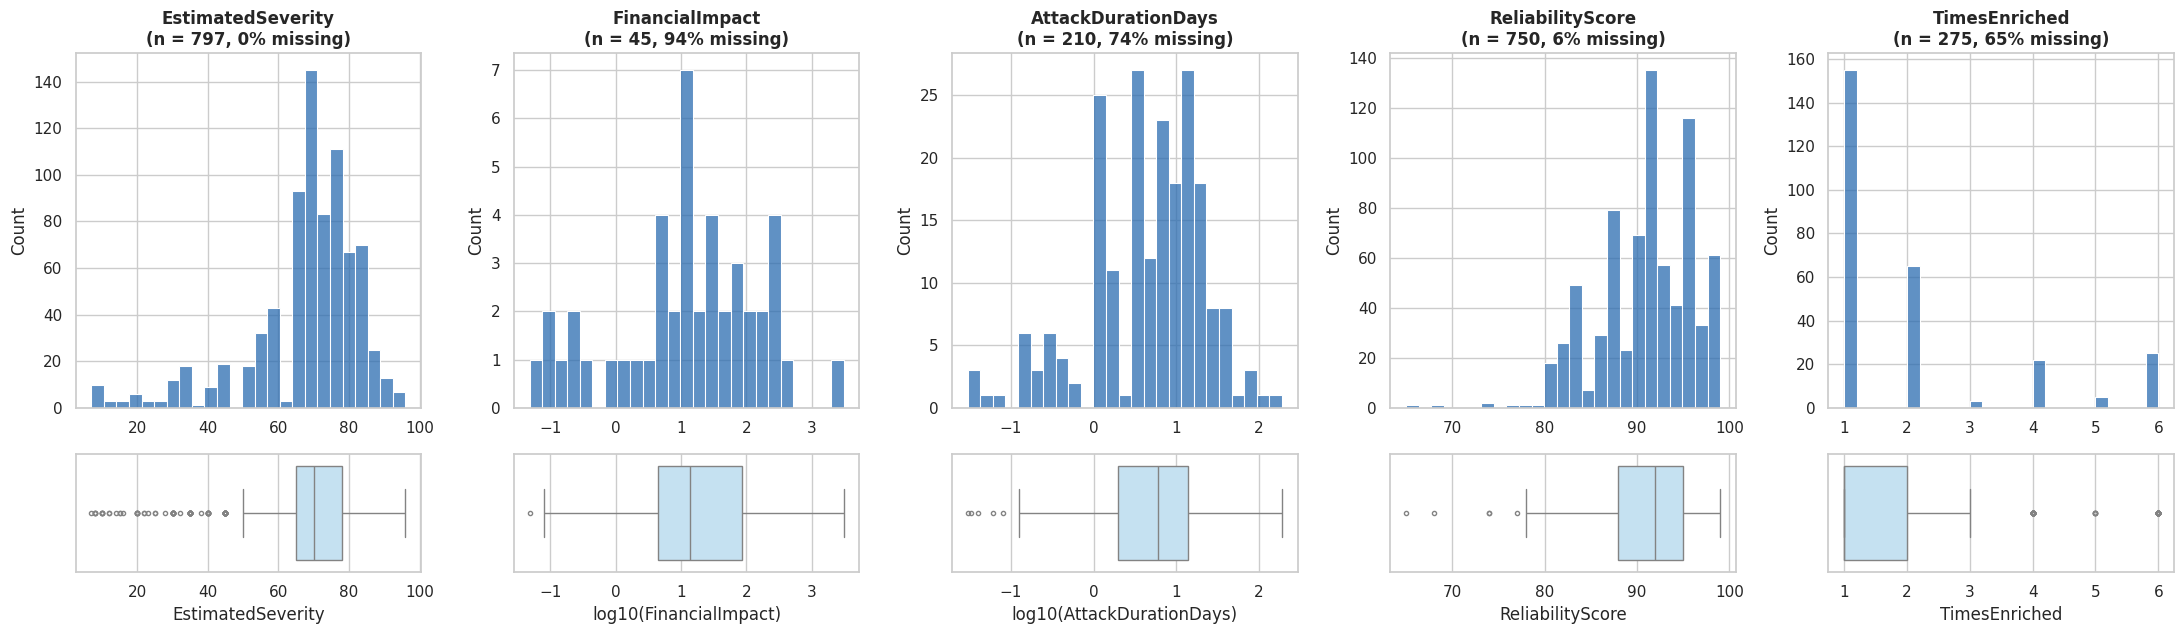

,count,mean,std,min,25%,50%,75%,max,skewness
EstimatedSeverity,797.0,67.78,16.02,7.00,65.0,70.0,78.0,96.0,-1.57
FinancialImpact,45.0,127.11,461.33,0.05,4.4,13.5,85.0,3090.0,6.29
AttackDurationDays,210.0,11.60,19.33,0.03,2.0,6.0,14.0,190.0,5.25
ReliabilityScore,750.0,91.05,5.00,65.00,88.0,92.0,95.0,99.0,-0.79
TimesEnriched,275.0,2.03,1.59,1.00,1.0,1.0,2.0,6.0,1.57


In [16]:
# --- Histograms (top) and boxplots (bottom) for every numeric field ---
LOG_COLS = ["FinancialImpact", "AttackDurationDays"]
fig, axes = plt.subplots(2, 5, figsize=(22, 6.5), gridspec_kw={"height_ratios": [3, 1]})
for k, col in enumerate(NUM_COLS):
    data = df[col].dropna()
    shown = np.log10(data) if col in LOG_COLS else data
    xlabel = f"log10({col})" if col in LOG_COLS else col
    sns.histplot(shown, bins=25, ax=axes[0, k], color=BLUE)
    axes[0, k].set_title(f"{col}\n(n = {len(data)}, {df[col].isna().mean():.0%} missing)")
    axes[0, k].set_xlabel("")
    sns.boxplot(x=shown, ax=axes[1, k], color=LIGHT, fliersize=3)
    axes[1, k].set_xlabel(xlabel)
plt.tight_layout(); plt.show()

desc = df[NUM_COLS].describe().T
desc["skewness"] = df[NUM_COLS].skew()
display(desc.round(2))

## 2.2 Extreme values
The IQR rule is used as a *screening* tool, not as a deletion rule: in an incident database the extreme cases (multi-month outages, billion-dollar losses) are often the most informative ones.

In [17]:
# --- IQR screening (flags only) and the actual extreme records ---
outlier_rows = []
for col in NUM_COLS:
    s = df[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    flag = (df[col] < lo) | (df[col] > hi)
    df[f"iqr_outlier_{col}"] = flag.fillna(False)
    outlier_rows.append({"variable": col, "Q1": q1, "Q3": q3, "lower": lo, "upper": hi,
                         "outliers": int(flag.sum()), "outliers_%_of_non_null": round(flag.sum() / len(s) * 100, 1)})
display(pd.DataFrame(outlier_rows).set_index("variable").round(2))

print("Largest financial impacts (USD millions):")
display(df.nlargest(5, "FinancialImpact")[["IncidentTitle", "FinancialImpact", "EstimatedSeverity"]])
print("Longest attacks:")
display(df.nlargest(5, "AttackDurationDays")[["IncidentTitle", "AttackDurationDays", "EstimatedSeverity"]])
print("Lowest severity:")
display(df.nsmallest(5, "EstimatedSeverity")[["IncidentTitle", "EstimatedSeverity", "AttackTypes"]])

,Q1,Q3,lower,upper,outliers,outliers_%_of_non_null
variable,,,,,,
EstimatedSeverity,65.0,78.0,45.5,97.5,87,10.9
FinancialImpact,4.4,85.0,-116.5,205.9,6,13.3
AttackDurationDays,2.0,14.0,-16.0,32.0,14,6.7
ReliabilityScore,88.0,95.0,77.5,105.5,5,0.7
TimesEnriched,1.0,2.0,-0.5,3.5,52,18.9


Largest financial impacts (USD millions):


,IncidentTitle,FinancialImpact,EstimatedSeverity
495,Change Healthcare ransomware disrupted U.S. claims and payment infrastructure,3090.0,94
35,Cyberattack on CLOROX disrupts manufacturing and shipments; orders delayed and cancellations reported,356.0,75
324,Drift Protocol exploit drains approximately $295.7 million and forces protocol shutdown,295.7,94
315,LayerZero RPC compromise enables $292 million KelpDAO bridge theft,292.0,94
33,Cyberattack on CO OPERATIVE GROUP disrupts logistics and stock availability across UK stores,274.0,80


Longest attacks:


,IncidentTitle,AttackDurationDays,EstimatedSeverity
613,Cyberattack disrupts Fort Bend County Libraries network services for six months,190.0,79
718,Seattle Public Library ransomware attack disrupts library services for months,102.0,73
777,Cyber incident disables Transport for London fare and customer-service functions,94.0,74
60,COPPEL cyberattack knocks ecommerce offline; 3‑month recovery,90.0,80
64,SICT cyberattack suspends procedures nationwide through 2022,69.0,60


Lowest severity:


,IncidentTitle,EstimatedSeverity,AttackTypes
205,NDPC opens investigation into alleged Remita and Sterling Bank data breaches,7,NaN
130,Port of Rotterdam website hit by DDoS; core port systems unaffected,8,DDOS
131,Port of Amsterdam website disrupted by DDoS,8,DDOS
132,Port of Den Helder website outage after DDoS,8,DDOS
144,Clarksons discloses 2017 data breach and ransom demand; business operations unaffected,8,"UNAUTHORIZED_ACCESS,DATA_EXFILTRATION,DATA_BREACH,EXTORTION"


### Interpretation

The numeric fields differ greatly in coverage and shape. `EstimatedSeverity` is complete, centred around a median of **70** and left-skewed (−1.57): most incidents are serious because the spec only admits incidents with material consequences, and the **87** low-severity IQR outliers (≤ 45) are cases such as port websites hit by DDoS "with core systems unaffected" or breaches "with operations unaffected". `FinancialImpact` exists for only **45** records (USD millions, median 13.5, maximum 3,090 for Change Healthcare) and `AttackDurationDays` for **210** (median 6 days, maximum 190 for Fort Bend County Libraries); both are strongly right-skewed (6.3 and 5.3). `ReliabilityScore` is high and tight (median 92). All extreme values are real, documented incidents, so they are kept and only flagged.

## 2.3 Multi-label categorical distributions
Labels are counted per incident after splitting the comma-separated cells (Part 1.5) and remapping redundant `OTHER(...)` values (Part 1.6). The six fields shown are the ones SCOUT's questionnaire can map onto.

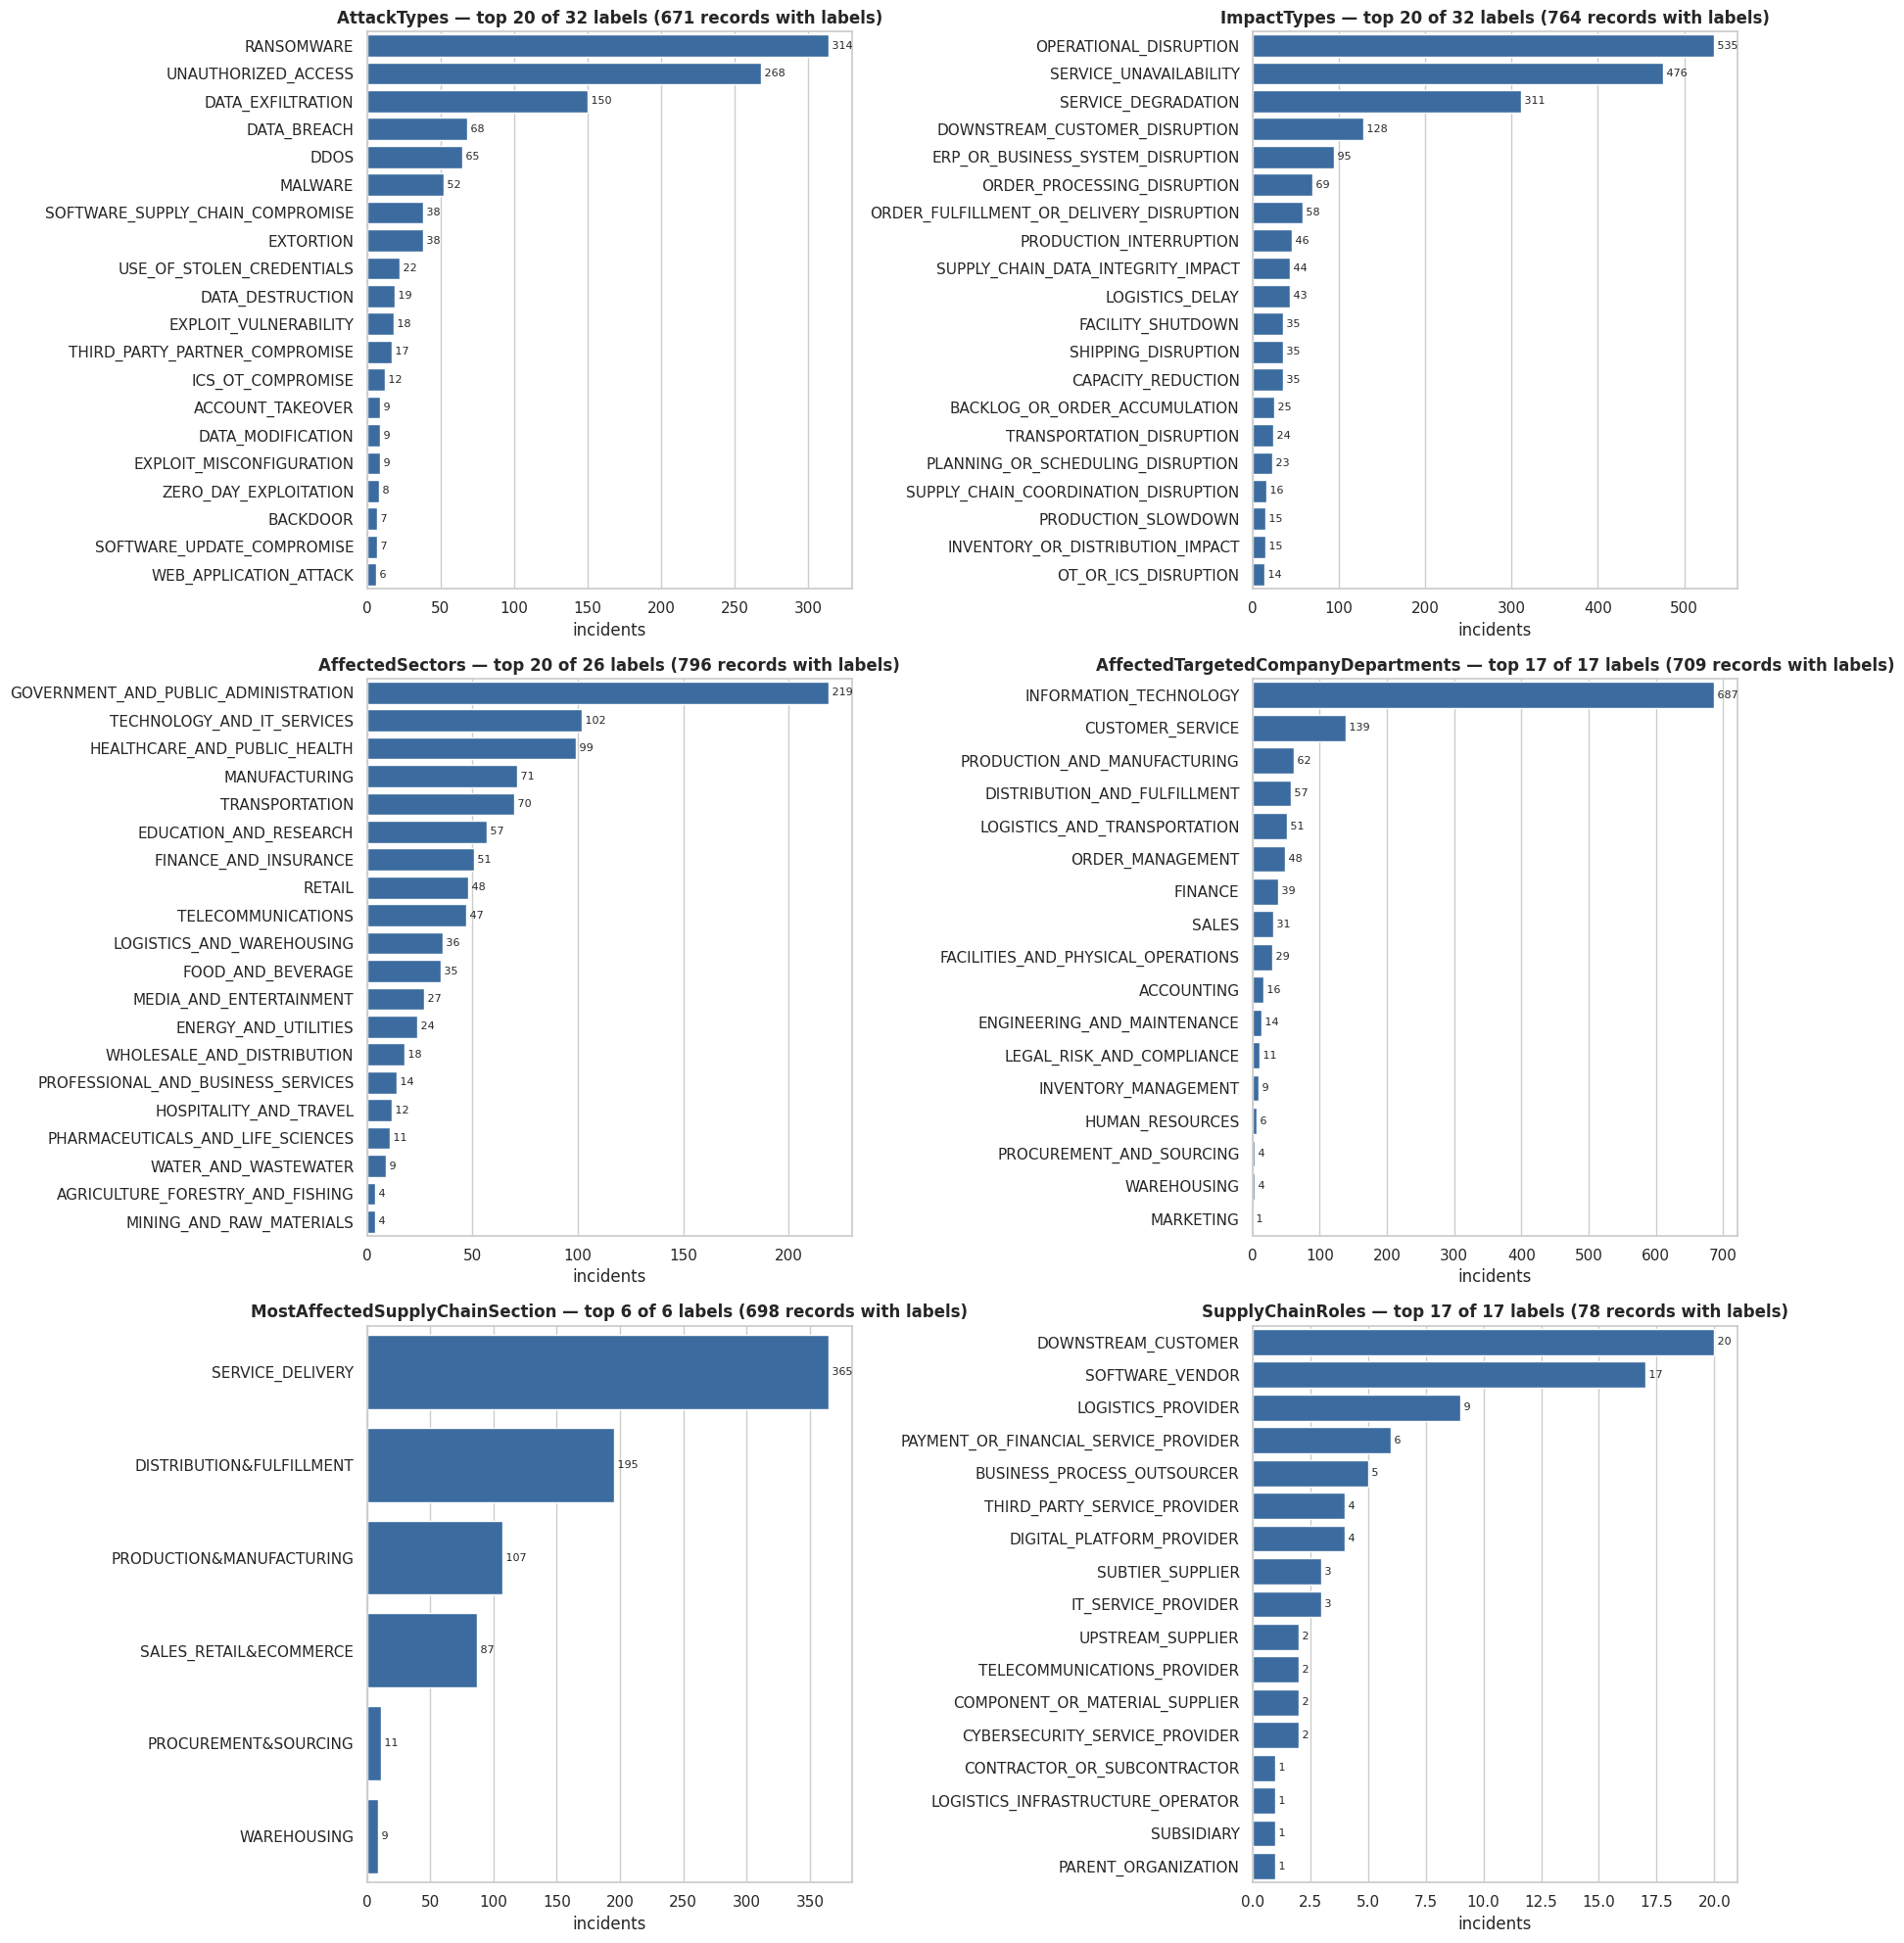

AttackTypes: 9/32 labels appear in <= 3 records -> ['SQL_INJECTION', 'CRYPTOCURRENCY_MINING', 'PHISHING', 'REMOTE_ACCESS_TROJAN', 'BRUTE_FORCE', 'SUPPLY_CHAIN_COMPROMISE', 'PRIVILEGE_ABUSE', 'PRETEXTING', 'CREDENTIAL_STUFFING']
ImpactTypes: 6/32 labels appear in <= 3 records -> ['PROCUREMENT_DISRUPTION', 'SUPPLIER_DELIVERY_DELAY', 'DOWNSTREAM', 'DOWNSTREAM_PRODUCTION_INTERRUPTION', 'MATERIAL_OR_COMPONENT_SHORTAGE', 'PRODUCT_OR_PROCESS_QUALITY_IMPACT']
AffectedSectors: 6/26 labels appear in <= 3 records -> ['CONSTRUCTION_AND_ENGINEERING', 'MUSEUMS_AND_CULTURAL_HERITAGE', 'PHYSICAL_SECURITY_SERVICES', 'FUNERAL_SERVICES', 'OTHER(LABOR_UNIONS)', 'REAL_ESTATE_AND_COMMERCIAL_FACILITIES']


In [18]:
# --- Frequency plots for the label sets most relevant to SCOUT ---
PLOT_COLS = ["AttackTypes", "ImpactTypes", "AffectedSectors",
             "AffectedTargetedCompanyDepartments", "MostAffectedSupplyChainSection", "SupplyChainRoles"]
fig, axes = plt.subplots(3, 2, figsize=(18, 20))
for ax, col in zip(axes.ravel(), PLOT_COLS):
    labels = df[f"{col}_list"].explode().dropna()
    counts = labels.value_counts().head(20)
    sns.barplot(x=counts.values, y=counts.index, ax=ax, color=BLUE)
    bar_labels(ax, counts.values)
    n_rec = (df[f"{col}_list"].str.len() > 0).sum()
    ax.set_title(f"{col} — top {len(counts)} of {labels.nunique()} labels ({n_rec} records with labels)")
    ax.set_xlabel("incidents"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

# Long tail: labels used by very few records (few examples to retrieve or learn from)
for col in ["AttackTypes", "ImpactTypes", "AffectedSectors"]:
    vc = df[f"{col}_list"].explode().value_counts()
    rare = vc[vc <= 3]
    print(f"{col}: {len(rare)}/{len(vc)} labels appear in <= 3 records -> {list(rare.index)}")

### Interpretation

The label distributions describe what TRACE contains and therefore what SCOUT can return. Attacks are dominated by `RANSOMWARE` (**314** incidents), `UNAUTHORIZED_ACCESS` (**268**) and `DATA_EXFILTRATION` (**150**). Impacts are mostly generic — `OPERATIONAL_DISRUPTION` (**535**), `SERVICE_UNAVAILABILITY` (**476**), `SERVICE_DEGRADATION` (**311**) — while specific supply-chain impacts such as `LOGISTICS_DELAY` or `PRODUCTION_INTERRUPTION` occur in tens of records. Government and public administration is the largest sector (**219**), ahead of technology/IT (**102**) and healthcare (**99**); manufacturing has 71 and logistics/warehousing 36. `INFORMATION_TECHNOLOGY` is affected in **687** incidents, so it barely discriminates between cases. In the supply-chain section, `SERVICE_DELIVERY` dominates (**365**), followed by distribution & fulfillment (**195**) and production & manufacturing (**107**); procurement (**11**) and warehousing (**9**) are rare. The long tail is real: 9 of 32 attack types and 6 of 32 impact types appear in three records or fewer. These are frequencies of the TRACE snapshot, not prevalence estimates for cyber incidents in general.

## 2.4 Time
Counts by approximate incident date. Temporal concentration may reflect how TRACE research requests were scoped and when sources became available, not only real-world incident frequency.

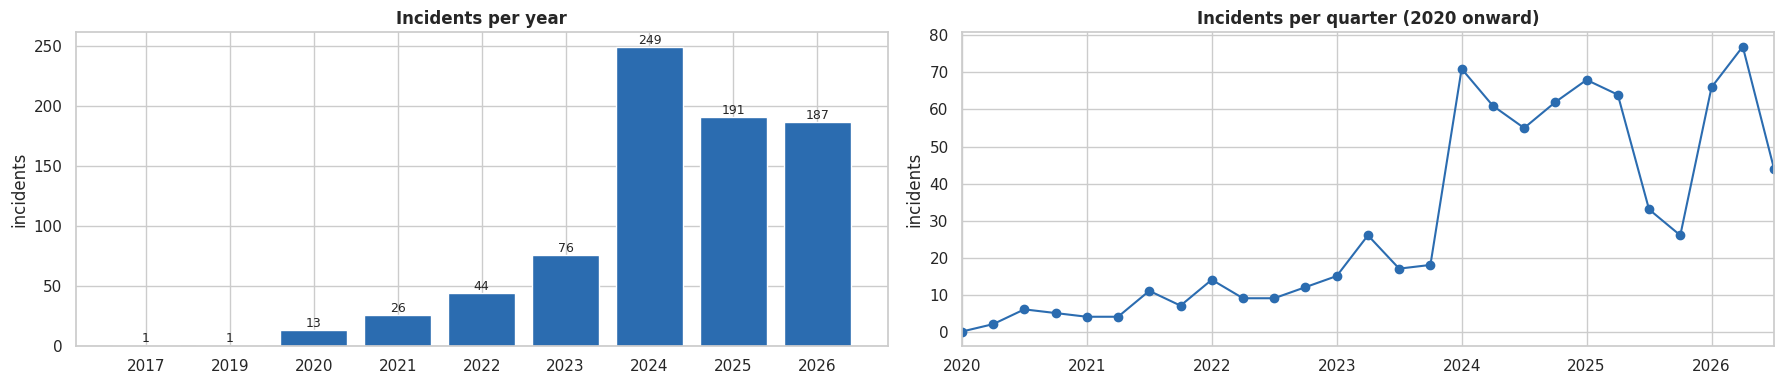

Dated incidents: 788 | 2024–2026: 627 (79.6%)


In [19]:
# --- Incidents per year and per quarter ---
dated = df.dropna(subset=["incident_date"])
fig, axes = plt.subplots(1, 2, figsize=(18, 4))
year_counts = dated["incident_year"].astype(int).value_counts().sort_index()
axes[0].bar(year_counts.index.astype(str), year_counts.values, color=BLUE)
for x, v in zip(year_counts.index.astype(str), year_counts.values):
    axes[0].text(x, v, f"{v}", ha="center", va="bottom", fontsize=9)
axes[0].set_title("Incidents per year"); axes[0].set_ylabel("incidents")
dated.set_index("incident_date").resample("QE").size().loc["2020":].plot(ax=axes[1], marker="o", color=BLUE)
axes[1].set_title("Incidents per quarter (2020 onward)"); axes[1].set_ylabel("incidents"); axes[1].set_xlabel("")
plt.tight_layout(); plt.show()
recent = dated["incident_year"].isin([2024, 2025, 2026]).sum()
print(f"Dated incidents: {len(dated)} | 2024–2026: {recent} ({recent / len(dated):.1%})")

### Interpretation

The dated records span 2017–2026, but **627 of 788 (79.6%)** fall in 2024–2026, with 2024 the largest year (249). The quarterly series rises sharply from 2023. This concentration reflects how the research requests were scoped and how much recent reporting is available as much as any real increase in attacks, so time trends should not be read as incident-rate trends. For SCOUT it means retrieved cases will mostly be recent, which is desirable for relevance.

## 2.5 Geography and threat actors
`CountryTargetedCompany` is the country of the directly attacked organization; `AffectedCountries` lists where material consequences occurred (§9.3). Threat-actor attribution is optional in the spec (§7.18).

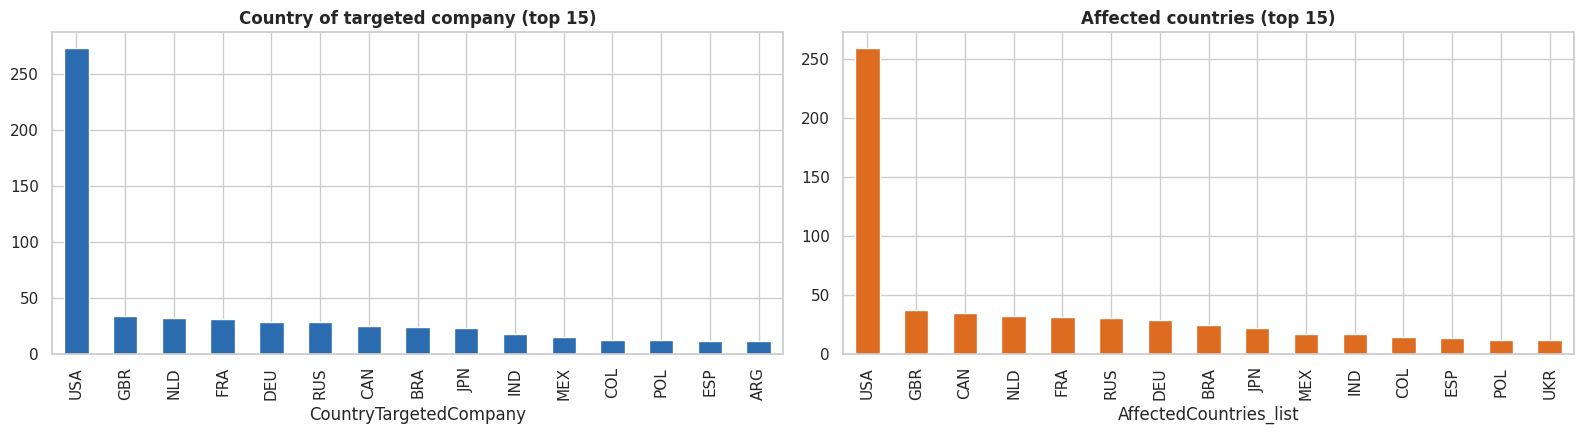

USA share of targeted companies: 34.4% | incidents affecting MEX: 17


,IncidentTitle,AttackTypes,AffectedSectors,MostAffectedSupplyChainSection
43,Cyberattack disrupts FOXCONN North American factories; NITROGEN claims,"UNAUTHORIZED_ACCESS, EXTORTION",MANUFACTURING,PRODUCTION&MANUFACTURING
58,PEMEX ransomware forces manual fuel billing; $4.9m demand,"RANSOMWARE, EXTORTION",ENERGY_AND_UTILITIES,DISTRIBUTION&FULFILLMENT
59,ASIPONA MANZANILLO restricts PIS access after breach alert,"DATA_BREACH, DATA_EXFILTRATION, UNAUTHORIZED_ACCESS","GOVERNMENT_AND_PUBLIC_ADMINISTRATION, TRANSPORTATION, LOGISTICS_AND_WAREHOUSING",DISTRIBUTION&FULFILLMENT
60,COPPEL cyberattack knocks ecommerce offline; 3‑month recovery,"RANSOMWARE, UNAUTHORIZED_ACCESS",RETAIL,SALES_RETAIL&ECOMMERCE
61,COCA COLA FEMSA incident with data exfiltration from Latin American servers,"DATA_EXFILTRATION, UNAUTHORIZED_ACCESS",FOOD_AND_BEVERAGE,DISTRIBUTION&FULFILLMENT
63,OMA confirms ransomware; operations on backup systems,"RANSOMWARE, DATA_EXFILTRATION, UNAUTHORIZED_ACCESS",TRANSPORTATION,DISTRIBUTION&FULFILLMENT
64,SICT cyberattack suspends procedures nationwide through 2022,RANSOMWARE,"GOVERNMENT_AND_PUBLIC_ADMINISTRATION, TRANSPORTATION",DISTRIBUTION&FULFILLMENT
67,Ransomware at FOXCONN Mexico facility (Nov 2020),"RANSOMWARE,DATA_EXFILTRATION,DATA_DESTRUCTION",MANUFACTURING,PRODUCTION&MANUFACTURING
100,Mexico port platform PIS outage and data leak impairs cargo releases at Manzanillo,"UNAUTHORIZED_ACCESS,DATA_EXFILTRATION","GOVERNMENT_AND_PUBLIC_ADMINISTRATION,LOGISTICS_AND_WAREHOUSING,TRANSPORTATION",DISTRIBUTION&FULFILLMENT
101,CIBanco reports attempted REvil ransomware; services suspended intermittently,"RANSOMWARE,EXTORTION",FINANCE_AND_INSURANCE,SALES_RETAIL&ECOMMERCE


In [20]:
# --- Country of the targeted company vs affected countries ---
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
df["CountryTargetedCompany"].value_counts().head(15).plot.bar(ax=axes[0], color=BLUE)
axes[0].set_title("Country of targeted company (top 15)")
df["AffectedCountries_list"].explode().value_counts().head(15).plot.bar(ax=axes[1], color=ORANGE)
axes[1].set_title("Affected countries (top 15)")
plt.tight_layout(); plt.show()

share_usa = (df["CountryTargetedCompany"] == "USA").mean()
mx = df[df["AffectedCountries_list"].apply(lambda l: "MEX" in l)]
print(f"USA share of targeted companies: {share_usa:.1%} | incidents affecting MEX: {len(mx)}")
display(mx[["IncidentTitle", "AttackTypes", "AffectedSectors", "MostAffectedSupplyChainSection"]])

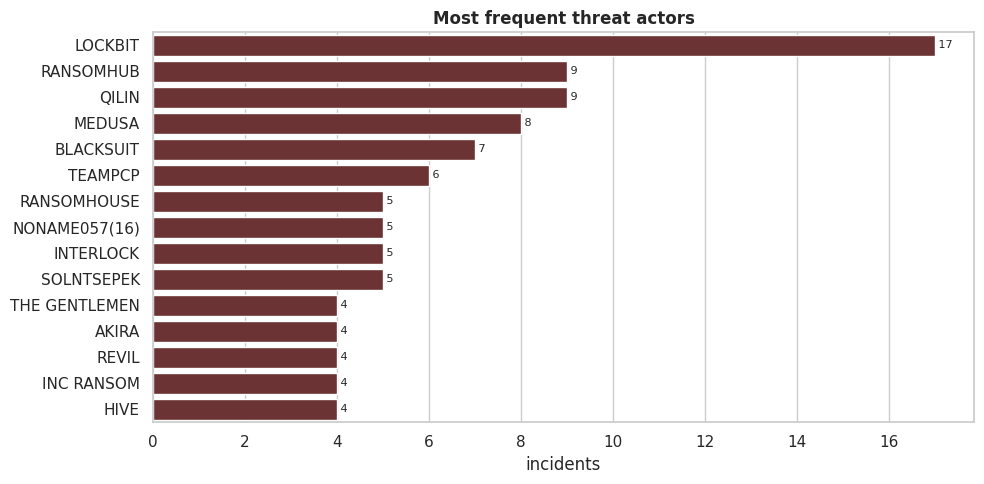

Records with a named actor: 24.7% | distinct actors: 97


In [21]:
# --- Threat actors ---
actors = df["ThreatActorNames_list"].explode().dropna()
fig, ax = plt.subplots(figsize=(10, 5))
top_actors = actors.value_counts().head(15)
sns.barplot(x=top_actors.values, y=top_actors.index, ax=ax, color=MAROON)
bar_labels(ax, top_actors.values)
ax.set_title("Most frequent threat actors"); ax.set_xlabel("incidents"); ax.set_ylabel("")
plt.tight_layout(); plt.show()
print(f"Records with a named actor: {(df['ThreatActorNames_list'].str.len() > 0).mean():.1%} | distinct actors: {actors.nunique()}")

### Interpretation

The dataset is US-centred: **34.4%** of targeted companies are American, and the next countries (GBR, NLD, FRA, DEU, RUS) contribute about 4% each. Only **17** incidents affect Mexico — among them PEMEX, Coppel, Foxconn's Tijuana plant, the Manzanillo port platform and Viva Aerobús — so a Mexican SCOUT user will usually be matched with foreign cases, and country is better used as a preference than as a hard filter. Threat actors are named in only **24.7%** of records (97 distinct names, led by LockBit with 17), consistent with the spec's position that attribution is optional (§7.18).

## 2.6 Text fields as a corpus
Three free-text fields: `IncidentTitle`, `Summary` (the narrative SCOUT will match on) and `ReliabilityFeedback` (the verifier's comments about evidence). Length, language and vocabulary are characterized *before* any cleaning.

count   mean    std    min    25%    50%    75%     max
IncidentTitle       chars      797.0   71.7   12.8   27.0   63.0   72.0   80.0   116.0
                    words      797.0    9.2    1.9    4.0    8.0    9.0   10.0    17.0
                    sentences  797.0    1.0    0.2    1.0    1.0    1.0    1.0     3.0
Summary             chars      797.0  402.5  114.8  157.0  325.0  387.0  461.0   911.0
                    words      797.0   55.1   14.9   20.0   45.0   53.0   63.0   113.0
                    sentences  797.0    2.7    0.8    1.0    2.0    3.0    3.0     7.0
ReliabilityFeedback chars      750.0  435.6  218.3  176.0  307.2  360.0  495.8  2050.0
                    words      750.0   47.9   19.8   22.0   38.0   43.5   52.0   254.0
                    sentences  750.0    2.7    1.1    1.0    2.0    2.0    3.0    13.0

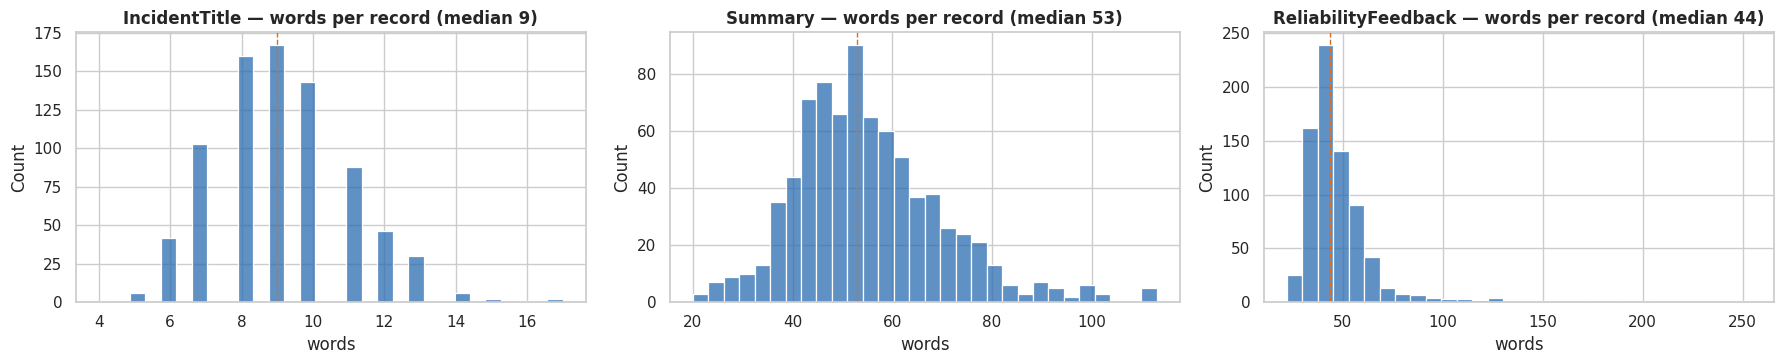

In [22]:
# --- Length per record: characters, words and sentences ---
def text_stats(s):
    s = s.dropna()
    return pd.DataFrame({"chars": s.str.len(), "words": s.str.split().str.len(),
                         "sentences": s.apply(lambda t: len([x for x in re.split(r"(?<=[.!?])\s+", t) if x.strip()]))})

stats = {c: text_stats(df[c]) for c in TEXT_COLS}
display(pd.concat({c: s.describe().T for c, s in stats.items()}).round(1))

fig, axes = plt.subplots(1, 3, figsize=(18, 3.8))
for ax, c in zip(axes, TEXT_COLS):
    sns.histplot(stats[c]["words"], bins=30, ax=ax, color=BLUE)
    ax.axvline(stats[c]["words"].median(), color=ORANGE, ls="--", lw=1)
    ax.set_title(f"{c} — words per record (median {stats[c]['words'].median():.0f})")
plt.tight_layout(); plt.show()

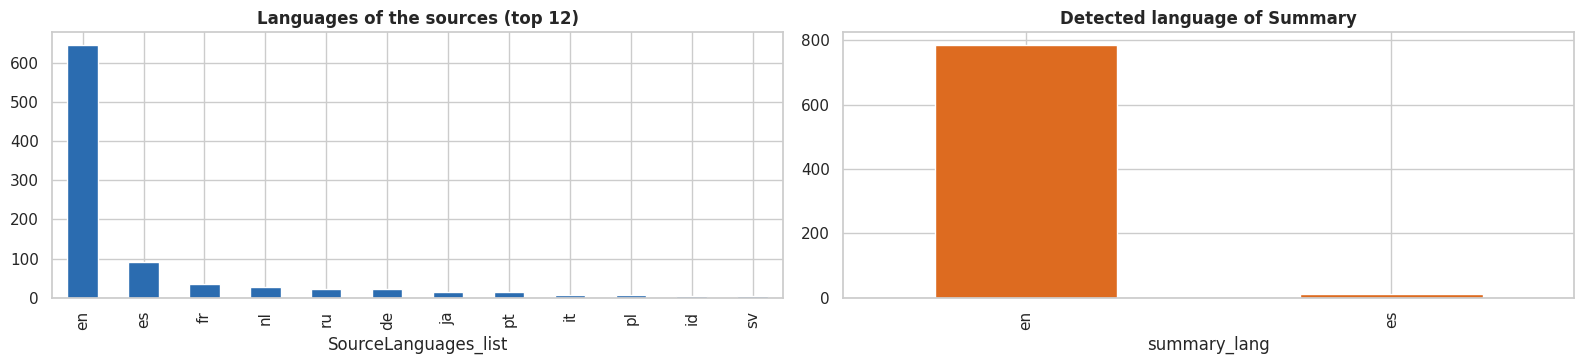

Records citing >= 1 non-English source: 275 | non-English summaries: 12


,IncidentTitle,summary_lang,Summary
106,AMLO confirma hackeo a SEDENA; Guacamaya exfiltra 6 TB (sep–oct 2022),es,"El 30/09/2022 el presidente López Obrador confirmó el hackeo a la SEDENA, mientras BBC Mundo reportó que el colectiv..."
114,BCCR confirma DDoS el 12/01/2024; caen servicios web y superintendencias,es,El 12/01/2024 el Banco Central de Costa Rica confirmó que un ataque DDoS degradó y luego bloqueó el acceso a sus ser...
116,Guatemala Minex confirmó ciberataque en 2022; servicios digitales inoperativos y filtración,es,"El Minex confirmó en octubre de 2022 un ciberataque con afectación a sus plataformas, dejando inoperativos varios se..."
117,Guatecompras y SICOIN fuera de servicio por ciberataque; >10 días de afectación,es,El Ministerio de Finanzas Públicas atribuyó la caída de los portales Guatecompras y SICOIN a un ciberataque. Prensa ...
118,MINEDUC denuncia ciberataque y trabaja en restablecer servicios (abr 2024),es,"En abril de 2024, el Ministerio de Educación de Guatemala denunció un ciberataque a sus sistemas informáticos e info..."
119,RD: OGTIC y CSIRT-RD mitigan ataque que impactó 14 portales estatales (06/02/2022),es,La OGTIC informó que el 06/02/2022 un ataque de 'defacement' impactó la portada de 14 sitios web estatales (de 46 en...
121,RGAE: API expuesta permitió extraer masivamente datos de proveedores del Estado (may 2026),es,Una investigación técnica verificó que el RGAE tenía una API expuesta sin controles que permitió la extracción de da...
267,Ransomware at Invima halts key processes for over a month,es,Invima deshabilitó su portal web y desconectó servidores físicos y virtuales tras un aparente ransomware que afectó ...
268,"Cafam attack affects appointment scheduling, imaging, and pharmacy dispensing",es,CAFAM informó que un ataque cibernético a sus sistemas de información causó afectaciones en centros de atención en s...
270,Ransomware paraliza infraestructura del Hospital Universitario de Caldas y obliga a operar en contingencia,es,El 20/03/2024 el Hospital Universitario de Caldas informó un ataque de ransomware que afectó el 100% de su infraestr...


In [23]:
# --- Language: of the SOURCES (SourceLanguages) vs of the SUMMARY text (detected) ---
def safe_detect(t):
    try:
        return detect(t)
    except Exception:
        return "unknown"

df["summary_lang"] = df["Summary"].apply(safe_detect)
src_lang = df["SourceLanguages_list"].explode().dropna().str.lower().value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 3.8))
src_lang.head(12).plot.bar(ax=axes[0], color=BLUE); axes[0].set_title("Languages of the sources (top 12)")
df["summary_lang"].value_counts().plot.bar(ax=axes[1], color=ORANGE); axes[1].set_title("Detected language of Summary")
plt.tight_layout(); plt.show()

non_en_src = df["SourceLanguages_list"].apply(lambda l: any(x != "EN" for x in l)).sum()
print(f"Records citing >= 1 non-English source: {non_en_src} | non-English summaries: {(df['summary_lang'] != 'en').sum()}")
display(df.loc[df["summary_lang"] != "en", ["IncidentTitle", "summary_lang", "Summary"]].head(12))

Summary tokens: 44,831 | vocabulary (lowercased): 5,889 | hapax: 3,172 (53.9%) | types containing digits: 249


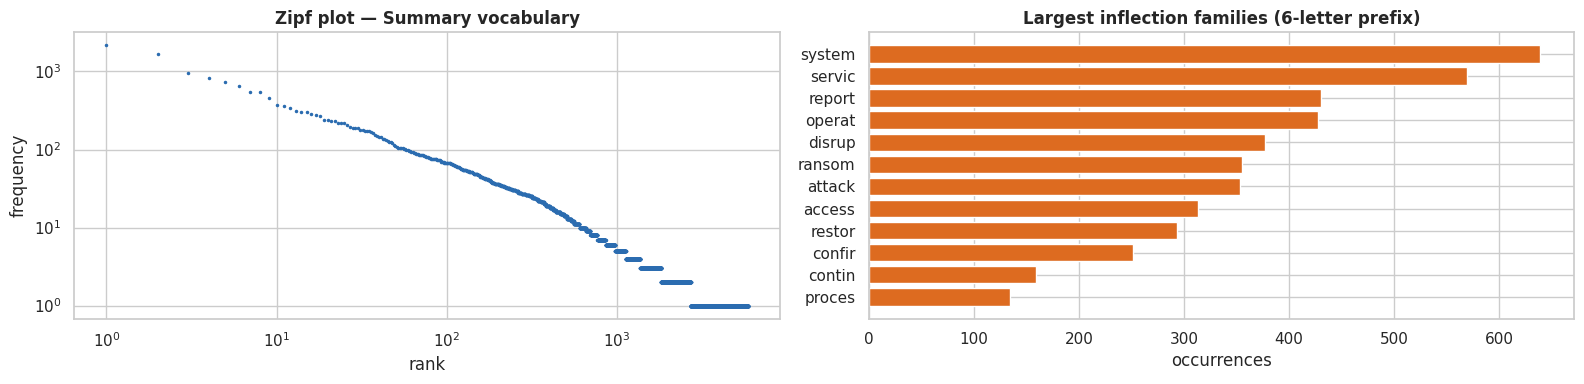

,stem,variants,occurrences,examples
0,system,5,639,"systems, system, systembolaget, systemwide, systematically"
1,servic,6,569,"services, service, servicios, servicio, serviced, servicing"
2,report,7,430,"reported, reporting, reports, report, reportó, reportedly"
3,operat,11,427,"operations, operational, operating, operated, operation, operator"
4,disrup,6,377,"disrupted, disruption, disrupting, disruptions, disruptive, disrupt"
5,ransom,5,355,"ransomware, ransom, ransomhub, ransomhouse, ransomexx"
6,attack,5,353,"attack, attackers, attacker, attacks, attacked"
7,access,6,313,"access, accessed, accessibility, accessing, accesses, accessible"
8,restor,4,293,"restored, restoration, restoring, restore"
9,confir,7,251,"confirmed, confirm, confirms, confirmó, confirming, confirmations"


In [24]:
# --- Vocabulary before normalization: size, hapax share, Zipf curve, morphological families ---
raw_tokens = [t.lower() for s in df["Summary"] for t in re.findall(r"\b\w[\w'\-\u2010-\u2014]*\b", s)]
freq = Counter(raw_tokens)
hapax = [w for w, n in freq.items() if n == 1]
print(f"Summary tokens: {len(raw_tokens):,} | vocabulary (lowercased): {len(freq):,} | "
      f"hapax: {len(hapax):,} ({len(hapax) / len(freq):.1%}) | types containing digits: "
      f"{sum(any(ch.isdigit() for ch in w) for w in freq):,}")

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
ranks = np.arange(1, len(freq) + 1); counts_sorted = np.array(sorted(freq.values(), reverse=True))
axes[0].loglog(ranks, counts_sorted, ".", ms=3, color=BLUE)
axes[0].set_xlabel("rank"); axes[0].set_ylabel("frequency"); axes[0].set_title("Zipf plot — Summary vocabulary")

# Inflection families: what stemming / lemmatization would collapse
families = {}
for w in freq:
    if w.isalpha() and len(w) > 5:
        families.setdefault(w[:6], []).append(w)
fam = sorted(((k, v) for k, v in families.items() if len(v) >= 4), key=lambda kv: -sum(freq[w] for w in kv[1]))[:12]
fam_df = pd.DataFrame([(k, len(v), sum(freq[w] for w in v), ", ".join(sorted(v, key=lambda w: -freq[w])[:6]))
                       for k, v in fam], columns=["stem", "variants", "occurrences", "examples"])
axes[1].barh(fam_df["stem"][::-1], fam_df["occurrences"][::-1], color=ORANGE)
axes[1].set_title("Largest inflection families (6-letter prefix)"); axes[1].set_xlabel("occurrences")
plt.tight_layout(); plt.show()
display(fam_df)

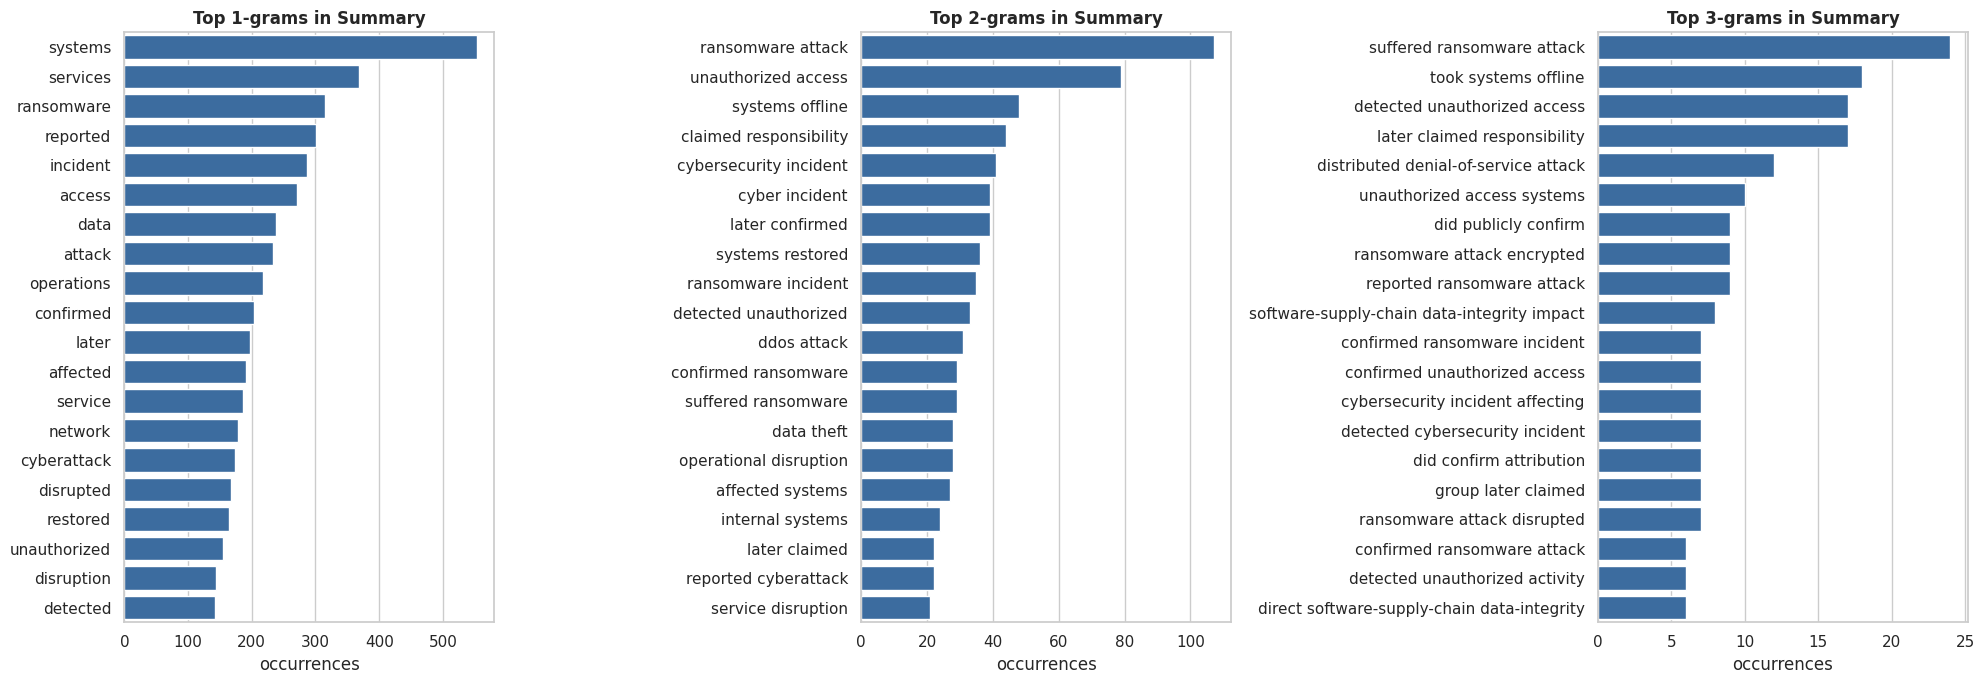

Top words in ReliabilityFeedback: {'https': 502, 'material': 361, 'ransomware': 342, 'www': 337, 'disruption': 325, 'date': 318, 'impact': 306, 'service': 294, 'com': 278, 'reporting': 245, 'operational': 237, 'confirm': 207, 'independent': 207, 'attack': 202, 'incident': 202, 'supported': 201, 'identity': 199, 'official': 195, 'data': 179, 'confirms': 174}


In [25]:
# --- Most frequent unigrams / bigrams / trigrams (English stop words removed; exploration only) ---
def top_ngrams(texts, n, k=20):
    cv = CountVectorizer(ngram_range=(n, n), stop_words="english", lowercase=True,
                         token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z\-\u2010-\u2014]+\b")
    X = cv.fit_transform(texts)
    return pd.Series(np.asarray(X.sum(axis=0)).ravel(), index=cv.get_feature_names_out()).nlargest(k)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, n in zip(axes, [1, 2, 3]):
    s = top_ngrams(df["Summary"], n)
    sns.barplot(x=s.values, y=s.index, ax=ax, color=BLUE)
    ax.set_title(f"Top {n}-grams in Summary"); ax.set_xlabel("occurrences"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

print("Top words in ReliabilityFeedback:", top_ngrams(df["ReliabilityFeedback"].dropna(), 1, 20).to_dict())

### Interpretation

`Summary` is the richest field: a median of **53 words** (387 characters) in about 3 sentences, never empty. Titles are short (median 9 words) and `ReliabilityFeedback` is about as long as the summary but is commentary about sources — its most frequent words are `https`, `www`, `com`, `confirm`, `independent`, `official` — so it does not describe the incident and is excluded from the semantic representation.

Although **275** records cite at least one non-English source, only **12** summaries are not in English (all Spanish, from Latin American incidents): the TRACE pipeline writes summaries in English, so an English embedding model is appropriate, with those 12 records as a known exception. The vocabulary has 5,889 word types and **53.9%** appear once (company names, places, people), the usual Zipf pattern. The largest inflection families (`system/systems`, `service/services/servicios`, `operat…`, `disrupt…`, `restor…`) show what stemming would merge; transformer tokenizers handle these variants on their own. The frequent n-grams (`ransomware attack`, `unauthorized access`, `systems offline`, `claimed responsibility`) confirm that summaries consistently describe the event and its operational consequence, as §7.3 requires.

# Part 3 — Bivariate and multivariate analysis

Relationships between variables. Nominal multi-label fields are never integer-encoded; they are compared through binary incidence matrices (co-occurrence counts and conditional proportions). Because one incident can carry several labels, groups overlap and the results are descriptive associations, not causal effects.

## 3.1 Numeric relationships
Spearman's ρ is used (no normality assumption, robust to skew). A coefficient is shown only when at least 20 records have both values, and the pairwise sample size is displayed next to it.

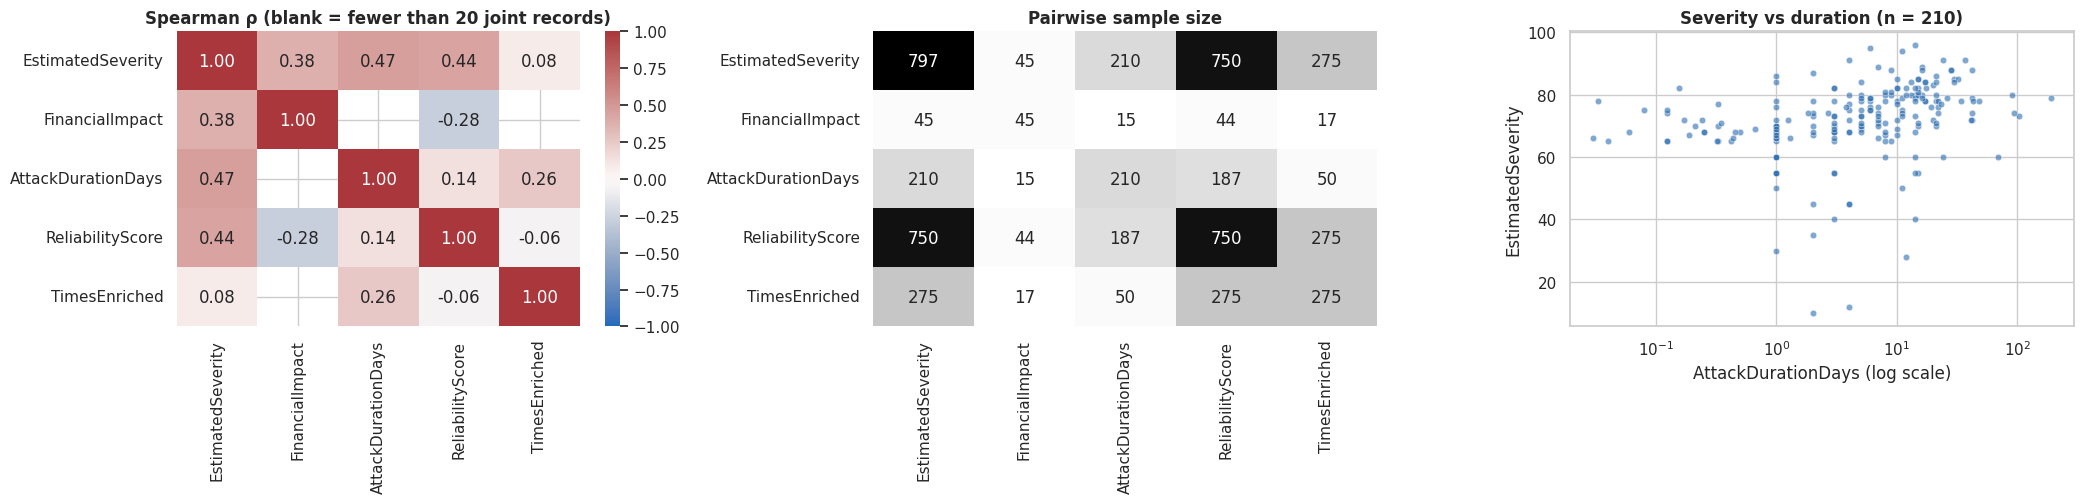

,count,mean,std,min,25%,50%,75%,max
reliability_band,,,,,,,,
50–74 partly supported,4.0,43.8,23.2,20.0,31.2,40.0,52.5,75.0
"75–84 plausible, not ready",96.0,53.2,22.8,8.0,35.0,60.0,70.0,96.0
85–89 TRACE-ready,138.0,63.9,14.1,15.0,56.2,66.0,74.0,88.0
90–100 strong,512.0,71.2,13.4,7.0,67.0,73.0,80.0,95.0


In [26]:
# --- Spearman correlation with minimum overlap + pairwise n ---
num = df[NUM_COLS]
rho = num.corr(method="spearman", min_periods=20)
pair_n = num.notna().astype(int).T.dot(num.notna().astype(int))

fig, axes = plt.subplots(1, 3, figsize=(21, 5.2))
sns.heatmap(rho, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Spearman ρ (blank = fewer than 20 joint records)")
sns.heatmap(pair_n, annot=True, fmt="d", cmap="Greys", ax=axes[1], cbar=False)
axes[1].set_title("Pairwise sample size")

m = df["AttackDurationDays"].notna()
axes[2].scatter(df.loc[m, "AttackDurationDays"], df.loc[m, "EstimatedSeverity"], s=22, color=BLUE, alpha=0.6,
                edgecolor="white", linewidth=0.5)
axes[2].set_xscale("log"); axes[2].set_xlabel("AttackDurationDays (log scale)"); axes[2].set_ylabel("EstimatedSeverity")
axes[2].set_title(f"Severity vs duration (n = {m.sum()})")
plt.tight_layout(); plt.show()

# Severity by reliability band: are weaker records also milder ones?
display(df.groupby("reliability_band", observed=True)["EstimatedSeverity"].describe().round(1))

### Interpretation

The strongest supported relationships are moderate: **duration ↔ severity** (ρ = 0.47, *n* = 210) and **severity ↔ reliability** (ρ = 0.44, *n* = 750). The second one is visible in the band table: median severity is 60 for "plausible, not ready" records and 73 for the strongest band, so weaker evidence goes with milder documented consequences — possibly because severity can only rise as far as the evidence supports (§7.19). `FinancialImpact` and `AttackDurationDays` overlap in only 15 records, below the 20-record threshold, so no coefficient is reported for that pair. These are descriptive associations, not causal effects.

## 3.2 Attack types × impact types
Left: how many incidents carry each attack–impact pair. Right: the conditional proportion *P(impact | attack)*, which removes the effect of attack frequency.

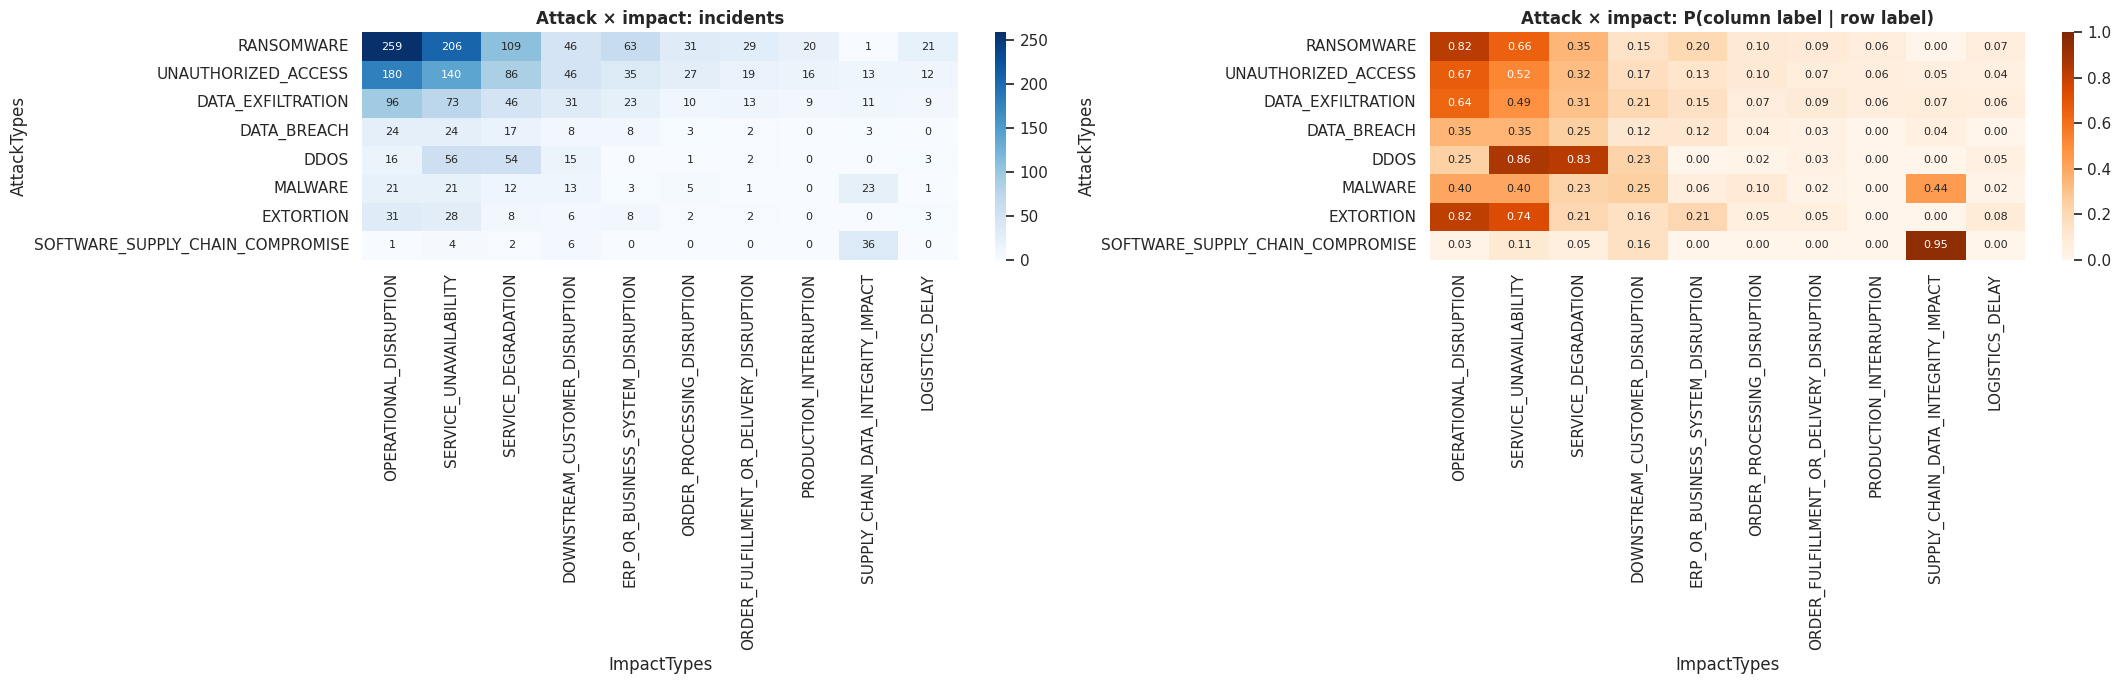

In [27]:
# --- Helpers: binary incidence matrices for label lists ---
def incidence(col, top=None):
    lists = df[f"{col}_list"]
    mlb = MultiLabelBinarizer()
    M = pd.DataFrame(mlb.fit_transform(lists), columns=mlb.classes_, index=df.index)
    if top:
        M = M[M.sum().sort_values(ascending=False).head(top).index]
    return M

def cooc_panels(row_col, col_col, top_r, top_c, title, figsize=(22, 7)):
    A, B = incidence(row_col, top_r), incidence(col_col, top_c)
    counts = A.T.dot(B)
    cond = counts.div(A.sum(), axis=0)
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    sns.heatmap(counts, annot=True, fmt="d", cmap="Blues", ax=axes[0], annot_kws={"fontsize": 8})
    axes[0].set_title(f"{title}: incidents")
    sns.heatmap(cond, annot=True, fmt=".2f", cmap="Oranges", vmin=0, vmax=1, ax=axes[1], annot_kws={"fontsize": 8})
    axes[1].set_title(f"{title}: P(column label | row label)")
    for ax in axes:
        ax.set_xlabel(col_col); ax.set_ylabel(row_col)
    plt.tight_layout(); plt.show()
    return counts, cond

att_imp_counts, att_imp_cond = cooc_panels("AttackTypes", "ImpactTypes", 8, 10, "Attack × impact")

### Interpretation

Attack types have recognisable impact profiles. **82.5%** of ransomware incidents report `OPERATIONAL_DISRUPTION` and **65.6%** `SERVICE_UNAVAILABILITY`. DDoS is almost purely a service problem: **86.2%** report unavailability and **83.1%** degradation, but only 24.6% report broader operational disruption. The most distinctive pair is `SOFTWARE_SUPPLY_CHAIN_COMPROMISE` → `SUPPLY_CHAIN_DATA_INTEGRITY_IMPACT` (**94.7%**), the clearest supply-chain signature in the data. Data breaches, by contrast, lead to operational disruption in only 35% of cases, consistent with the spec's rule that data exposure alone is not a material consequence (§2.3). For SCOUT, this means the impacts a user fears are informative about which attack scenarios to show.

## 3.3 Attack types × affected sectors
Counts and *P(attack | sector)*: the attack profile of each of the ten most represented sectors.

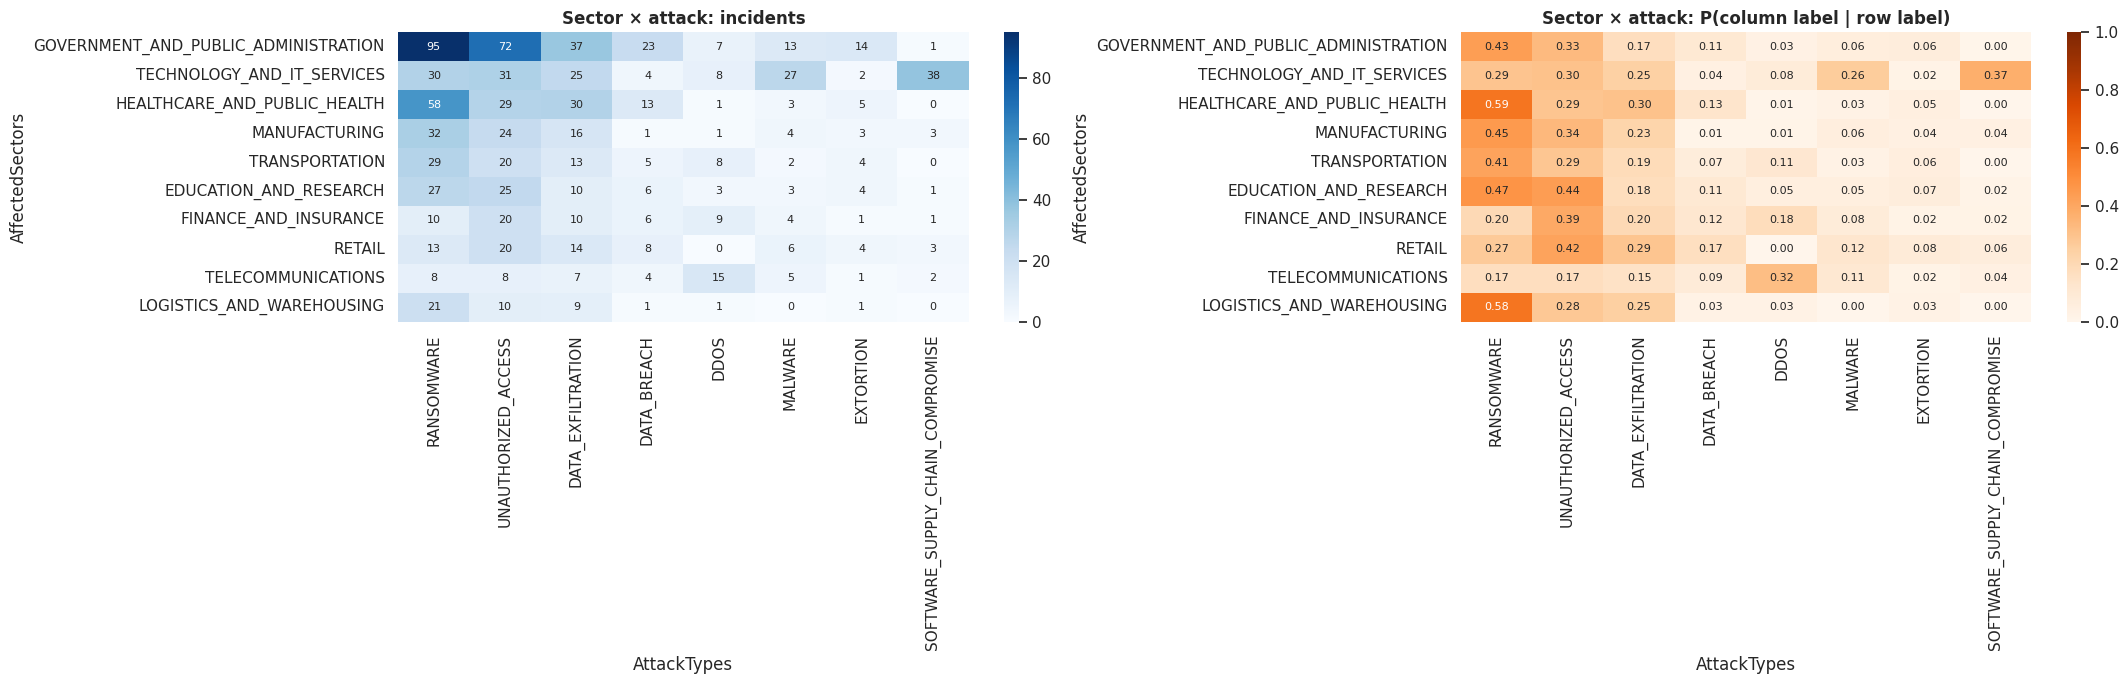

In [28]:
sec_att_counts, sec_att_cond = cooc_panels("AffectedSectors", "AttackTypes", 10, 8, "Sector × attack")

### Interpretation

Sectors have different attack profiles. Ransomware dominates healthcare (**58.6%**), logistics and warehousing (**58.3%**), manufacturing (**45.1%**) and government (**43.4%**). Technology and IT services is the exception: its most frequent attack is `SOFTWARE_SUPPLY_CHAIN_COMPROMISE` (**37.3%**), because those firms are the upstream vendors whose compromise propagates. Telecommunications is the DDoS sector (**31.9%**), and finance shows more unauthorized access (39.2%) and DDoS (17.6%) than ransomware (19.6%). Sector is therefore a strong conditioning variable for retrieval: a manufacturer and a telecom operator should not be shown the same cases.

## 3.4 Attack types × supply-chain section, and labels reported together
`MostAffectedSupplyChainSection` is where the material consequence manifested (§7.12); it is the field that most directly expresses *supply-chain* impact.

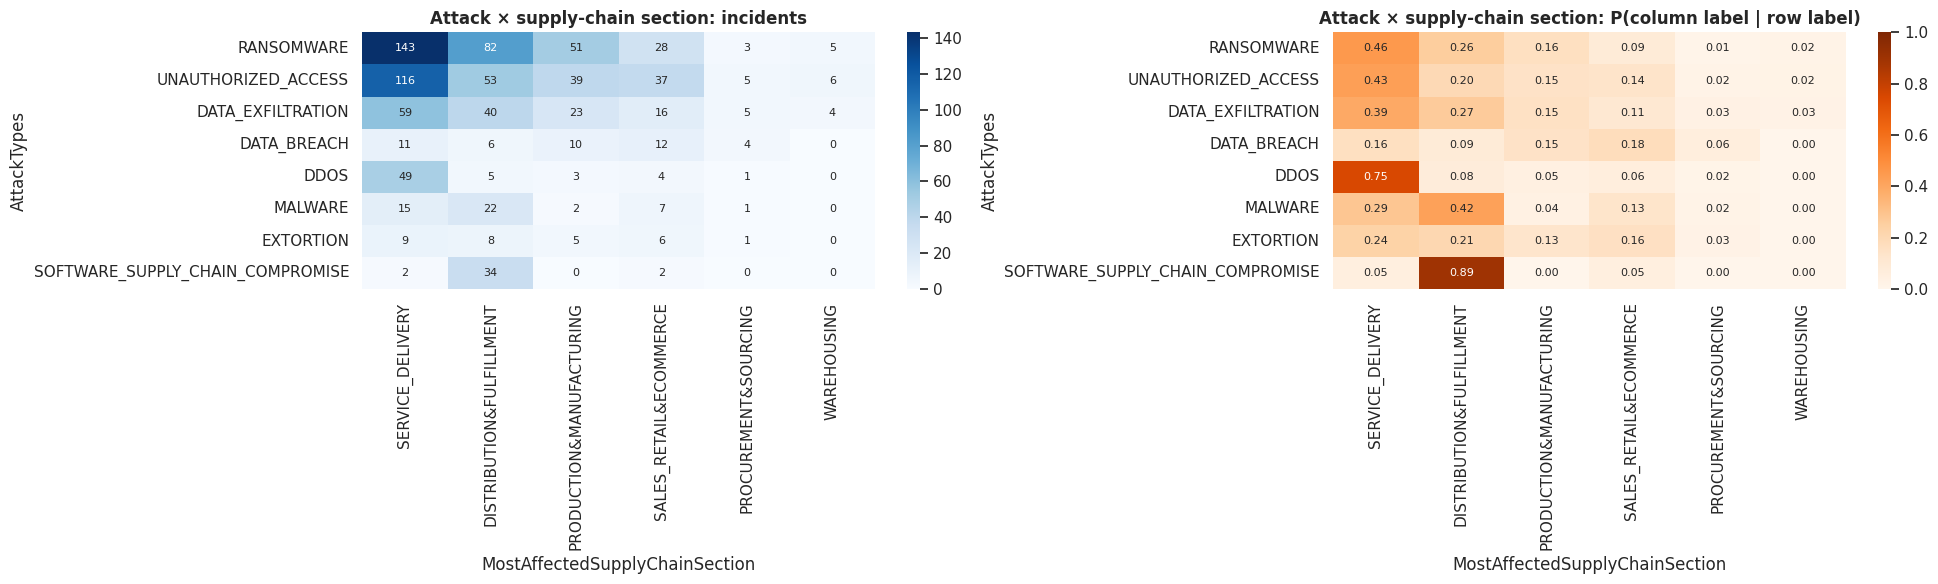

,AttackTypes pair,records,ImpactTypes pair,records,AffectedSectors pair,records
0,DATA_EXFILTRATION + UNAUTHORIZED_ACCESS,96,OPERATIONAL_DISRUPTION + SERVICE_UNAVAILABILITY,344,LOGISTICS_AND_WAREHOUSING + TRANSPORTATION,24
1,DATA_EXFILTRATION + RANSOMWARE,63,OPERATIONAL_DISRUPTION + SERVICE_DEGRADATION,214,GOVERNMENT_AND_PUBLIC_ADMINISTRATION + TECHNOLOGY_AND_IT_SERVICES,10
2,RANSOMWARE + UNAUTHORIZED_ACCESS,51,SERVICE_DEGRADATION + SERVICE_UNAVAILABILITY,186,FOOD_AND_BEVERAGE + RETAIL,9
3,DATA_BREACH + UNAUTHORIZED_ACCESS,45,DOWNSTREAM_CUSTOMER_DISRUPTION + SERVICE_UNAVAILABILITY,95,FOOD_AND_BEVERAGE + MANUFACTURING,9
4,DATA_BREACH + DATA_EXFILTRATION,38,ERP_OR_BUSINESS_SYSTEM_DISRUPTION + OPERATIONAL_DISRUPTION,77,GOVERNMENT_AND_PUBLIC_ADMINISTRATION + TRANSPORTATION,9
5,MALWARE + SOFTWARE_SUPPLY_CHAIN_COMPROMISE,23,DOWNSTREAM_CUSTOMER_DISRUPTION + OPERATIONAL_DISRUPTION,58,GOVERNMENT_AND_PUBLIC_ADMINISTRATION + HEALTHCARE_AND_PUBLIC_HEALTH,8
6,EXTORTION + RANSOMWARE,21,ERP_OR_BUSINESS_SYSTEM_DISRUPTION + SERVICE_UNAVAILABILITY,48,MANUFACTURING + TECHNOLOGY_AND_IT_SERVICES,6
7,MALWARE + UNAUTHORIZED_ACCESS,17,DOWNSTREAM_CUSTOMER_DISRUPTION + SERVICE_DEGRADATION,41,RETAIL + TECHNOLOGY_AND_IT_SERVICES,6


In [29]:
att_sec_counts, att_sec_cond = cooc_panels("AttackTypes", "MostAffectedSupplyChainSection", 8, 6,
                                           "Attack × supply-chain section", figsize=(20, 6))

# Labels reported together within the same field
def top_pairs(col, k=8):
    pairs = Counter()
    for labels in df[f"{col}_list"]:
        pairs.update(combinations(sorted(set(labels)), 2))
    return pd.DataFrame([(f"{a} + {b}", n) for (a, b), n in pairs.most_common(k)], columns=[f"{col} pair", "records"])

display(pd.concat([top_pairs(c) for c in ["AttackTypes", "ImpactTypes", "AffectedSectors"]], axis=1))

### Interpretation

Where the damage lands depends on the attack. DDoS hits `SERVICE_DELIVERY` in **75%** of cases, while software-supply-chain compromises land in `DISTRIBUTION&FULFILLMENT` in **89.5%** of cases (the spec's section for downstream propagation). Ransomware is the most spread out: service delivery 45%, distribution 26%, production 16%. Among labels reported together, the most frequent pairs are `DATA_EXFILTRATION + UNAUTHORIZED_ACCESS` (96) and `DATA_EXFILTRATION + RANSOMWARE` (63, double extortion), `OPERATIONAL_DISRUPTION + SERVICE_UNAVAILABILITY` (344), and `LOGISTICS_AND_WAREHOUSING + TRANSPORTATION` (24). Remember that 99 records have no section at all (12.4%), so section-based analyses cover 698 incidents.

## 3.5 Severity by attack type and by sector
`EstimatedSeverity` (1–100, §7.19) is based only on supported consequences. Multi-label records contribute to every group they belong to.

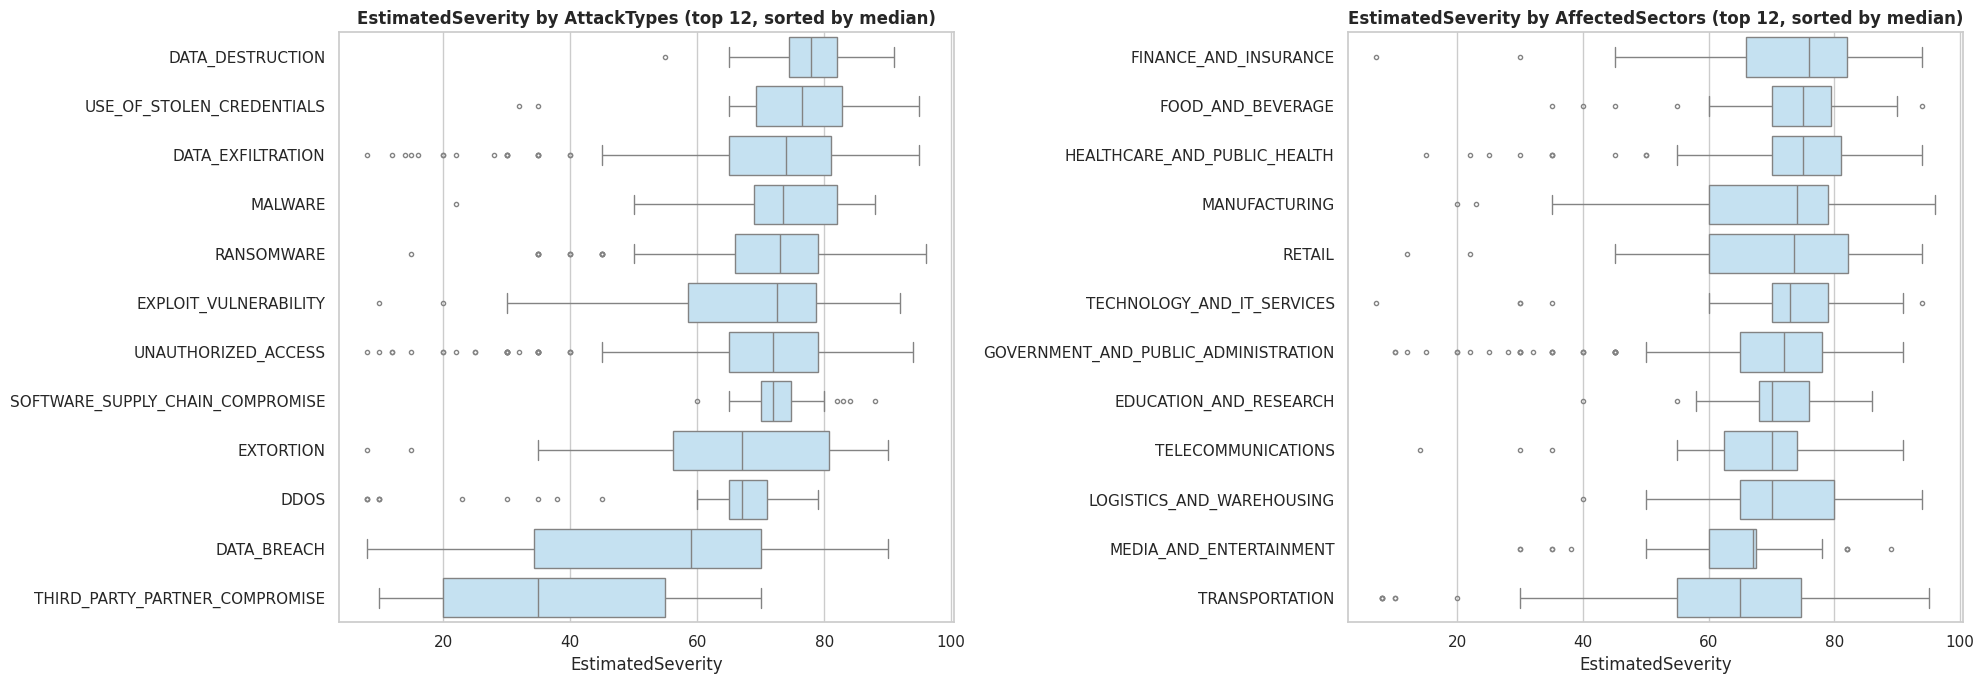


EstimatedSeverity by AttackTypes


,count,median,mean,std
AttackTypes_list,,,,
DATA_DESTRUCTION,19,78.0,77.7,8.3
USE_OF_STOLEN_CREDENTIALS,22,76.5,74.5,16.1
DATA_EXFILTRATION,150,74.0,68.3,19.2
MALWARE,52,73.5,72.7,11.2
RANSOMWARE,314,73.0,71.5,11.8
EXPLOIT_VULNERABILITY,18,72.5,64.4,24.3
UNAUTHORIZED_ACCESS,268,72.0,67.9,17.1
SOFTWARE_SUPPLY_CHAIN_COMPROMISE,38,72.0,72.8,5.5
EXTORTION,38,67.0,65.3,18.7



EstimatedSeverity by AffectedSectors


,count,median,mean,std
AffectedSectors_list,,,,
FINANCE_AND_INSURANCE,51,76.0,72.1,15.7
FOOD_AND_BEVERAGE,35,75.0,73.0,13.3
HEALTHCARE_AND_PUBLIC_HEALTH,99,75.0,71.8,15.2
MANUFACTURING,71,74.0,69.0,15.9
RETAIL,48,73.5,70.7,16.4
TECHNOLOGY_AND_IT_SERVICES,102,73.0,72.7,11.9
GOVERNMENT_AND_PUBLIC_ADMINISTRATION,219,72.0,67.3,16.3
EDUCATION_AND_RESEARCH,57,70.0,71.2,7.3
TELECOMMUNICATIONS,47,70.0,67.5,13.7


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
sev_tables = {}
for ax, col in zip(axes, ["AttackTypes", "AffectedSectors"]):
    ex = df[["EstimatedSeverity", f"{col}_list"]].explode(f"{col}_list").dropna()
    top = ex[f"{col}_list"].value_counts().head(12).index
    ex = ex[ex[f"{col}_list"].isin(top)]
    order = ex.groupby(f"{col}_list")["EstimatedSeverity"].median().sort_values(ascending=False).index
    sns.boxplot(data=ex, y=f"{col}_list", x="EstimatedSeverity", order=order, ax=ax, color=LIGHT, fliersize=3)
    ax.set_title(f"EstimatedSeverity by {col} (top 12, sorted by median)"); ax.set_ylabel("")
    sev_tables[col] = ex.groupby(f"{col}_list")["EstimatedSeverity"].agg(["count", "median", "mean", "std"]).loc[order]
plt.tight_layout(); plt.show()
for col, t in sev_tables.items():
    print(f"\nEstimatedSeverity by {col}"); display(t.round(1))

### Interpretation

Median severity is high (70–78) for most attack types, and the distributions overlap heavily, so attack type alone does not predict severity. Two groups stand apart: `DATA_BREACH` (median **59**) and `THIRD_PARTY_PARTNER_COMPROMISE` (median **35**) — incidents whose consequences were often limited or indirect for the attacked firm. `DATA_DESTRUCTION` (78) and `USE_OF_STOLEN_CREDENTIALS` (76.5) are the most severe. Across sectors, finance (76), food & beverage, healthcare (75) and manufacturing (74) rank highest, and transportation is lowest (65) because it includes many website-only DDoS cases. Severity is therefore useful as display and ranking information, not as a similarity feature.

## 3.6 Attack mix over time and cross-border spillover
The stacked bars show whether the composition of attack types changes by year. The Sankey diagram links the country of the attacked company to the *other* countries where consequences occurred; domestic pairs are reported as a number because they would dominate the chart.

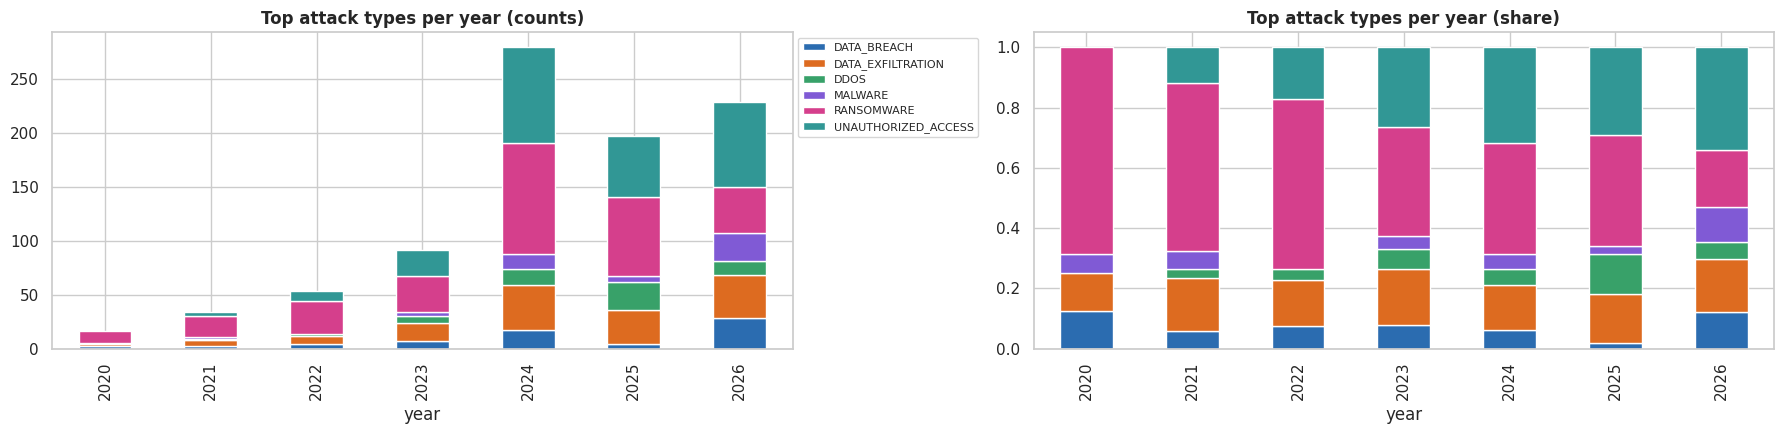

In [31]:
# --- Attack-type mix per year (top 6 types) ---
ex = df.dropna(subset=["incident_year"])[["incident_year", "AttackTypes_list"]].explode("AttackTypes_list").dropna()
top6 = ex["AttackTypes_list"].value_counts().head(6).index
mix = (ex[ex["AttackTypes_list"].isin(top6)].assign(year=lambda d: d["incident_year"].astype(int))
       .pivot_table(index="year", columns="AttackTypes_list", aggfunc="size", fill_value=0).loc[2020:])
fig, axes = plt.subplots(1, 2, figsize=(18, 4.5))
mix.plot.bar(stacked=True, ax=axes[0], color=CAT[:len(top6)]); axes[0].set_title("Top attack types per year (counts)")
mix.div(mix.sum(axis=1), axis=0).plot.bar(stacked=True, ax=axes[1], color=CAT[:len(top6)], legend=False)
axes[1].set_title("Top attack types per year (share)")
axes[0].legend(fontsize=8, bbox_to_anchor=(1, 1))
plt.tight_layout(); plt.show()

In [32]:
# --- Targeted country -> affected country: cross-border spillover (Sankey) ---
import plotly.graph_objects as go
from IPython.display import HTML

# One row per (targeted company country, affected country) pair
pairs = (df[["CountryTargetedCompany", "AffectedCountries_list"]].explode("AffectedCountries_list").dropna()
         .rename(columns={"CountryTargetedCompany": "target", "AffectedCountries_list": "affected"}))

# Domestic pairs dominate, so report them as a number and chart only the cross-border links
domestic = pairs["target"] == pairs["affected"]
print(f"Target->affected pairs: {len(pairs)} | domestic: {domestic.sum()} ({domestic.mean():.0%}) | cross-border: {(~domestic).sum()}")

flows = pairs[~domestic].value_counts().reset_index(name="incidents")

# The same country can appear on both sides, so keep separate source and target nodes
src_nodes, dst_nodes = sorted(flows["target"].unique()), sorted(flows["affected"].unique())
labels = [f"{c} (target)" for c in src_nodes] + [f"{c} (affected)" for c in dst_nodes]
src_idx = {c: i for i, c in enumerate(src_nodes)}
dst_idx = {c: i + len(src_nodes) for i, c in enumerate(dst_nodes)}

fig = go.Figure(go.Sankey(
    node=dict(label=labels, pad=12, thickness=14, color=[BLUE] * len(src_nodes) + [ORANGE] * len(dst_nodes)),
    link=dict(source=flows["target"].map(src_idx), target=flows["affected"].map(dst_idx),
              value=flows["incidents"], color="rgba(160,174,192,0.45)")))
fig.update_layout(title="Cross-border spillover: country of targeted company → other affected countries",
                  height=600, font_size=11)

# Render as embedded HTML (plotly.js from CDN) instead of fig.show():
# the output is stored as text/html, so it displays in Colab without re-running the cell
display(HTML(fig.to_html(include_plotlyjs="cdn", full_html=False)))

# Same flows as a table, for exact numbers
display(flows.head(10))

Target->affected pairs: 785 | domestic: 724 (92%) | cross-border: 61


,target,affected,incidents
0,USA,CAN,9
1,USA,GBR,5
2,FRA,DEU,2
3,NLD,BEL,2
4,BRA,USA,1
5,BRA,AUS,1
6,BEL,USA,1
7,FRA,BRA,1
8,FRA,CHL,1
9,FRA,CHN,1


### Interpretation

The attack mix shifts. Ransomware is the leading attack every year, but its weight falls: it appears in 102 of 249 incidents dated 2024 (41%) and 43 of 187 dated 2026 (23%). Unauthorized access holds steady, and software-supply-chain compromise jumps to **26 incidents in 2026** (from 1 in 2025), most of them package-repository campaigns (npm, PyPI) that also carry the `MALWARE` label. Part of this shift may come from how the 2026 research requests were scoped. Cross-border consequences are rare: of **785** target→affected country pairs, **724 (92%)** are domestic. The **61** cross-border links are led by US companies affecting Canada (9) and the UK (5); Japanese and French multinationals spread to several countries each. For SCOUT, geography mostly identifies *where the victim is*, not a propagation path.

## 3.7 Text ↔ label alignment
SCOUT will compare a questionnaire with incident text, so it matters whether the narrative actually *says* what the labels encode. Three views: the vocabulary that distinguishes each attack type, how often a label's own keywords appear in its summaries, and how often the summaries mention *how* the attacker got in.

In [33]:
# --- Typographic dashes would hide terms such as 'third‑party' from regexes; map them for this analysis ---
DASH_CLASS = r"[\u2010\u2011\u2012\u2013\u2014\u2212]"
summary_dn = df["Summary"].str.replace(DASH_CLASS, "-", regex=True)

# Distinctive vocabulary per attack type (mean TF-IDF inside the class minus outside, one-vs-rest)
tfidf = TfidfVectorizer(stop_words="english", token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z\-]+\b",
                        min_df=2, ngram_range=(1, 2), sublinear_tf=True)
X = tfidf.fit_transform(summary_dn)
vocab = np.array(tfidf.get_feature_names_out())
rows = []
for label in df["AttackTypes_list"].explode().value_counts().head(8).index:
    m = df["AttackTypes_list"].apply(lambda l: label in l).values
    diff = np.asarray(X[m].mean(axis=0)).ravel() - np.asarray(X[~m].mean(axis=0)).ravel()
    rows.append({"attack_type": label, "n": int(m.sum()), "distinctive_terms": ", ".join(vocab[np.argsort(diff)[::-1][:10]])})
display(pd.DataFrame(rows))

,attack_type,n,distinctive_terms
0,RANSOMWARE,314,"ransomware, ransomware attack, encrypted, attack, ransomware incident, suffered, confirmed ransomware, systems, suff..."
1,UNAUTHORIZED_ACCESS,268,"unauthorized, unauthorized access, access, detected unauthorized, accessed, detected, activity, data, million, envir..."
2,DATA_EXFILTRATION,150,"data, confirmed, files, exfiltrated, exfiltration, unauthorized, stolen, data exfiltration, accessed, access"
3,DATA_BREACH,68,"data, notified, personal, personal data, numbers, disruption reported, service disruption, dutch, breach, exposed"
4,DDOS,65,"ddos, ddos attack, attack, attacks, distributed denial-of-service, denial-of-service, traffic, distributed, denial-o..."
5,MALWARE,52,"malicious, malware, compromised, packages, legitimate, attackers, compromise, software-supply-chain, attackers compr..."
6,SOFTWARE_SUPPLY_CHAIN_COMPROMISE,38,"malicious, legitimate, compromised, versions, channel, code, npm, packages, software, version"
7,EXTORTION,38,"ransom, extortion, demanded, demand, ransom demand, stated, demanded ransom, notified, attackers, attempted"


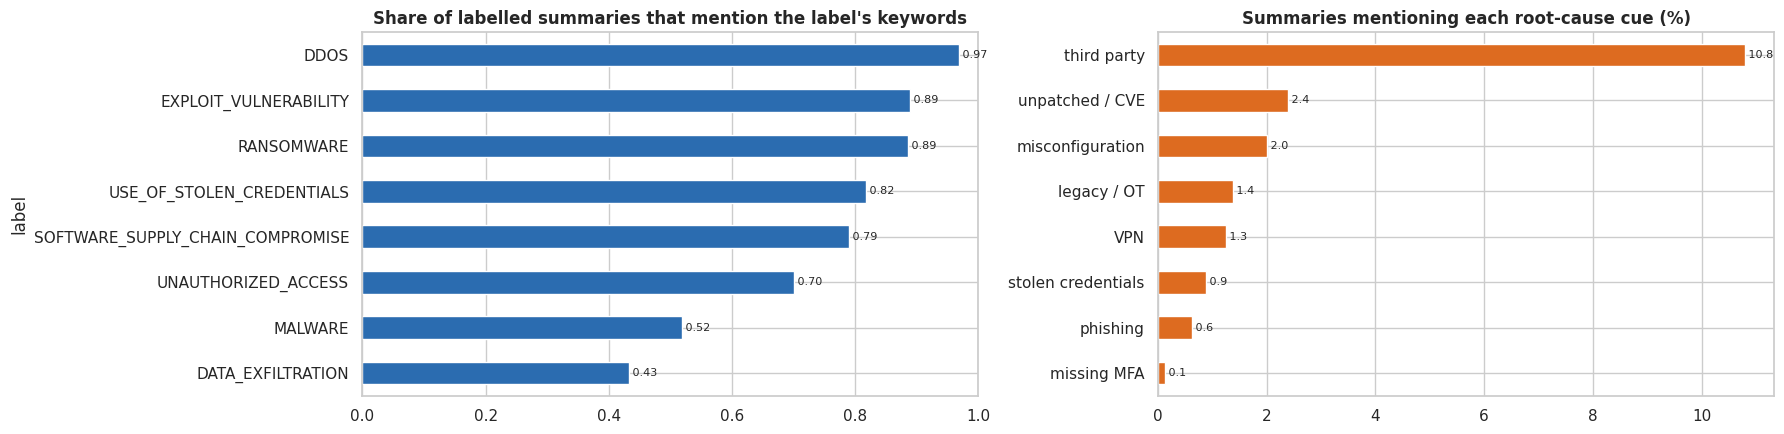

,records,keyword_recall,keyword_present_without_label
label,,,
RANSOMWARE,314,0.89,41
DDOS,65,0.97,5
DATA_EXFILTRATION,150,0.43,24
UNAUTHORIZED_ACCESS,268,0.70,129
MALWARE,52,0.52,13
SOFTWARE_SUPPLY_CHAIN_COMPROMISE,38,0.79,68
USE_OF_STOLEN_CREDENTIALS,22,0.82,22
EXPLOIT_VULNERABILITY,18,0.89,19


Summaries with at least one root-cause cue: 16.3% | records whose AttackTypes name an entry vector: 13.7%


In [34]:
# --- Recall of a label's own keywords in its summaries ---
KEYWORDS = {
    "RANSOMWARE": r"ransom",
    "DDOS": r"ddos|denial-of-service|denial of service",
    "DATA_EXFILTRATION": r"exfiltrat|stole|stolen data|leak",
    "UNAUTHORIZED_ACCESS": r"unauthori[sz]ed|intru|access",
    "MALWARE": r"malware|trojan|virus|loader",
    "SOFTWARE_SUPPLY_CHAIN_COMPROMISE": r"supply-chain|supply chain|update|vendor|third-party|software",
    "USE_OF_STOLEN_CREDENTIALS": r"credential|password|login",
    "EXPLOIT_VULNERABILITY": r"vulnerab|exploit|cve-|zero-day|patch",
}
rows = []
for label, rx in KEYWORDS.items():
    has = df["AttackTypes_list"].apply(lambda l: label in l)
    hit = summary_dn.str.contains(rx, case=False, regex=True)
    rows.append({"label": label, "records": int(has.sum()), "keyword_recall": hit[has].mean(),
                 "keyword_present_without_label": int((hit & ~has).sum())})
label_recall = pd.DataFrame(rows).set_index("label")

# --- Root-cause ('what allowed it') cues and entry-vector labels ---
ROOT_CAUSE = {
    "missing MFA":        r"\b(?:without|lack(?:ing)?|no)\s+(?:multi-factor|MFA|2FA)",
    "stolen credentials": r"stolen (?:vpn )?credential|compromised credential|compromised account",
    "VPN":                r"\bvpn\b",
    "unpatched / CVE":    r"unpatched|vulnerab|CVE-|zero-day",
    "third party":        r"third-party|vendor|supplier|provider|\bMSP\b",
    "phishing":           r"phish|social engineering",
    "misconfiguration":   r"misconfigur|exposed|publicly accessible",
    "legacy / OT":        r"legacy|\bOT\b|SCADA|industrial control",
}
rc = pd.DataFrame({k: summary_dn.str.contains(v, case=False, regex=True) for k, v in ROOT_CAUSE.items()})
VECTOR_LABELS = {"ACCOUNT_TAKEOVER", "ADVERSARY_IN_THE_MIDDLE", "BRUTE_FORCE", "BUSINESS_EMAIL_COMPROMISE",
                 "CREDENTIAL_STUFFING", "CROSS_SITE_REQUEST_FORGERY", "CROSS_SITE_SCRIPTING", "EXPLOIT_MISCONFIGURATION",
                 "EXPLOIT_VULNERABILITY", "HARDWARE_SUPPLY_CHAIN_COMPROMISE", "PASSWORD_SPRAYING", "PHISHING",
                 "PRETEXTING", "PRIVILEGE_ABUSE", "SOCIAL_ENGINEERING", "SOFTWARE_SUPPLY_CHAIN_COMPROMISE",
                 "SOFTWARE_UPDATE_COMPROMISE", "SPEARPHISHING", "SQL_INJECTION", "SUPPLY_CHAIN_COMPROMISE",
                 "THIRD_PARTY_PARTNER_COMPROMISE", "USE_OF_STOLEN_CREDENTIALS", "WEB_APPLICATION_ATTACK",
                 "ZERO_DAY_EXPLOITATION"}
assert VECTOR_LABELS <= CATALOGS["AttackTypes"]
df["has_vector_label"] = df["AttackTypes_list"].apply(lambda l: bool(VECTOR_LABELS & set(l)))

fig, axes = plt.subplots(1, 2, figsize=(18, 4.5))
label_recall["keyword_recall"].sort_values().plot.barh(ax=axes[0], color=BLUE)
axes[0].set_xlim(0, 1); axes[0].set_title("Share of labelled summaries that mention the label's keywords")
bar_labels(axes[0], label_recall["keyword_recall"].sort_values().values, fmt="{:.2f}")
(rc.mean() * 100).sort_values().plot.barh(ax=axes[1], color=ORANGE)
axes[1].set_title("Summaries mentioning each root-cause cue (%)")
bar_labels(axes[1], (rc.mean() * 100).sort_values().values, fmt="{:.1f}")
plt.tight_layout(); plt.show()
display(label_recall.round(2))
print(f"Summaries with at least one root-cause cue: {rc.any(axis=1).mean():.1%} | "
      f"records whose AttackTypes name an entry vector: {df['has_vector_label'].mean():.1%}")

### Interpretation

The narrative carries the attack information only partly. Each attack type has a distinctive vocabulary (`encrypted` for ransomware, `npm`, `packages`, `versions` for software-supply-chain compromise, `traffic` for DDoS). Keyword recall is high for **DDoS (0.97)**, **ransomware (0.89)** and **exploited vulnerabilities (0.89)**, but low for **data exfiltration (0.43)** and **malware (0.52)**, so those labels add information the text does not state explicitly. Many summaries also mention a concept without carrying its label (e.g. 129 mention access without `UNAUTHORIZED_ACCESS`).

The *how* of an attack is rarely documented: only **16.3%** of summaries mention any root-cause cue (third party, VPN, missing MFA, unpatched systems, misconfiguration) and only **13.7%** of records carry an entry-vector attack label. This is by design: the spec admits incidents for their **material consequences** (§3.1) and states that a vulnerability alone is not eligible (§2.3). The practical consequence for SCOUT is that questionnaire items about *consequences, sector and supply-chain area* will match TRACE far better than items about *security controls*; control-related questions need a separate knowledge source or a scoring layer.

## 3.8 Near-duplicate summaries
Pairs of summaries with high TF-IDF cosine similarity. Above ≈ 0.45 the pairs in this export are mostly the *same event written twice*; below it they are mostly *same attack type, different victim*.

Pairs with cosine >= 0.45: 13


,sim,title_a,title_b,date_a,date_b
7,0.705,N.L. health-care cyberattack forces mass appointment cancellations; Eastern Health hit,N.L. government health IT ransomware causes provincewide appointment cancellations,2021-10-30,2021-10-30
0,0.616,"North Carolina Ports cyberattack forces manual gate processing, delaying operations",North Carolina Ports cyberattack slows gate and port operations,2026-08-04,2026-08-04
6,0.608,LKQ 8-K: Cyber incident disrupted Canadian business unit operations for weeks,LKQ cyberattack disrupts Canadian business unit for several weeks,2024-11-13,2024-11-13
9,0.579,Cyberattack disrupts Northern Ireland C2k school network,Cyberattack disrupts Northern Ireland C2k school IT services,2026-04-03,2026-04-02
12,0.578,Cyberattack disables KC Scout traffic-management information systems,Cyberattack disables Kansas City Scout traffic-management systems,2024-04-25,2024-04-25
1,0.576,"Trinidad and Tobago Attorney General’s office hit by cyberattack, operations impacted",Cyberattack on Trinidad and Tobago’s AGLA disrupts operations and e-filing,2023-06-30,2023-06-30
5,0.569,Attacks on four Ukrainian ISPs cause week-long disruptions,Attacks on Ukrainian ISPs including Misto TV disrupt operations for over a week,2024-03-13,2024-03-13
11,0.516,Malware attack on Uttarakhand state data centre disrupts government operations,Malware attack on Uttarakhand State Data Centre halts government IT and citizen services,2024-10-02,2024-10-04
4,0.487,"Sankt Vinzenz Hospital Rheda-Wiedenbrück cyberattack (Dec 24, 2023)","Mathilden Hospital Herford cyberattack (Dec 24, 2023)",2023-12-24,2023-12-24
8,0.469,LiteLLM PyPI supply-chain compromise propagates to Mercor,LiteLLM supply-chain compromise distributes malicious PyPI releases,2026-03-24,2026-03-24


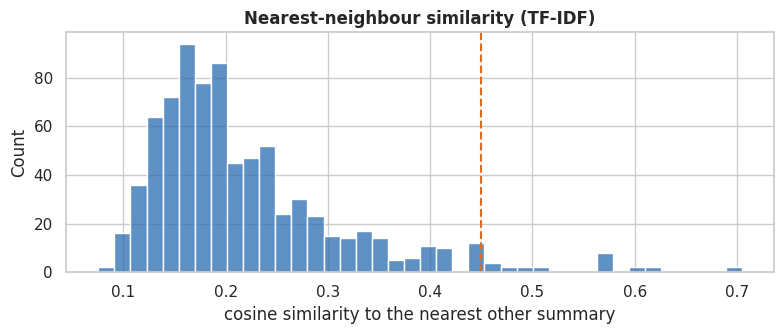

In [35]:
Xs = TfidfVectorizer(stop_words="english", sublinear_tf=True).fit_transform(summary_dn)
S_tfidf = cosine_similarity(Xs); np.fill_diagonal(S_tfidf, 0)
THRESH = 0.45
i, j = np.where(np.triu(S_tfidf) >= THRESH)
near = pd.DataFrame({"sim": S_tfidf[i, j].round(3),
                     "id_a": df["incidentId"].values[i], "id_b": df["incidentId"].values[j],
                     "title_a": df["IncidentTitle"].values[i], "title_b": df["IncidentTitle"].values[j],
                     "date_a": df["incident_date"].dt.date.values[i], "date_b": df["incident_date"].dt.date.values[j]}
                    ).sort_values("sim", ascending=False)
print(f"Pairs with cosine >= {THRESH}: {len(near)}")
display(near.drop(columns=["id_a", "id_b"]))

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.histplot(S_tfidf.max(axis=1), bins=40, ax=ax, color=BLUE)
ax.axvline(THRESH, color=ORANGE, ls="--"); ax.set_xlabel("cosine similarity to the nearest other summary")
ax.set_title("Nearest-neighbour similarity (TF-IDF)")
plt.tight_layout(); plt.show()

### Interpretation

**13** pairs exceed the 0.45 threshold, and almost all describe the same event twice: same date, same victim, paraphrased title (Newfoundland & Labrador health system, North Carolina Ports, LKQ, Northern Ireland C2k, Kansas City Scout, Trinidad & Tobago AGLA, Ukrainian ISPs, Uttarakhand data centre, LiteLLM). A few are borderline — two German hospitals attacked the same day, Rotterdam and Amsterdam port websites hit in the same DDoS wave — which are separate victims of one campaign. The nearest-neighbour histogram shows that most summaries have no close twin. Without de-duplication, SCOUT's top-k would show some incidents twice, so the second member of each pair is flagged in Part 4.

# Part 4 — Preprocessing

Every decision below is motivated by a finding from Parts 1–3. Source columns are never overwritten: cleaned text, normalized labels, flags and documents live in new columns or dataframes, so each step is reversible and auditable.

## 4.1 Text-quality audit
Before deciding how to clean, the audit separates *corruption* (mojibake, replacement characters, HTML entities, control or zero-width characters) from *valid but inconvenient* Unicode (typographic dashes and quotes) and from content that should not reach an embedding model (URLs).

In [36]:
# --- Noise report per text field ---
MOJI     = re.compile(r"(?:Ã.|Â.|â€.|ï¿½|\ufffd)")
URL_RX   = re.compile(r"https?://\S+|www\.\S+")
HTML_ENT = re.compile(r"&(?:[a-z]+|#\d+);")
INVIS    = re.compile(r"[\u200B-\u200D\uFEFF\x00-\x08\x0B\x0C\x0E-\x1F\x7F]")

def noise_report(s):
    s = s.dropna().astype(str)
    return {"records": len(s),
            "mojibake / replacement char": int(s.str.contains(MOJI).sum()),
            "HTML entities": int(s.str.contains(HTML_ENT).sum()),
            "zero-width / control chars": int(s.str.contains(INVIS).sum()),
            "URLs": int(s.str.contains(URL_RX).sum()),
            "typographic dashes": int(s.str.contains(DASH_CLASS).sum()),
            "any non-ASCII": int(s.str.contains(r"[^\x00-\x7F]").sum())}

noise_before = pd.DataFrame({c: noise_report(df[c]) for c in TEXT_COLS}).T
display(noise_before)

# Inventory of non-ASCII characters in Summary: what must be mapped vs what must be kept
chars = Counter(ch for t in df["Summary"] for ch in t if ord(ch) > 127)
display(pd.DataFrame([(ch, f"U+{ord(ch):04X}", unicodedata.name(ch, "?"), n) for ch, n in chars.most_common(15)],
                     columns=["char", "codepoint", "unicode_name", "count"]))

# Words joined by a NON-BREAKING hyphen (U+2011): exactly the domain terms SCOUT needs to match
print("Words written with U+2011:", df["Summary"].str.findall(r"\w+\u2011\w+(?:\u2011\w+)*").explode().dropna()
      .value_counts().head(15).to_dict())

,records,mojibake / replacement char,HTML entities,zero-width / control chars,URLs,typographic dashes,any non-ASCII
IncidentTitle,797,0,0,0,0,26,79
Summary,797,0,0,0,2,105,214
ReliabilityFeedback,750,0,0,0,191,272,410


,char,codepoint,unicode_name,count
0,’,U+2019,RIGHT SINGLE QUOTATION MARK,125
1,‑,U+2011,NON-BREAKING HYPHEN,124
2,ó,U+00F3,LATIN SMALL LETTER O WITH ACUTE,75
3,–,U+2013,EN DASH,30
4,í,U+00ED,LATIN SMALL LETTER I WITH ACUTE,23
5,é,U+00E9,LATIN SMALL LETTER E WITH ACUTE,20
6,—,U+2014,EM DASH,12
7,ú,U+00FA,LATIN SMALL LETTER U WITH ACUTE,8
8,á,U+00E1,LATIN SMALL LETTER A WITH ACUTE,7
9,€,U+20AC,EURO SIGN,6


Words written with U+2011: {'third‑party': 10, '8‑K': 7, 'zero‑day': 5, 'large‑scale': 4, 'e‑commerce': 3, 'supply‑chain': 3, 'CVE‑2023‑34362': 3, 'check‑in': 2, 'multi‑week': 2, 'multi‑day': 2, 'Co‑op': 2, 'national‑level': 2, 'INCIBE‑CERT': 2, 'customer‑facing': 2, 'six‑day': 1}


In [37]:
# --- Surface patterns that tokenizers and embeddings handle poorly (dash-normalized text) ---
PATTERNS = {
    "date dd/mm/yyyy": r"\b\d{1,2}/\d{1,2}/\d{4}\b",
    "date in words":   r"\b\d{1,2}\s+(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)[a-z]*\s+\d{4}\b|\b(?:January|February|March|April|May|June|July|August|September|October|November|December)\s+\d{1,2},?\s+\d{4}",
    "money":           r"[$€£]\s?\d[\d,.]*\s*(?:million|billion|M|B|k)?|\d[\d,.]*\s*(?:million|billion)\s*(?:USD|EUR|dollars|euros)?",
    "percent":         r"\d+(?:\.\d+)?\s?%",
    "CVE id":          r"(?i)\bCVE-\d{4}-\d{4,7}\b",
    "IPv4":            r"\b(?:\d{1,3}\.){3}\d{1,3}\b",
    "URL":             r"https?://\S+",
    "ALL-CAPS entity": r"\b[A-Z][A-Z&.\-]{2,}(?:\s+[A-Z][A-Z&.\-]{2,})+\b",
    "acronym":         r"\b[A-Z]{2,5}s?\b",
}
pat = pd.DataFrame({c: {name: int(df[c].dropna().str.replace(DASH_CLASS, "-", regex=True).str.contains(rx, regex=True).sum())
                        for name, rx in PATTERNS.items()} for c in TEXT_COLS})
display(pat.rename(columns=lambda c: f"{c} (records)"))
for name in ["acronym", "CVE id", "ALL-CAPS entity"]:
    hits = summary_dn.str.findall(PATTERNS[name]).explode().dropna()
    print(f"{name}: {hits.value_counts().head(12).to_dict()}")

,IncidentTitle (records),Summary (records),ReliabilityFeedback (records)
date dd/mm/yyyy,2,175,50
date in words,3,404,68
money,15,69,41
percent,0,9,15
CVE id,0,3,4
IPv4,0,1,1
URL,0,2,191
ALL-CAPS entity,25,55,17
acronym,216,423,489


acronym: {'IT': 161, 'SEC': 16, 'USD': 14, 'TRACE': 11, 'VPN': 10, 'TV': 10, 'UK': 8, 'CERT': 8, 'CI': 7, 'ISP': 6, 'CD': 6, 'DE': 6}
CVE id: {'CVE-2023-34362': 3}
ALL-CAPS entity: {'COLONIAL PIPELINE': 1, 'WARD TRANSPORT AND LOGISTICS': 1, 'FEDERATED COOPERATIVES': 1, 'PROGRESS SOFTWARE': 1, 'BRITISH AIRWAYS': 1, 'JAS WORLDWIDE': 1, 'COGNIZANT TECHNOLOGY SOLUTIONS': 1, 'UNITED NATURAL FOODS': 1, 'CDK GLOBAL': 1, 'MGM RESORTS INTERNATIONAL': 1, 'SCATTERED SPIDER': 1, 'FORWARD AIR': 1}


### Interpretation

There is **no encoding corruption**: no mojibake, replacement characters, HTML entities, zero-width or control characters in any text field. The non-ASCII content is valid typography and language: curly apostrophes (125), **non-breaking hyphens U+2011 (124)**, en/em dashes, and accented letters from Spanish, Portuguese and German names. The non-breaking hyphen matters because it sits inside exactly the terms SCOUT needs to match — `third‑party` (10), `zero‑day` (5), `supply‑chain` (3), `CVE‑2023‑34362` (3), `e‑commerce`, `8‑K` — and a regex or keyword search for `third-party` misses them. Summaries also contain many dates (dd/mm/yyyy in 175, written dates in 404), money amounts (69), acronyms (`IT` 161, `SEC`, `VPN`, `CERT`) and company names in capitals (55). `ReliabilityFeedback` holds 191 URLs; only 2 summaries contain one.

## 4.2 Conservative text cleaning
Two representations are kept apart:

1. **Semantic-clean text** (input to embeddings and to the LLM): Unicode NFKC; every hyphen/dash variant mapped to `-` and curly quotes to straight quotes; URLs removed (sources already live in `MainSources` / `AdditionalSources`); invisible characters removed; whitespace collapsed. Case, accents, numbers, acronyms and punctuation are **preserved**, and no stemming, lemmatization or stop-word removal is applied, because transformer embeddings rely on natural text and stemming damages domain terms (`ransomware` → `ransomwar`).
2. **Exploration tokens** (lower-cased, stop words removed) are used only for frequency statistics, as in Part 2.

In [38]:
# --- Semantic cleaning (applied to new *_clean columns) ---
TRANSLATE = {ord(c): "-" for c in "\u2010\u2011\u2012\u2013\u2014\u2212"}
TRANSLATE.update({ord("\u2018"): "'", ord("\u2019"): "'", ord("\u201C"): '"', ord("\u201D"): '"',
                  ord("\u00A0"): " ", ord("\u2192"): "->"})

def clean_semantic_text(value):
    if pd.isna(value):
        return np.nan
    t = unicodedata.normalize("NFKC", html.unescape(str(value)))
    t = t.translate(TRANSLATE)
    t = URL_RX.sub("", t)
    t = INVIS.sub(" ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t if t else np.nan

for c in TEXT_COLS:
    df[f"{c}_clean"] = df[c].apply(clean_semantic_text)

noise_after = pd.DataFrame({c: noise_report(df[f"{c}_clean"]) for c in TEXT_COLS}).T
changed = pd.Series({c: int((df[c].fillna("") != df[f"{c}_clean"].fillna("")).sum()) for c in TEXT_COLS}, name="records changed")
display(pd.concat({"before": noise_before, "after": noise_after}))
print("Records changed by cleaning:", changed.to_dict())

remaining = Counter(ch for t in df["Summary_clean"] for ch in t if ord(ch) > 127)
print("Non-ASCII left in Summary_clean (valid letters/symbols, kept on purpose):", dict(remaining.most_common(12)))

# Before / after examples: the records where cleaning changed the most characters
diff = (df["Summary"] != df["Summary_clean"])
for i in df[diff].index[:3]:
    print(f"\n[{i}] BEFORE: {df.loc[i, 'Summary'][:230]}\n[{i}] AFTER : {df.loc[i, 'Summary_clean'][:230]}")

records  mojibake / replacement char  HTML entities  zero-width / control chars  URLs  typographic dashes  any non-ASCII
before IncidentTitle            797                            0              0                           0     0                  26             79
       Summary                  797                            0              0                           0     2                 105            214
       ReliabilityFeedback      750                            0              0                           0   191                 272            410
after  IncidentTitle            797                            0              0                           0     0                   0             34
       Summary                  797                            0              0                           0     0                   0             67
       ReliabilityFeedback      750                            0              0                           0     0                   0             69

Records changed by cleaning: {'IncidentTitle': 51, 'Summary': 175, 'ReliabilityFeedback': 442}
Non-ASCII left in Summary_clean (valid letters/symbols, kept on purpose): {'ó': 75, 'í': 23, 'é': 20, 'ú': 8, 'á': 7, '€': 6, 'ü': 5, 'ç': 4, 'ã': 3, 'ł': 3, 'ä': 2, 'ö': 2}

[0] BEFORE: On 07/05/2021, COLONIAL PIPELINE shut pipeline operations to contain a DarkSide ransomware intrusion in its IT network. The FBI publicly confirmed DarkSide on 10/05/2021. Huntress reports attackers used stolen VPN credentials lack
[0] AFTER : On 07/05/2021, COLONIAL PIPELINE shut pipeline operations to contain a DarkSide ransomware intrusion in its IT network. The FBI publicly confirmed DarkSide on 10/05/2021. Huntress reports attackers used stolen VPN credentials lack

[2] BEFORE: In late June 2024, FEDERATED COOPERATIVES reported a cybersecurity incident affecting internal and customer‑facing systems. Member Co‑op locations across Western Canada saw inventory issues, website outages and online shopping sus


### Interpretation

Cleaning changed **175 summaries**, **51 titles** and **442 feedback texts**, and every change is typographic: after cleaning, no field contains a typographic dash or URL, and the only non-ASCII characters left are legitimate letters and symbols (`ó`, `í`, `é`, `€`, `ü`…), kept on purpose. The examples show the effect: `customer‑facing` → `customer-facing`, `CVE‑2023‑34362` → `CVE-2023-34362`, `SOFTWARE’s` → `SOFTWARE's`. This resolves a gap in both earlier notebooks: NFC normalization alone changes nothing (U+2011 is valid Unicode), and a quote/dash map that omits U+2010/U+2011 leaves the domain terms split.

## 4.3 Label normalization
Multi-label cells are stored as **sets**: labels stripped, redundant `OTHER(...)` mapped to their frozen code (Part 1.6), duplicates removed and sorted. For the semantic documents, catalog codes are also rendered in plain words (`PRODUCTION&MANUFACTURING` → *production & manufacturing*), since an embedding model reads words, not database codes.

In [39]:
# --- Canonical label strings + human-readable rendering ---
def humanize(label):
    m = OTHER_RX.match(label)
    label = m.group(1) if m else label                        # OTHER(LABOR_UNIONS) -> LABOR_UNIONS
    return label.replace("&", " & ").replace("_", " ").lower().replace("  ", " ").strip()

for col in MULTI_COLS + ["SupplyChainRoles"]:
    df[f"{col}_canonical"] = df[f"{col}_list"].apply(canonical)

canon = pd.DataFrame({
    "raw_combinations": {c: df[c].nunique() for c in MULTI_COLS},
    "canonical_combinations": {c: df[f"{c}_canonical"].nunique() for c in MULTI_COLS},
    "cells_changed": {c: int((df[c].fillna("") != df[f"{c}_canonical"].fillna("")).sum()) for c in MULTI_COLS}})
canon["reduction_%"] = ((1 - canon["canonical_combinations"] / canon["raw_combinations"]) * 100).round(1)
display(canon.sort_values("reduction_%", ascending=False))
print("Example:", df.loc[0, "ImpactTypes"], "->", [humanize(x) for x in df.loc[0, "ImpactTypes_list"]])

,raw_combinations,canonical_combinations,cells_changed,reduction_%
AffectedTargetedCompanyDepartments,138,82,271,40.6
MostAffectedSupplyChainSection,33,20,71,39.4
ImpactTypes,324,211,620,34.9
SourceLanguages,70,48,797,31.4
AffectedSectors,118,84,116,28.8
AttackTypes,170,130,256,23.5
AffectedCountries,108,105,25,2.8
ImpactedGeographicRegions,204,203,21,0.5
ThreatActorNames,94,94,6,0.0
SupplyChainRelations,76,76,36,0.0


Example: TRANSPORTATION_DISRUPTION,SERVICE_UNAVAILABILITY,OPERATIONAL_DISRUPTION,LOGISTICS_DELAY -> ['transportation disruption', 'service unavailability', 'operational disruption', 'logistics delay']


### Interpretation

Canonicalization rewrites the format of many cells (e.g. 620 `ImpactTypes` cells) but never adds or removes a label. It reduces distinct combinations by **40.6%** for departments, **39.4%** for supply-chain section (33 → 20, including the `OTHER(SERVICE_DELIVERY)` remap) and **34.9%** for impact types. The plain-word rendering (`TRANSPORTATION_DISRUPTION` → *transportation disruption*) is what goes into the semantic documents; the canonical strings remain available for filtering and display.

## 4.4 Missing values, outliers and high cardinality

**Missing values.** Sparse fields are facts that were not reported or not verifiable (§7.20: defensibility over completeness). Imputing a mean duration, a modal sector or a placeholder actor would invent incident facts. Strategy: keep `NaN`; omit missing fields from the semantic document instead of writing `nan`; keep missingness measurable through the flags in 4.5.

**Outliers.** IQR-extreme values (Part 2.2) are retained and flagged (`iqr_outlier_*`). They are real high-consequence incidents (Change Healthcare, multi-month library outages), which is exactly what SCOUT should be able to retrieve.

**High cardinality.** Company names, titles, URLs and IDs are not one-hot encoded and are kept as metadata. Multi-label fields are handled as label sets (4.3). Top-K truncation is used only for readable charts; long-tail labels stay in the data.

**Class imbalance.** No supervised target exists at this stage (SCOUT is a retrieval system), so no resampling is applied. Imbalance is reported descriptively (e.g. government and healthcare dominate the sectors) because it affects what the retriever *can* return.

In [40]:
# --- Explicit check: no source field was imputed or overwritten ---
source_missing_before = int(df_raw.isna().sum().sum())
source_missing_after  = int(df[df_raw.columns].isna().sum().sum())
same_text = all(df_raw[c].equals(df[c]) for c in df_raw.columns if c not in DATE_COLS)
print(f"Missing cells in source columns: before = {source_missing_before:,} | after = {source_missing_after:,}")
print("Non-date source columns unchanged:", same_text, "| date columns: parsed copies added, raw strings kept in df_raw")

Missing cells in source columns: before = 4,245 | after = 4,245
Non-date source columns unchanged: True | date columns: parsed copies added, raw strings kept in df_raw


## 4.5 Data-quality flags and the reference base for retrieval
Problems are recorded as boolean `flag_*` columns instead of deleting rows, so the retrieval stage can decide what to filter. The **reference base** is the set of incidents SCOUT may return.

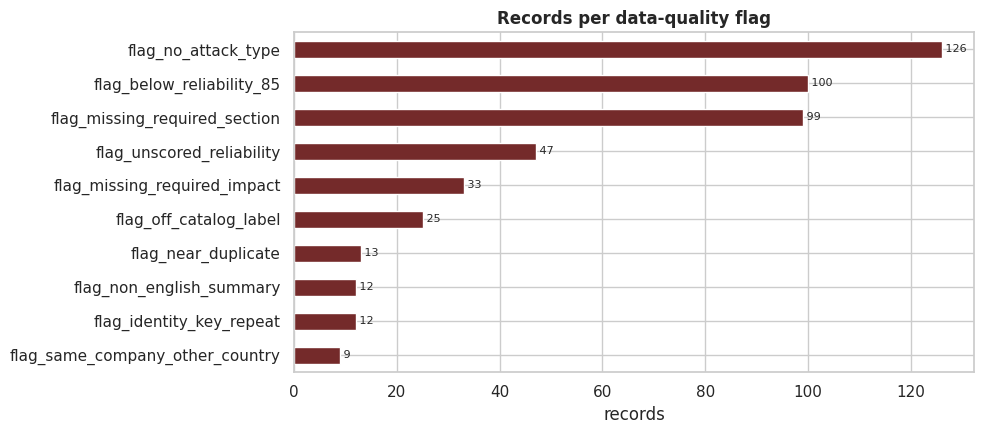

,incidents in reference base
no near-duplicates (default),784
+ spec-required fields,678
+ TRACE-ready (>= 85),639
+ both,566


Reference base used below: 784 of 797 incidents


In [41]:
# --- Data-quality flags (audit columns; nothing is deleted) ---
same_company_other_country = df["TargetedCompany"].isin(cross_country["TargetedCompany"])
df["flag_near_duplicate"]            = df["incidentId"].isin(set(near["id_b"]))      # keep first of each pair
df["flag_identity_key_repeat"]       = df["identity_key_repeat"]                       # §12.2 review candidates
df["flag_same_company_other_country"] = same_company_other_country                    # §7.5 country inconsistency
df["flag_missing_required_impact"]   = df["ImpactTypes"].isna()                        # §7.10
df["flag_missing_required_section"]  = df["MostAffectedSupplyChainSection"].isna()     # §7.12
df["flag_off_catalog_label"]         = df["off_catalog_labels"].str.len() > 0          # §14 / §8.7
df["flag_below_reliability_85"]      = df["ReliabilityScore"] < 85                      # §10.4
df["flag_unscored_reliability"]      = df["ReliabilityScore"].isna()
df["flag_no_attack_type"]            = df["AttackTypes"].isna()                         # allowed by the spec
df["flag_non_english_summary"]       = df["summary_lang"] != "en"
FLAG_COLS = [c for c in df.columns if c.startswith("flag_")]

flag_counts = df[FLAG_COLS].sum().sort_values()
fig, ax = plt.subplots(figsize=(10, 4.5))
flag_counts.plot.barh(ax=ax, color=MAROON)
bar_labels(ax, flag_counts.values)
ax.set_title("Records per data-quality flag"); ax.set_xlabel("records")
plt.tight_layout(); plt.show()

# Reference base: drop the second member of each near-duplicate pair. Two optional, stricter policies:
REQUIRE_SPEC_FIELDS = False      # also require ImpactTypes and MostAffectedSupplyChainSection (§7.10, §7.12)
REQUIRE_TRACE_READY = False      # also require ReliabilityScore >= 85 (§10.4)
base = ~df["flag_near_duplicate"]
options = {"no near-duplicates (default)": base,
           "+ spec-required fields": base & ~df["flag_missing_required_impact"] & ~df["flag_missing_required_section"],
           "+ TRACE-ready (>= 85)": base & (df["ReliabilityScore"] >= 85),
           "+ both": base & ~df["flag_missing_required_impact"] & ~df["flag_missing_required_section"] & (df["ReliabilityScore"] >= 85)}
display(pd.Series({k: int(v.sum()) for k, v in options.items()}, name="incidents in reference base").to_frame())
df["in_reference_base"] = base
if REQUIRE_SPEC_FIELDS:
    df["in_reference_base"] &= ~df["flag_missing_required_impact"] & ~df["flag_missing_required_section"]
if REQUIRE_TRACE_READY:
    df["in_reference_base"] &= df["ReliabilityScore"] >= 85
print(f"Reference base used below: {df['in_reference_base'].sum()} of {len(df)} incidents")

### Interpretation

Flags make every quality issue filterable without losing records. The most frequent are the missing spec-required section (**99**) and impact types (**33**), records below the reliability threshold (**100**) or unscored (**47**), and records without an attack type (**126**, allowed by the spec). The default reference base provisionally excludes the **13** identified near-duplicate candidates and retains **784** incidents. This is an initial preprocessing choice rather than a definitive deduplication decision, as some candidates may represent distinct organizations affected by the same cyberattack. Stricter policies shrink the reference base quickly: requiring the spec-mandatory fields leaves **678** incidents, requiring TRACE-ready reliability leaves **639**, and applying both leaves **566**. Because recall matters for a retrieval prototype, the default retains the larger reference base and uses reliability for ranking instead; either policy can be enabled with one variable. The deduplication approach remains open to refinement as the project progresses.

## 4.6 Feature relevance and selection for SCOUT
SCOUT is a retrieval system, not a classifier, so features are selected by (a) whether they describe *what happened and to whom in supply-chain terms* — the information a questionnaire can express — (b) coverage, and (c) the spec's definition of each field.

In [42]:
FEATURE_ROLES = {
    "IncidentTitle":   ("Semantic text", "Concise, source-grounded description of the event (§7.2)."),
    "Summary":         ("Semantic text", "Complete narrative: cyber event + material consequence (§7.3)."),
    "AffectedSectors": ("Semantic text", "Economic activities with material consequences; maps to the questionnaire's sector (§7.14)."),
    "MostAffectedSupplyChainSection": ("Semantic text", "Where the consequence manifested; the core supply-chain dimension (§7.12)."),
    "AffectedTargetedCompanyDepartments": ("Semantic text", "Internal functions affected; maps to the user's business functions (§7.11)."),
    "AttackTypes":     ("Semantic text", "How the event occurred (§7.9); 16% missing, allowed by the spec."),
    "ImpactTypes":     ("Semantic text", "Material consequences (§7.10); best-covered consequence field."),
    "SupplyChainRelations": ("Semantic text (roles only)", "Role of the attacked firm toward affected partners (§7.13); company names omitted, 90% missing."),
    "CountryTargetedCompany": ("Metadata filter", "Lets SCOUT prefer same-country cases; US-skewed, so better as a filter than as text."),
    "AffectedCountries": ("Metadata filter", "Where consequences occurred (§7.15)."),
    "ImpactedGeographicRegions": ("Metadata", "52% missing and 37 format violations."),
    "TargetedCompany": ("Metadata (display)", "Identity of the victim; matching on names would retrieve 'who', not 'what happened'."),
    "ThreatActorNames": ("Metadata (display)", "75% missing; a questionnaire user does not know the future attacker."),
    "ApproximateIncidentDate": ("Metadata filter", "Recency filter/tie-breaker; dates add no semantic similarity."),
    "EstimatedSeverity": ("Ranking / display", "Consequence magnitude (§7.19); show 'what happened to similar firms'."),
    "AttackDurationDays": ("Display when present", "74% missing; outcome information, not similarity."),
    "FinancialImpact": ("Display when present", "USD millions (§7.8); 94% missing."),
    "ReliabilityScore": ("Filter / ranking", "Evidence quality (§10.4); can down-rank weak cases."),
    "ReliabilityFeedback": ("Excluded", "Verifier's commentary about sources, not incident content."),
    "SourceLanguages": ("Metadata", "Language of the evidence, not of the incident."),
    "MainSources": ("Metadata (provenance)", "Evidence URLs shown to the user; noise for embeddings."),
    "AdditionalSources": ("Metadata (provenance)", "Supplementary evidence URLs."),
    "incidentId": ("Key", "Primary key linking documents, embeddings and metadata."),
    "ResearchRequestID": ("Excluded", "Research batch identifier."),
    "State": ("Excluded", "Constant (PUBLISHED)."),
    "TimesEnriched": ("Excluded", "Process metadata."),
    "created_at": ("Excluded", "Record-processing timestamp."),
    "updated_at": ("Excluded", "Record-processing timestamp."),
}
assert set(FEATURE_ROLES) == set(df_raw.columns)
feature_table = pd.DataFrame([{"feature": f, "role": r, "missing_%": round(df_raw[f].isna().mean() * 100, 1),
                               "distinct_values_or_labels": int(df[f"{f}_list"].explode().nunique()) if f"{f}_list" in df else int(df_raw[f].nunique()),
                               "rationale": why} for f, (r, why) in FEATURE_ROLES.items()]).set_index("feature")
display(feature_table.sort_values("role"))

,role,missing_%,distinct_values_or_labels,rationale
feature,,,,
FinancialImpact,Display when present,94.4,42,USD millions (§7.8); 94% missing.
AttackDurationDays,Display when present,73.7,64,"74% missing; outcome information, not similarity."
updated_at,Excluded,0.0,21,Record-processing timestamp.
TimesEnriched,Excluded,65.5,6,Process metadata.
State,Excluded,0.0,1,Constant (PUBLISHED).
ResearchRequestID,Excluded,0.0,21,Research batch identifier.
ReliabilityFeedback,Excluded,5.9,750,"Verifier's commentary about sources, not incident content."
created_at,Excluded,0.0,21,Record-processing timestamp.
ReliabilityScore,Filter / ranking,5.9,26,Evidence quality (§10.4); can down-rank weak cases.


### Interpretation

The semantic representation uses the fields that describe *what happened and where in the supply chain*: title, summary, sectors, supply-chain section, departments, attack types, impact types and the role of the attacked firm toward affected partners. They are nearly complete (0–16% missing) except relations (90%), which enter only when present. Company names, actors, dates and countries become metadata: they answer *who* and *when*, which a questionnaire user cannot share with past victims, and including them would make the model match names instead of situations. Severity, duration, financial impact and reliability are outcome and quality information used to rank and explain results. URLs, IDs, timestamps and the verifier's feedback are excluded.

## 4.7 One semantic document per incident
Three designs are built so they can be compared empirically in 4.9:

* **Full record** — every descriptive field as stored (raw codes, company, date, actor, severity, numbers), the design used in the earlier team notebooks.
* **SCOUT document** — only the fields marked *Semantic text* in 4.6: cleaned title and summary plus the supply-chain labels in plain words.
* **SCOUT profile** — the same plain-word labels *without* the narrative: a compact description of *who was affected and how*, written in the same vocabulary a questionnaire produces.

Missing fields are omitted, never written as `nan`.

In [43]:
FULL_FIELDS = [("Incident", "IncidentTitle_clean"), ("Approximate date", "ApproximateIncidentDate"),
               ("Targeted company", "TargetedCompany"), ("Company country", "CountryTargetedCompany"),
               ("Affected sectors", "AffectedSectors"), ("Affected countries", "AffectedCountries"),
               ("Impacted geography", "ImpactedGeographicRegions"), ("Attack types", "AttackTypes"),
               ("Threat actor", "ThreatActorNames"), ("Most affected supply-chain section", "MostAffectedSupplyChainSection"),
               ("Affected departments", "AffectedTargetedCompanyDepartments"), ("Supply-chain relations", "SupplyChainRelations"),
               ("Impact types", "ImpactTypes"), ("Attack duration in days", "AttackDurationDays"),
               ("Estimated severity", "EstimatedSeverity"), ("Financial impact (USD millions)", "FinancialImpact"),
               ("Summary", "Summary_clean")]
SCOUT_FIELDS = [("Incident", "IncidentTitle_clean"), ("Summary", "Summary_clean"),
                ("Affected sectors", "AffectedSectors_list"), ("Supply-chain areas affected", "MostAffectedSupplyChainSection_list"),
                ("Business functions affected", "AffectedTargetedCompanyDepartments_list"),
                ("Attack types", "AttackTypes_list"), ("Impacts", "ImpactTypes_list"),
                ("Role of the attacked organization toward affected partners", "SupplyChainRoles_list")]

def fmt(value):
    if isinstance(value, list):
        return ", ".join(dict.fromkeys(humanize(v) for v in value)) or None
    if pd.isna(value):
        return None
    if isinstance(value, float) and value.is_integer():
        return str(int(value))
    return str(value).strip() or None

def build_document(row, fields):
    return "\n".join(f"{label}: {v}" for label, col in fields if (v := fmt(row[col])))

df["doc_full"]  = df.apply(build_document, axis=1, fields=FULL_FIELDS)
df["doc_scout"] = df.apply(build_document, axis=1, fields=SCOUT_FIELDS)
df["doc_profile"] = df.apply(build_document, axis=1, fields=SCOUT_FIELDS[2:])        # labels only, no narrative
assert df["doc_scout"].str.len().gt(0).all() and not df["doc_scout"].str.contains(r"\bnan\b", case=False).any()

print("SCOUT document — incident 0\n" + "-" * 60 + "\n" + df.loc[0, "doc_scout"])
print("\nSCOUT profile — incident 0\n" + "-" * 60 + "\n" + df.loc[0, "doc_profile"])
print("\nFull record — incident 0\n" + "-" * 60 + "\n" + df.loc[0, "doc_full"])

SCOUT document — incident 0
------------------------------------------------------------
Incident: Colonial Pipeline ransomware halts East Coast fuel flow
Summary: On 07/05/2021, COLONIAL PIPELINE shut pipeline operations to contain a DarkSide ransomware intrusion in its IT network. The FBI publicly confirmed DarkSide on 10/05/2021. Huntress reports attackers used stolen VPN credentials lacking MFA and exfiltrated ~100 GB of data before encryption. Colonial restarted the pipeline on 12/05/2021 after a six-day shutdown and paid a $4.4 million ransom, with fuel shortages and emergency measures across the U.S. East Coast and Southeast.
Affected sectors: energy and utilities, transportation
Supply-chain areas affected: distribution & fulfillment
Business functions affected: information technology, facilities and physical operations
Attack types: ransomware, use of stolen credentials, data exfiltration
Impacts: transportation disruption, service unavailability, operational disruption, logis

## 4.8 Tokenization
Two tokenizations answer two different questions. **Word-level tokens** (regex) describe corpus size. **Model tokens** — produced by the WordPiece tokenizer of the embedding model itself — decide whether a document fits the model's 512-token window and how chunking would behave.

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded BAAI/bge-small-en-v1.5 | max sequence length: 512 tokens


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (731 > 512). Running this sequence through the model will result in indexing errors


,count,mean,std,min,25%,50%,75%,max
Summary (words),797.0,56.0,15.3,22.0,45.0,54.0,64.0,119.0
Summary (model tokens),797.0,75.0,21.4,27.0,60.0,72.0,85.0,193.0
SCOUT doc (words),797.0,96.2,19.8,46.0,83.0,95.0,106.0,168.0
SCOUT doc (model tokens),797.0,135.4,28.7,68.0,116.0,132.0,149.0,280.0
Full record (model tokens),797.0,184.6,40.4,98.0,159.0,181.0,201.0,731.0
SCOUT profile (model tokens),797.0,42.5,12.7,11.0,35.0,41.0,48.0,123.0


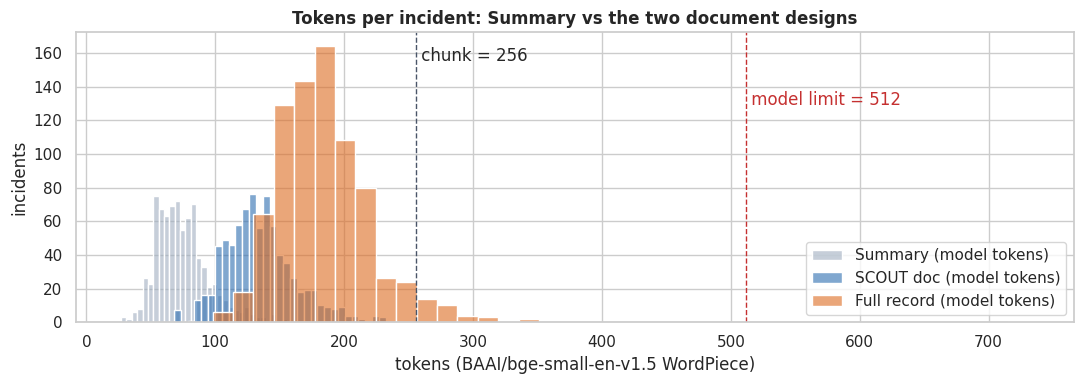

SCOUT doc (model tokens): > 512 tokens: 0 | single 256-token chunk: 99.7% | total chunks: 799
Full record (model tokens): > 512 tokens: 1 | single 256-token chunk: 95.6% | total chunks: 834
Example model tokens: ['on', '07', '/', '05', '/', '2021', ',', 'colonial', 'pipeline', 'shut', 'pipeline', 'operations', 'to', 'contain', 'a', 'dark', '##side', 'ransom', '##ware', 'intrusion', 'in', 'its', 'it', 'network', '.', 'the', 'fbi', 'publicly', 'confirmed', 'dark']


In [44]:
# --- Load the embedding model once (its tokenizer is used here, its encoder in 4.9) ---
def load_embedder():
    if not RUN_EMBEDDINGS:
        print("RUN_EMBEDDINGS = False -> regex token approximation and TF-IDF + SVD vectors will be used.")
        return None
    try:
        from sentence_transformers import SentenceTransformer
        model = SentenceTransformer(EMBED_MODEL)
        print(f"Loaded {EMBED_MODEL} | max sequence length: {model.max_seq_length} tokens")
        return model
    except Exception as err:
        print(f"Embedding model unavailable ({type(err).__name__}: {str(err)[:100]}) -> using fallbacks.")
        return None

embedder = load_embedder()
model_tokenize = embedder.tokenizer.tokenize if embedder is not None else (lambda t: re.findall(r"\w+|[^\w\s]", t))
TOKENIZER_NAME = f"{EMBED_MODEL} WordPiece" if embedder is not None else "regex approximation"

tok = pd.DataFrame({
    "Summary (words)":            df["Summary_clean"].str.findall(r"\b[\w&'\-]+\b").str.len(),
    "Summary (model tokens)":     df["Summary_clean"].apply(lambda t: len(model_tokenize(t))),
    "SCOUT doc (words)":          df["doc_scout"].str.findall(r"\b[\w&'\-]+\b").str.len(),
    "SCOUT doc (model tokens)":   df["doc_scout"].apply(lambda t: len(model_tokenize(t))),
    "Full record (model tokens)": df["doc_full"].apply(lambda t: len(model_tokenize(t))),
    "SCOUT profile (model tokens)": df["doc_profile"].apply(lambda t: len(model_tokenize(t))),
})
display(tok.describe().T.round(1))

def n_chunks(t, size=CHUNK_TOKENS, ov=CHUNK_OVERLAP):
    return 1 if t <= size else int(np.ceil((t - ov) / (size - ov)))

fig, ax = plt.subplots(figsize=(11, 4))
for col, color in [("Summary (model tokens)", GREY), ("SCOUT doc (model tokens)", BLUE), ("Full record (model tokens)", ORANGE)]:
    sns.histplot(tok[col], bins=40, ax=ax, color=color, alpha=0.6, label=col)
ax.axvline(CHUNK_TOKENS, color=SLATE, ls="--", lw=1); ax.text(CHUNK_TOKENS, ax.get_ylim()[1] * 0.9, f" chunk = {CHUNK_TOKENS}")
ax.axvline(512, color=RED, ls="--", lw=1); ax.text(512, ax.get_ylim()[1] * 0.75, " model limit = 512", color=RED)
ax.set_xlabel(f"tokens ({TOKENIZER_NAME})"); ax.set_ylabel("incidents"); ax.legend()
ax.set_title("Tokens per incident: Summary vs the two document designs")
plt.tight_layout(); plt.show()

for col in ["SCOUT doc (model tokens)", "Full record (model tokens)"]:
    ch = tok[col].apply(n_chunks)
    print(f"{col}: > 512 tokens: {(tok[col] > 512).sum()} | single {CHUNK_TOKENS}-token chunk: {(ch == 1).mean():.1%} | "
          f"total chunks: {ch.sum()}")
print("Example model tokens:", model_tokenize(df.loc[0, "Summary_clean"])[:30])

### Interpretation

In the model's own WordPiece tokens, the median summary has **72** tokens, the SCOUT document **132** (maximum 280), the SCOUT profile **41** and the full record **181** (maximum 731). Every SCOUT document fits the 512-token window of `bge-small-en-v1.5`, and 99.7% fit a single 256-token chunk; only one full record exceeds 512 tokens and would be silently truncated. Chunking is therefore unnecessary: one vector per incident keeps each case whole. The token example also shows why stemming is unneeded: the tokenizer already splits `ransomware` into `ransom` + `##ware` and lower-cases the text itself.

## 4.9 Embeddings: does the representation capture incident similarity?
Each representation is embedded (`bge-small-en-v1.5`, normalized, cosine similarity). Two checks without hand-made ground truth:

1. **Neighbour agreement**: share of each incident's 5 nearest neighbours that share an attack type, sector or supply-chain section, against 5 random incidents. Documents that *contain* the labels agree partly by construction (the profile entirely), so the **Summary-only** row is the honest measure of what the narrative alone captures.
2. **Questionnaire-style retrieval**: for 200 incidents, a query is written only from information a SCOUT user could give (sector, supply-chain area, business functions, impacts it worries about). The top-5 results (excluding the source incident) are scored by how often they share the sector and the supply-chain area and by the overlap of impacts. Queries are prefixed with the instruction recommended by the BGE authors for short retrieval queries. This compares the designs on the task SCOUT will actually perform.

In [45]:
# --- Encode the three representations (or fall back to TF-IDF + SVD) ---
REPRESENTATIONS = {"Summary only": df["Summary_clean"].tolist(),
                   "Full record": df["doc_full"].tolist(),
                   "SCOUT document": df["doc_scout"].tolist(),
                   "SCOUT profile": df["doc_profile"].tolist()}
QUERY_PREFIX = "Represent this sentence for searching relevant passages: "    # BGE instruction for short queries

def lsa_encoder(corpus):
    vec = TfidfVectorizer(stop_words="english", sublinear_tf=True, min_df=2).fit(corpus)
    X = vec.transform(corpus)
    svd = TruncatedSVD(n_components=min(256, X.shape[1] - 1), random_state=RANDOM_STATE).fit(X)
    def enc(texts):
        Z = svd.transform(vec.transform(texts))
        return Z / np.linalg.norm(Z, axis=1, keepdims=True).clip(1e-12)
    return enc

EMB, ENCODERS, QUERY_ENCODERS = {}, {}, {}
for name, texts in REPRESENTATIONS.items():
    if embedder is not None:
        ENCODERS[name] = lambda t: embedder.encode(t, normalize_embeddings=True, batch_size=32, show_progress_bar=False)
        QUERY_ENCODERS[name] = lambda t: ENCODERS["Summary only"]([QUERY_PREFIX + x for x in t])
    else:
        ENCODERS[name] = lsa_encoder(texts)
        QUERY_ENCODERS[name] = ENCODERS[name]
    EMB[name] = ENCODERS[name](texts)
EMBED_BACKEND = EMBED_MODEL if embedder is not None else "TF-IDF + SVD (fallback)"
print("Backend:", EMBED_BACKEND, "|", {k: v.shape for k, v in EMB.items()})

Backend: BAAI/bge-small-en-v1.5 | {'Summary only': (797, 384), 'Full record': (797, 384), 'SCOUT document': (797, 384), 'SCOUT profile': (797, 384)}


,AttackTypes: % of top-5 sharing a label,AffectedSectors: % of top-5 sharing a label,MostAffectedSupplyChainSection: % of top-5 sharing a label
Summary only,72.8,55.8,61.1
Full record,79.0,58.4,67.0
SCOUT document,81.0,62.7,68.9
SCOUT profile,95.3,81.2,90.4
Random baseline,35.5,14.3,33.1


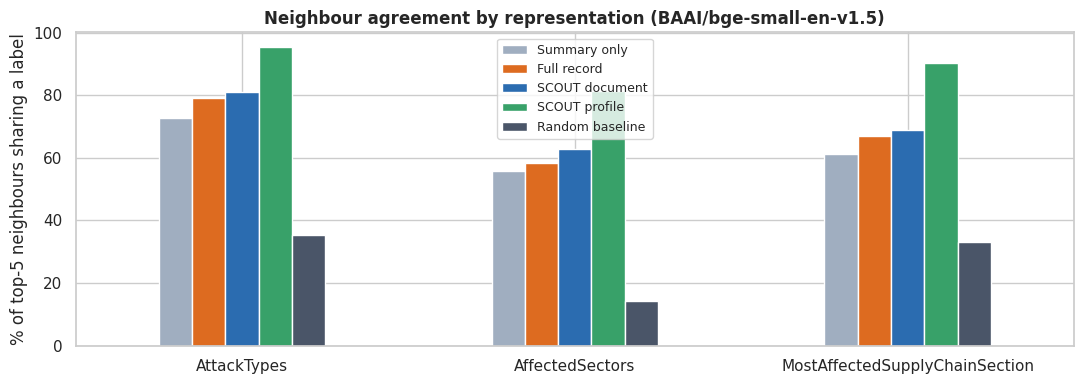

In [46]:
# --- Check 1: neighbour agreement vs random ---
K = 5
rng = np.random.default_rng(RANDOM_STATE)
AGREE_FIELDS = ["AttackTypes", "AffectedSectors", "MostAffectedSupplyChainSection"]
label_sets = {f: [set(l) for l in df[f"{f}_list"]] for f in AGREE_FIELDS}

def neighbour_agreement(E, k=K):
    S = E @ E.T; np.fill_diagonal(S, -1)
    top = np.argsort(-S, axis=1)[:, :k]
    out = {}
    for f, L in label_sets.items():
        ok = [i for i in range(len(L)) if L[i]]
        out[f] = np.mean([np.mean([bool(L[i] & L[j]) for j in top[i]]) for i in ok]) * 100
    return out

agree = pd.DataFrame({name: neighbour_agreement(E) for name, E in EMB.items()}).T
random_rows = {}
for f, L in label_sets.items():
    ok = [i for i in range(len(L)) if L[i]]
    random_rows[f] = np.mean([np.mean([bool(L[i] & L[j]) for j in rng.choice(len(L), K, replace=False)]) for i in ok]) * 100
agree.loc["Random baseline"] = random_rows
agree = agree.round(1)
display(agree.rename(columns=lambda c: f"{c}: % of top-{K} sharing a label"))

fig, ax = plt.subplots(figsize=(11, 4))
agree.T.plot.bar(ax=ax, color=[GREY, ORANGE, BLUE, "#38a169", SLATE], rot=0)
ax.set_ylabel(f"% of top-{K} neighbours sharing a label"); ax.set_title(f"Neighbour agreement by representation ({EMBED_BACKEND})")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

Example query: We are an organization in finance and insurance. Our critical supply-chain area is service delivery. Key business functions: information technology, customer service. We worry about incidents causing service unavailability, service degradation.


,same sector %,same supply-chain area %,impact Jaccard
Summary only,27.2,43.4,0.20
Full record,33.0,52.0,0.21
SCOUT document,29.2,44.2,0.22
SCOUT profile,80.0,90.3,0.49
TF-IDF on SCOUT document (lexical baseline),72.4,80.9,0.48
Random baseline,16.0,34.8,0.29


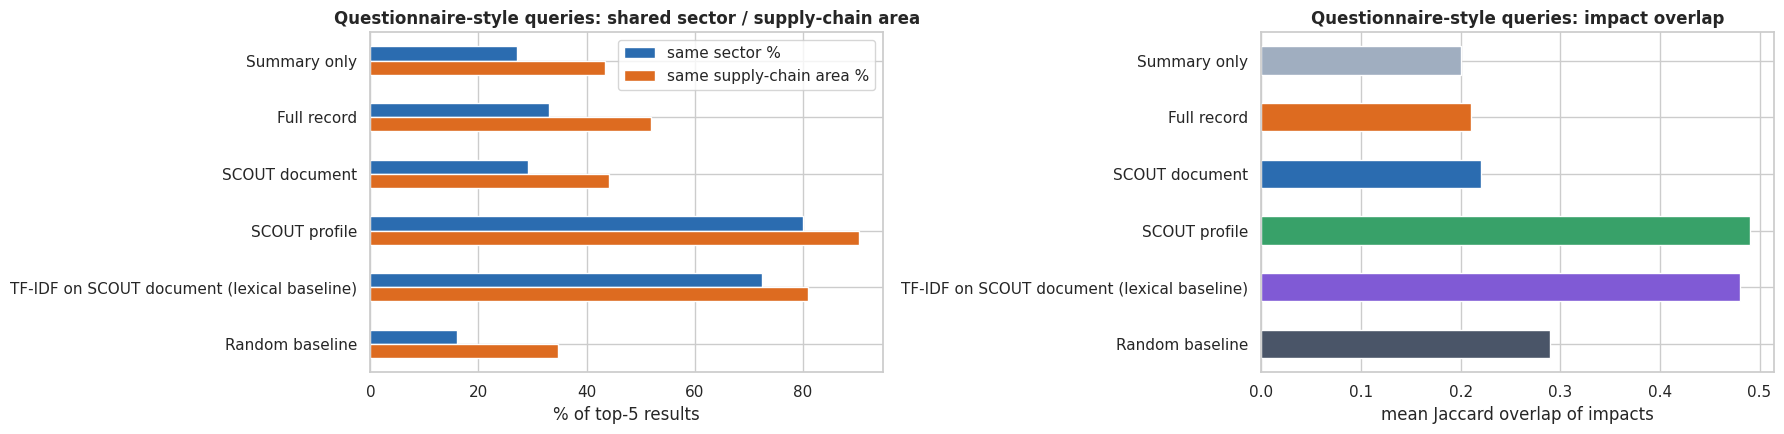

In [47]:
# --- Check 2: questionnaire-style queries built only from profile + consequence labels ---
def questionnaire_query(row):
    parts = []
    if row["AffectedSectors_list"]:
        parts.append("We are an organization in " + ", ".join(humanize(x) for x in row["AffectedSectors_list"]) + ".")
    if row["MostAffectedSupplyChainSection_list"]:
        parts.append("Our critical supply-chain area is " + ", ".join(humanize(x) for x in row["MostAffectedSupplyChainSection_list"]) + ".")
    if row["AffectedTargetedCompanyDepartments_list"]:
        parts.append("Key business functions: " + ", ".join(humanize(x) for x in row["AffectedTargetedCompanyDepartments_list"]) + ".")
    if row["ImpactTypes_list"]:
        parts.append("We worry about incidents causing " + ", ".join(humanize(x) for x in row["ImpactTypes_list"]) + ".")
    return " ".join(parts)

eligible = df.index[(df["AffectedSectors_list"].str.len() > 0) & (df["MostAffectedSupplyChainSection_list"].str.len() > 0)
                    & (df["ImpactTypes_list"].str.len() > 0)]
q_idx = rng.choice(eligible, size=min(200, len(eligible)), replace=False)
queries = [questionnaire_query(df.loc[i]) for i in q_idx]
print("Example query:", queries[0])

def jaccard(a, b):
    return len(a & b) / len(a | b) if (a | b) else 0.0

sec, sc, imp = (label_sets["AffectedSectors"], label_sets["MostAffectedSupplyChainSection"],
                [set(l) for l in df["ImpactTypes_list"]])
def score_retrieval(S_q, k=K):
    rows = []
    for r, i in enumerate(q_idx):
        s = S_q[r].copy(); s[i] = -np.inf                        # never return the source incident
        top = np.argsort(-s)[:k]
        rows.append({"same sector %": np.mean([bool(sec[i] & sec[j]) for j in top]) * 100,
                     "same supply-chain area %": np.mean([bool(sc[i] & sc[j]) for j in top]) * 100,
                     "impact Jaccard": np.mean([jaccard(imp[i], imp[j]) for j in top])})
    return pd.DataFrame(rows).mean()

retrieval = {}
for name, E in EMB.items():
    retrieval[name] = score_retrieval(QUERY_ENCODERS[name](queries) @ E.T)
tfidf_doc = TfidfVectorizer(stop_words="english", sublinear_tf=True).fit(df["doc_scout"])
retrieval["TF-IDF on SCOUT document (lexical baseline)"] = score_retrieval(
    cosine_similarity(tfidf_doc.transform(queries), tfidf_doc.transform(df["doc_scout"])))
rand = [rng.choice(np.setdiff1d(np.arange(len(df)), [i]), K, replace=False) for i in q_idx]
retrieval["Random baseline"] = pd.DataFrame([{"same sector %": np.mean([bool(sec[i] & sec[j]) for j in t]) * 100,
                                              "same supply-chain area %": np.mean([bool(sc[i] & sc[j]) for j in t]) * 100,
                                              "impact Jaccard": np.mean([jaccard(imp[i], imp[j]) for j in t])}
                                             for i, t in zip(q_idx, rand)]).mean()
retrieval = pd.DataFrame(retrieval).T.round(2)
display(retrieval)

fig, axes = plt.subplots(1, 2, figsize=(18, 4.5))
order = retrieval.index.tolist()
colors = [GREY, ORANGE, BLUE, "#38a169", "#805ad5", SLATE]
retrieval[["same sector %", "same supply-chain area %"]].plot.barh(ax=axes[0], color=[BLUE, ORANGE])
axes[0].invert_yaxis(); axes[0].set_xlabel(f"% of top-{K} results"); axes[0].set_title("Questionnaire-style queries: shared sector / supply-chain area")
retrieval["impact Jaccard"].plot.barh(ax=axes[1], color=colors[:len(order)])
axes[1].invert_yaxis(); axes[1].set_xlabel("mean Jaccard overlap of impacts"); axes[1].set_title("Questionnaire-style queries: impact overlap")
plt.tight_layout(); plt.show()

### Interpretation

**Neighbour agreement.** With the summary alone, **72.8%** of each incident's five nearest neighbours share an attack type (random: 35.5%), **55.8%** share a sector (random: 14.3%) and **61.1%** share a supply-chain section (random: 33.1%). The narrative therefore carries meaningful similarity information by itself. Adding labels raises agreement — full record 79.0 / 58.4 / 67.0, SCOUT document **81.0 / 62.7 / 68.9** — so the SCOUT document outperforms the full record on all three evaluated labels while being 27% shorter. Removing company names, dates, actors and raw codes does not reduce agreement on these three labels, although the effect on other retrieval objectives has not yet been evaluated. The profile's very high values (95.3 / 81.2 / 90.4) are expected, because it consists of those labels.

**Questionnaire-style retrieval.** This is the test that matters for SCOUT, and it informs the proposed design. When the query is written as a questionnaire answer (sector, supply-chain area, functions, impacts), dense vectors of *narrative* documents perform poorly: the SCOUT document returns the same sector in only **29.2%** of top-5 results and the same supply-chain area in **44.2%**, barely above random (16.0% and 34.8%). A simple word-matching baseline (TF-IDF) does much better (72.4% / 80.9%). The **SCOUT profile** — the same labels in plain words, without the narrative — reaches **80.0%** same sector, **90.3%** same supply-chain area and an impact overlap of **0.49**, the best of all representations.

The results suggest a mismatch between query and document formats: a questionnaire answer is a short list of attributes, whereas an incident summary is a narrative about a specific company. For the next SCOUT prototype, we **propose testing a dual-vector architecture**: a **profile vector** to match structured questionnaire answers and a **narrative vector** (SCOUT document) to retrieve relevant incident descriptions and support explanations. Their scores could be combined, with severity and reliability considered as additional ranking factors. These findings are based on within-dataset proxies derived from TRACE labels, not on independently validated retrieval performance. Before adopting this architecture, the team should evaluate it against a small set of realistic questionnaire responses with human-judged relevant incidents and compare it with simpler retrieval baselines.


## 4.10 PCA and clustering of the SCOUT documents
PCA projects the 384-dimensional embeddings onto two axes for inspection (most variance is *not* captured in two dimensions, so overlap in the plot does not mean overlap in the full space). K-means groups the incidents; each group is described by its distinctive words and its dominant sector and supply-chain area.

Variance explained by PC1 + PC2: 11.4%


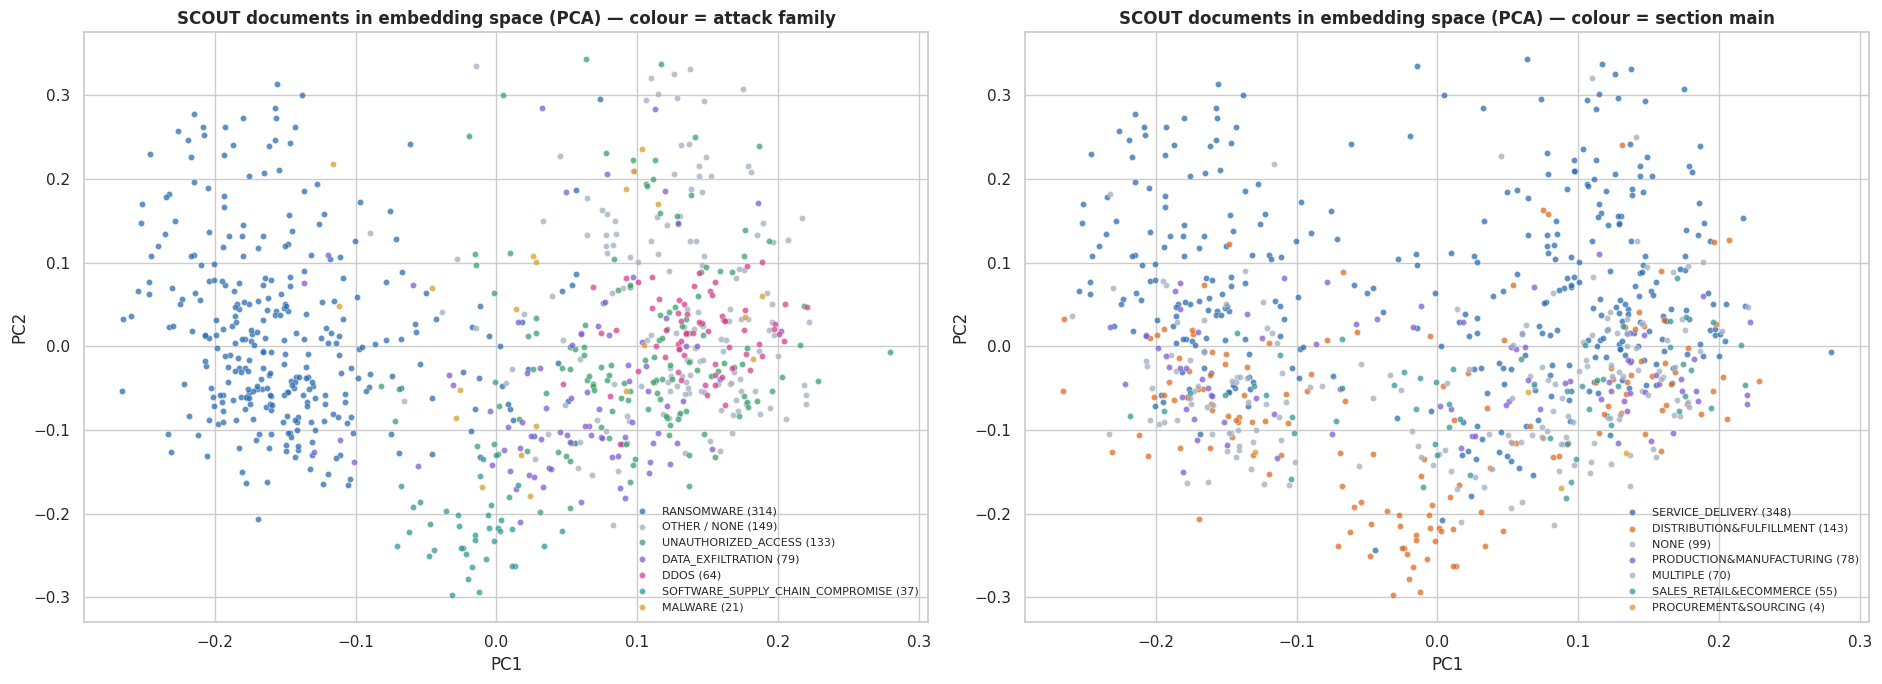

In [48]:
E_doc = EMB["SCOUT document"]
pca = PCA(n_components=2, random_state=RANDOM_STATE)
xy = pca.fit_transform(E_doc)
print(f"Variance explained by PC1 + PC2: {pca.explained_variance_ratio_.sum():.1%}")

# Deterministic 'attack family' per incident (priority order, instead of 'first label listed')
FAMILY_ORDER = ["RANSOMWARE", "DDOS", "SOFTWARE_SUPPLY_CHAIN_COMPROMISE", "DATA_EXFILTRATION", "MALWARE", "UNAUTHORIZED_ACCESS"]
df["attack_family"] = df["AttackTypes_list"].apply(lambda l: next((f for f in FAMILY_ORDER if f in l), "OTHER / NONE"))
df["section_main"] = df["MostAffectedSupplyChainSection_list"].apply(lambda l: l[0] if len(l) == 1 else ("MULTIPLE" if l else "NONE"))

fig, axes = plt.subplots(1, 2, figsize=(19, 7))
for ax, col in zip(axes, ["attack_family", "section_main"]):
    cats = df[col].value_counts().index.tolist()
    for c in cats:
        m = (df[col] == c).values
        color = GREY if c in ("OTHER / NONE", "NONE", "MULTIPLE") else CAT[cats.index(c) % len(CAT)]
        ax.scatter(xy[m, 0], xy[m, 1], s=20, alpha=0.75, color=color, label=f"{c} ({m.sum()})", edgecolor="white", linewidth=0.3)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(fontsize=8, frameon=False)
    ax.set_title(f"SCOUT documents in embedding space (PCA) — colour = {col.replace('_', ' ')}")
plt.tight_layout(); plt.show()

,incidents,distinctive words,top sector (share),top supply-chain area (share),median severity
cluster,,,,,
0,59,"trojanized, token, software-supply-chain, moveit, pypi, poisoned, packages, capable",TECHNOLOGY_AND_IT_SERVICES (69%),DISTRIBUTION&FULFILLMENT (61%),70.0
1,67,"ddos, attacks, denial-of-service, repeatedly, traffic, distributed, large, campaign",TELECOMMUNICATIONS (24%),SERVICE_DELIVERY (76%),67.0
2,77,"wi-fi, hall, classes, municipality, district, county, in-person, reopened",GOVERNMENT_AND_PUBLIC_ADMINISTRATION (73%),SERVICE_DELIVERY (88%),73.0
3,100,"near, order, stores, canadian, deliveries, shipping, manufacturing, store",MANUFACTURING (33%),DISTRIBUTION&FULFILLMENT (43%),73.0
4,80,"residents, city, school, public-facing, schools, council, county, education",GOVERNMENT_AND_PUBLIC_ADMINISTRATION (66%),SERVICE_DELIVERY (88%),70.0
5,155,"destructive, protocol, databases, trading, guatemala, announced, assets, feb",GOVERNMENT_AND_PUBLIC_ADMINISTRATION (39%),SERVICE_DELIVERY (39%),67.0
6,82,"outpatient, hospitalier, ambulances, imaging, laboratory, elective, patient, hospital",HEALTHCARE_AND_PUBLIC_HEALTH (96%),SERVICE_DELIVERY (61%),76.0
7,177,"products, companies, ransomhub, rica, technologies, handling, costa, halting",GOVERNMENT_AND_PUBLIC_ADMINISTRATION (19%),DISTRIBUTION&FULFILLMENT (37%),70.0


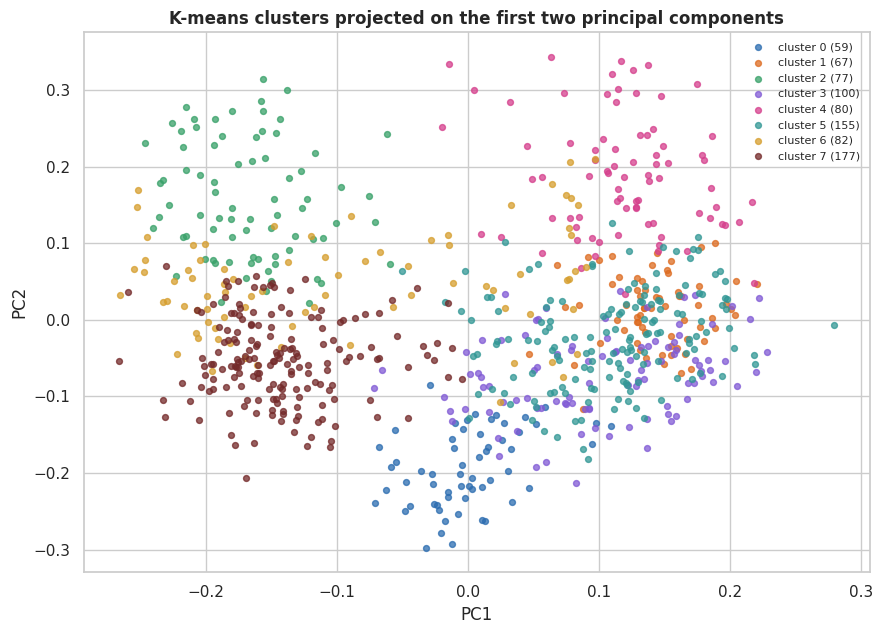

In [49]:
# --- K-means clusters described by distinctive words, dominant sector and supply-chain area ---
K_CLUSTERS = 8
km = KMeans(n_clusters=K_CLUSTERS, n_init=10, random_state=RANDOM_STATE).fit(E_doc)
df["cluster"] = km.labels_

cv = CountVectorizer(stop_words="english", token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z\-]{2,}\b", min_df=5)
W = cv.fit_transform(df["Summary_clean"]); words = np.array(cv.get_feature_names_out())
global_rate = np.asarray(W.sum(axis=0)).ravel() / W.sum()
rows = []
for c in range(K_CLUSTERS):
    m = (df["cluster"] == c).values
    rate = np.asarray(W[m].sum(axis=0)).ravel() / max(W[m].sum(), 1)
    lift = np.where(np.asarray(W[m].sum(axis=0)).ravel() >= 5, rate / global_rate, 0)
    top_sector  = df.loc[m, "AffectedSectors_list"].explode().value_counts()
    top_section = df.loc[m, "MostAffectedSupplyChainSection_list"].explode().value_counts()
    rows.append({"cluster": c, "incidents": int(m.sum()),
                 "distinctive words": ", ".join(words[np.argsort(-lift)[:8]]),
                 "top sector (share)": f"{top_sector.index[0]} ({top_sector.iloc[0] / m.sum():.0%})",
                 "top supply-chain area (share)": f"{top_section.index[0]} ({top_section.iloc[0] / m.sum():.0%})" if len(top_section) else "-",
                 "median severity": df.loc[m, "EstimatedSeverity"].median()})
clusters = pd.DataFrame(rows).set_index("cluster")
display(clusters)

fig, ax = plt.subplots(figsize=(9, 6.5))
for c in range(K_CLUSTERS):
    m = (df["cluster"] == c).values
    ax.scatter(xy[m, 0], xy[m, 1], s=18, alpha=0.75, color=CAT[c % len(CAT)], label=f"cluster {c} ({m.sum()})")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(fontsize=8, frameon=False)
ax.set_title("K-means clusters projected on the first two principal components")
plt.tight_layout(); plt.show()

### Interpretation

The first two principal components explain only **11.4%** of the variance, so the projection is a rough map. It still shows clear structure. The first component separates **ransomware** incidents (a dense region on the left) from the rest; **DDoS** incidents form a compact group on the right and **software-supply-chain compromises** a separate group at the bottom, which coincides with the distribution & fulfillment incidents in the right-hand panel. Service-delivery incidents are spread across most of the map, consistent with it being the default section for public services.

K-means makes the structure explicit with eight interpretable groups: **software-supply-chain campaigns** (59 incidents; `trojanized`, `pypi`, `packages`; 69% technology sector; 61% distribution & fulfillment), **DDoS campaigns** (67; 76% service delivery), **hospitals** (82; 96% healthcare; highest median severity, 76), two **local-government / school** groups (77 and 80; ~88% service delivery), **retail, manufacturing and shipping** (100; distribution & fulfillment) and two broader mixed groups (155 and 177) that include the Latin American government incidents. The clusters follow sector and type of operation more than attack type, which supports using the profile (sector, area, functions) as the primary matching signal.

## 4.11 Retrieval demonstration
Two questionnaire-like descriptions are matched against the reference base. This previews SCOUT's output; it is not an evaluation.

In [50]:
DEMO_QUERIES = [
    "A manufacturing company suffers ransomware that disrupts production, order processing and distribution.",
    "We are a logistics and transportation company in Mexico; our warehouse and shipping systems depend on a third-party software vendor.",
]
enc = QUERY_ENCODERS["SCOUT document"]
ref = df.index[df["in_reference_base"]]
for q in DEMO_QUERIES:
    sims = (enc([q]) @ EMB["SCOUT document"][ref].T).ravel()
    top = ref[np.argsort(-sims)[:5]]
    print(f"\nQUERY: {q}")
    display(df.loc[top, ["IncidentTitle", "CountryTargetedCompany", "AffectedSectors_canonical",
                         "MostAffectedSupplyChainSection_canonical", "EstimatedSeverity", "ReliabilityScore"]]
            .assign(similarity=np.sort(sims)[::-1][:5].round(3)))


QUERY: A manufacturing company suffers ransomware that disrupts production, order processing and distribution.


,IncidentTitle,CountryTargetedCompany,AffectedSectors_canonical,MostAffectedSupplyChainSection_canonical,EstimatedSeverity,ReliabilityScore,similarity
49,Ransomware causes production delays at FINCANTIERI MARINETTE MARINE,USA,MANUFACTURING,PRODUCTION&MANUFACTURING,55,88.0,0.786
655,Ransomware cripples Fasana production and contributes to insolvency,DEU,MANUFACTURING,"DISTRIBUTION&FULFILLMENT, PRODUCTION&MANUFACTURING",96,82.0,0.784
668,Ransomware halts Siloking production,DEU,MANUFACTURING,PRODUCTION&MANUFACTURING,80,94.0,0.782
30,Ransomware halts ASAHI GROUP HOLDINGS orders and shipments in Japan,JPN,"FOOD_AND_BEVERAGE, LOGISTICS_AND_WAREHOUSING, RETAIL","DISTRIBUTION&FULFILLMENT, PRODUCTION&MANUFACTURING",85,89.0,0.769
671,Ransomware disrupts multiple Dairy Farmers of America manufacturing plants,USA,"FOOD_AND_BEVERAGE, MANUFACTURING",PRODUCTION&MANUFACTURING,77,91.0,0.766



QUERY: We are a logistics and transportation company in Mexico; our warehouse and shipping systems depend on a third-party software vendor.


,IncidentTitle,CountryTargetedCompany,AffectedSectors_canonical,MostAffectedSupplyChainSection_canonical,EstimatedSeverity,ReliabilityScore,similarity
100,Mexico port platform PIS outage and data leak impairs cargo releases at Manzanillo,MEX,"GOVERNMENT_AND_PUBLIC_ADMINISTRATION, LOGISTICS_AND_WAREHOUSING, TRANSPORTATION",DISTRIBUTION&FULFILLMENT,78,89.0,0.635
318,Checkmarx supply-chain compromise publishes malicious developer artifacts across March-May,ISR,TECHNOLOGY_AND_IT_SERVICES,DISTRIBUTION&FULFILLMENT,84,94.0,0.629
172,De Bijenkorf notifies customers after CEVA Logistics breach,NLD,RETAIL,"DISTRIBUTION&FULFILLMENT, SALES_RETAIL&ECOMMERCE",52,86.0,0.628
349,Compromised eScan update infrastructure distributes malicious software to customers,IND,TECHNOLOGY_AND_IT_SERVICES,DISTRIBUTION&FULFILLMENT,70,90.0,0.624
120,México CNSF confirma incidente; prórroga de vigencia de registros tras vulneración,MEX,GOVERNMENT_AND_PUBLIC_ADMINISTRATION,DISTRIBUTION&FULFILLMENT,50,93.0,0.621


### Interpretation

For a narrative query ("a manufacturing company suffers ransomware that disrupts production, order processing and distribution"), all five results are manufacturing ransomware incidents with production impact — Fincantieri Marinette Marine, Fasana, Siloking, Asahi and Dairy Farmers of America — with similarities of 0.77–0.79. For the Mexican logistics query, the top result is the Manzanillo port-platform outage in Mexico, followed by software-supply-chain compromises and a logistics-provider breach. This illustrates both strengths and limits: the narrative vector captures *what happened*, but country is matched only loosely, so the retrieval stage should apply country and reliability as explicit preferences rather than hoping the embedding encodes them.

In [51]:
# --- Optional hand-off to the retrieval notebook (uncomment to write the files) ---
EXPORT_COLS = ["incidentId", "IncidentTitle_clean", "doc_scout", "CountryTargetedCompany", "AffectedCountries_canonical",
               "incident_date", "EstimatedSeverity", "ReliabilityScore", "MainSources", "in_reference_base"] + FLAG_COLS
# df[EXPORT_COLS].to_json("scout_incident_documents.jsonl", orient="records", lines=True, force_ascii=False, date_format="iso")
# np.save("scout_doc_embeddings.npy", EMB["SCOUT document"])
print(f"Export prepared: {len(EXPORT_COLS)} columns x {len(df)} incidents (files are written only if uncommented).")

Export prepared: 20 columns x 797 incidents (files are written only if uncommented).


# Part 5 — Conclusions

The decision log links each data finding to the preprocessing action it motivated; the metrics table recomputes the key numbers from the data; the conclusions and the feedback for the dataset creators summarize what the analysis means for SCOUT and for TRACE.

## 5.1 Preprocessing decision log

In [52]:
decision_log = pd.DataFrame([
    ("Delimiter / encoding", "Current export is comma-delimited UTF-8; an old Excel re-save was ';'-delimited",
     "Sniff the delimiter; utf-8-sig; schema guard", "The notebook reads either version and fails loudly on schema changes"),
    ("Dates", "dd/mm/yyyy text (§7.6); default parsing swaps day and month",
     "Explicit day-first parser + plausibility window", "0 out-of-range dates; Colonial Pipeline = 2021-05-07"),
    ("Missing values", "Sparse fields (FinancialImpact 94%, SupplyChainRelations 90%, actors 75%, duration 74%)",
     "Keep NaN; omit from documents; no imputation", "§7.20: defensibility over completeness; imputation invents facts"),
    ("Outliers", "IQR flags in every numeric field (e.g. Change Healthcare USD 3,090M)",
     "Flag (iqr_outlier_*) and retain", "Extreme incidents are real and relevant to SCOUT"),
    ("Label formatting", "', ' vs ',' separators; label order varies",
     "Split, strip, de-duplicate, sort (label sets)", "Raw combinations shrink without losing any label"),
    ("Taxonomy conformity", "25 records with off-catalog labels; OTHER(SERVICE_DELIVERY) duplicates a frozen code",
     "Remap redundant OTHER(...) to the frozen code; flag the rest; never merge distinct codes",
     "Spec §8.4, §8.7, §14"),
    ("Duplicates", "No exact duplicates; 13 TF-IDF pairs and same-company/other-country records describe one event twice",
     "flag_near_duplicate; reference base keeps one member", "Prevents top-k from showing the same case twice"),
    ("Evidence quality", "100 published records below the TRACE-ready threshold; 47 unscored",
     "flag_below_reliability_85; optional filter", "Lets SCOUT down-rank or hide weakly supported cases"),
    ("Typographic characters", "Non-breaking hyphens inside domain terms (third‑party, zero‑day, CVE‑…)",
     "NFKC + map all dash/quote variants to ASCII; remove URLs; keep case, accents, numbers",
     "Domain terms become matchable; no information removed"),
    ("Text normalization depth", "Transformer tokenizer handles case and morphology; stemming breaks domain terms",
     "No stemming, lemmatization or stop-word removal in semantic text", "Those steps are used only for exploratory counts"),
    ("Document design", "Full records add company names, dates, numbers and raw codes; dense vectors of narrative documents match label-style questionnaire queries poorly",
     "Two vectors per incident: SCOUT document (narrative + labels) and SCOUT profile (labels in plain words); the rest as metadata",
     "Retrieval comparison in Part 4.9"),
    ("Length / chunking", "Documents fit the model window (see Part 4.8)",
     "One vector per incident, no chunking", "Chunking would split incidents without benefit"),
    ("Class imbalance", "No supervised target", "No resampling; imbalance reported descriptively",
     "Affects what can be retrieved, not a training objective"),
], columns=["issue", "evidence", "action", "justification"])
display(decision_log)

,issue,evidence,action,justification
0,Delimiter / encoding,Current export is comma-delimited UTF-8; an old Excel re-save was ';'-delimited,Sniff the delimiter; utf-8-sig; schema guard,The notebook reads either version and fails loudly on schema changes
1,Dates,dd/mm/yyyy text (§7.6); default parsing swaps day and month,Explicit day-first parser + plausibility window,0 out-of-range dates; Colonial Pipeline = 2021-05-07
2,Missing values,"Sparse fields (FinancialImpact 94%, SupplyChainRelations 90%, actors 75%, duration 74%)",Keep NaN; omit from documents; no imputation,§7.20: defensibility over completeness; imputation invents facts
3,Outliers,"IQR flags in every numeric field (e.g. Change Healthcare USD 3,090M)",Flag (iqr_outlier_*) and retain,Extreme incidents are real and relevant to SCOUT
4,Label formatting,"', ' vs ',' separators; label order varies","Split, strip, de-duplicate, sort (label sets)",Raw combinations shrink without losing any label
5,Taxonomy conformity,25 records with off-catalog labels; OTHER(SERVICE_DELIVERY) duplicates a frozen code,Remap redundant OTHER(...) to the frozen code; flag the rest; never merge distinct codes,"Spec §8.4, §8.7, §14"
6,Duplicates,No exact duplicates; 13 TF-IDF pairs and same-company/other-country records describe one event twice,flag_near_duplicate; reference base keeps one member,Prevents top-k from showing the same case twice
7,Evidence quality,100 published records below the TRACE-ready threshold; 47 unscored,flag_below_reliability_85; optional filter,Lets SCOUT down-rank or hide weakly supported cases
8,Typographic characters,"Non-breaking hyphens inside domain terms (third‑party, zero‑day, CVE‑…)","NFKC + map all dash/quote variants to ASCII; remove URLs; keep case, accents, numbers",Domain terms become matchable; no information removed
9,Text normalization depth,Transformer tokenizer handles case and morphology; stemming breaks domain terms,"No stemming, lemmatization or stop-word removal in semantic text",Those steps are used only for exploratory counts


## 5.2 Key metrics (recomputed on every run)

In [53]:
pct = lambda x: round(float(x) * 100, 1)
metrics = {
    "Rows x raw columns":                          f"{len(df_raw)} x {df_raw.shape[1]}",
    "Exact duplicate rows / duplicate IDs":        f"{df_raw.duplicated().sum()} / {df_raw['incidentId'].duplicated().sum()}",
    "Incident-date coverage (%)":                  pct(df["incident_date"].notna().mean()),
    "Incidents dated 2024–2026 (% of dated)":      pct(df["incident_year"].isin([2024, 2025, 2026]).sum() / df["incident_date"].notna().sum()),
    "Summary coverage (%)":                        pct(df["Summary"].notna().mean()),
    "Fields with >= 50% missing":                  int((df_raw.isna().mean() >= 0.5).sum()),
    "AttackTypes / ImpactTypes coverage (%)":      f"{pct(df['AttackTypes'].notna().mean())} / {pct(df['ImpactTypes'].notna().mean())}",
    "Missing required ImpactTypes / Section":      f"{int(df['flag_missing_required_impact'].sum())} / {int(df['flag_missing_required_section'].sum())}",
    "Records with off-catalog labels":             int(df["flag_off_catalog_label"].sum()),
    "TRACE-ready, ReliabilityScore >= 85 (% of scored)": pct((df["ReliabilityScore"] >= 85).sum() / df["ReliabilityScore"].notna().sum()),
    "Identity-key repeats / same company, other country (records)": f"{int(df['identity_key_repeat'].sum())} / {len(cross_country)}",
    f"Near-duplicate summary pairs (cos >= {THRESH})": len(near),
    "USA share of targeted companies (%)":         pct((df["CountryTargetedCompany"] == "USA").mean()),
    "Incidents affecting Mexico":                  len(mx),
    "Records naming an entry vector (%)":          pct(df["has_vector_label"].mean()),
    "Summaries with a root-cause cue (%)":         pct(rc.any(axis=1).mean()),
    "Summaries with typographic dashes (%)":       pct(df["Summary"].str.contains(DASH_CLASS).mean()),
    "Questionnaire queries, same sector in top-5 (%): profile / SCOUT doc / random":
        f"{retrieval.loc['SCOUT profile', 'same sector %']} / {retrieval.loc['SCOUT document', 'same sector %']} / {retrieval.loc['Random baseline', 'same sector %']}",
    "Median model tokens: Summary / SCOUT doc / Full record":
        f"{tok['Summary (model tokens)'].median():.0f} / {tok['SCOUT doc (model tokens)'].median():.0f} / {tok['Full record (model tokens)'].median():.0f}",
    "Embedding backend":                           EMBED_BACKEND,
    "Reference base for top-k":                    int(df["in_reference_base"].sum()),
}
pd.Series(metrics, name="value").to_frame()

,value
Rows x raw columns,797 x 28
Exact duplicate rows / duplicate IDs,0 / 0
Incident-date coverage (%),98.9
Incidents dated 2024–2026 (% of dated),79.6
Summary coverage (%),100.0
Fields with >= 50% missing,6
AttackTypes / ImpactTypes coverage (%),84.2 / 95.9
Missing required ImpactTypes / Section,33 / 99
Records with off-catalog labels,25
"TRACE-ready, ReliabilityScore >= 85 (% of scored)",86.7


## 5.3 Conclusions

1. **The dataset is structurally sound.** 797 incidents × 28 variables, no exact duplicates, unique IDs, complete titles and summaries, day-first dates parsed with 98.9% coverage and none out of range.
2. **Missingness is concentrated in optional fields.** Six fields are ≥ 50% empty (financial impact 94%, supply-chain relations 90%, actors 75%, duration 74%), while the fields SCOUT needs are 84–100% complete. Gaps reflect the spec's "defensibility over completeness" rule; nothing is imputed.
3. **The taxonomy mostly conforms to the spec.** 25 records carry off-catalog or redundant labels (20 of them `OTHER(SERVICE_DELIVERY)`), 33 lack the required impact types and 99 the required supply-chain section; 86.7% of scored records are TRACE-ready.
4. **Thirteen events are recorded twice**, and three companies (LKQ, Radiant Logistics, Sensata) appear twice under different target countries. Flagging them leaves a reference base of 784 incidents.
5. **The content is concentrated**: 80% of incidents date from 2024–2026, 34% of targeted companies are American and only 17 incidents affect Mexico; government, technology and healthcare dominate the sectors, and service delivery dominates the supply-chain sections.
6. **Attacks have recognisable consequence profiles**: ransomware → operational disruption (82.5%), DDoS → service unavailability (86.2%), software-supply-chain compromise → supply-chain data-integrity impact (94.7%) and distribution & fulfillment (89.5%). Sectors have distinct attack mixes (healthcare and logistics ransomware-heavy, technology supply-chain-heavy, telecom DDoS-heavy).
7. **TRACE documents consequences, not root causes.** Only 16.3% of summaries mention how the attacker got in and 13.7% of records carry an entry-vector label, by design of the eligibility rules. SCOUT's questionnaire should therefore match on sector, supply-chain area, business functions and feared impacts; questions about security controls need another source or a separate scoring layer.
8. **Text needs light, targeted cleaning only.** There is no encoding corruption; the issue is typographic (non-breaking hyphens inside `third‑party`, `zero‑day`, CVE IDs), fixed by mapping dashes and quotes and removing URLs while keeping case, accents and numbers. Stemming, lemmatization and stop-word removal are kept out of the semantic text.
9. **Every incident fits the embedding model in one piece** (SCOUT document median 132 tokens, maximum 280), so no chunking is needed.
10. **The embedding experiments suggest that a dual-vector architecture may be appropriate for SCOUT**, using structured incident profiles to match questionnaire responses and narrative documents to retrieve contextual evidence. However, this remains a proposed design rather than a validated solution. The next phase should evaluate retrieval performance using realistic questionnaire responses, human-judged relevant incidents and comparisons with simpler baselines, including TF-IDF. Severity and reliability may subsequently be incorporated as additional ranking factors.

## 5.4 Feedback for the dataset creators (MIT TRACE)

These observations are offered as constructive feedback to the TRACE maintainers. Each is tied to a rule in their own specification, and the table below gives the count and an example.

1. **Catalog conformity.** `OTHER(SERVICE_DELIVERY)` appears in 20 records of `MostAffectedSupplyChainSection`, a field where `OTHER` is forbidden and `SERVICE_DELIVERY` is a frozen code; three sector codes are also written as `OTHER(...)`. Three values belong to no catalog (`DOWNSTREAM`, apparently truncated; `SUBSIDIARY` and `PARENT_ORGANIZATION` as supply-chain roles). A validation step against §14 before publication would catch all of them.
2. **Required fields on published records.** 33 published incidents have no `ImpactTypes` and 99 no supply-chain section, although §7.10 and §7.12 make both mandatory for eligible incidents.
3. **Reliability on published records.** 100 published incidents score below the TRACE-ready threshold and 47 have no score. If this is intended (reliability distinct from eligibility, §10.6), exposing the score to users would help them weigh each case.
4. **Duplicate control.** 13 pairs describe the same event (same date and victim, paraphrased text), and three companies appear twice with different `CountryTargetedCompany` values for the same incident, which defeats the identity key of §12.2. Adding title/summary similarity and a company-only check to the expansion step would catch these.
5. **Serialization.** Label separators alternate between `,` and `, ` within the same field, 37 region values break the `REGION(ISO3)` convention (§7.16), and summaries use non-breaking hyphens (U+2011) inside domain terms, which breaks keyword search. Normalizing these at export time would make the data easier to reuse.
6. **Coverage.** 17 of 49 attack types and 13 of 28 supply-chain roles never occur, and only 17 incidents affect Mexico. Research requests targeting Latin America and the unused attack mechanisms (e.g. phishing-led or business-email-compromise incidents with operational consequences) would broaden the dataset's usefulness.

In [54]:
# --- Evidence behind the feedback: every issue with its count and an example ---
def example(mask, col="IncidentTitle"):
    return df.loc[mask, col].iloc[0] if mask.any() else "-"

feedback = pd.DataFrame([
    ("Redundant OTHER(...) for frozen codes", "§8.7, §14",
     int(df["off_catalog_labels"].apply(lambda l: any("OTHER(" in x for x in l)).sum()),
     "OTHER(SERVICE_DELIVERY), OTHER(FUNERAL_SERVICES) ..."),
    ("Labels outside every catalog", "§14",
     int(df["off_catalog_labels"].apply(lambda l: any("OTHER(" not in x for x in l)).sum()),
     "ImpactTypes: DOWNSTREAM; roles: SUBSIDIARY, PARENT_ORGANIZATION"),
    ("Missing required ImpactTypes", "§7.10", int(df["flag_missing_required_impact"].sum()),
     example(df["flag_missing_required_impact"])),
    ("Missing required MostAffectedSupplyChainSection", "§7.12", int(df["flag_missing_required_section"].sum()),
     example(df["flag_missing_required_section"])),
    ("Published below the TRACE-ready threshold", "§10.4", int((df["ReliabilityScore"] < 85).sum()),
     example(df["ReliabilityScore"] < 85)),
    ("Published without a ReliabilityScore", "§10.1", int(df["ReliabilityScore"].isna().sum()),
     example(df["ReliabilityScore"].isna())),
    ("Same event recorded twice (TF-IDF near-duplicates)", "§12.3–12.4", len(near),
     f"{near.iloc[0]['title_a']}  ||  {near.iloc[0]['title_b']}" if len(near) else "-"),
    ("Same company under different target countries", "§7.5, §12.2", len(cross_country),
     ", ".join(sorted(cross_country["TargetedCompany"].unique()))),
    ("ImpactedGeographicRegions not in REGION(ISO3)", "§7.16", len(bad_regions),
     ", ".join(bad_regions.value_counts().head(3).index)),
    ("AdditionalSources empty on published records", "§6.3", int(df["AdditionalSources"].isna().sum()),
     example(df["AdditionalSources"].isna())),
    ("Inconsistent separators in label fields (', ' vs ',')", "serialization",
     int(df["ImpactTypes"].dropna().str.contains(r",\s").sum()), "ImpactTypes cells using ', '"),
    ("Non-breaking hyphens inside domain terms", "serialization",
     int(df["Summary"].str.contains("\u2011").sum()), "third‑party, zero‑day, CVE‑2023‑34362"),
], columns=["issue", "spec reference", "records", "example"])
display(feedback)

,issue,spec reference,records,example
0,Redundant OTHER(...) for frozen codes,"§8.7, §14",22,"OTHER(SERVICE_DELIVERY), OTHER(FUNERAL_SERVICES) ..."
1,Labels outside every catalog,§14,3,"ImpactTypes: DOWNSTREAM; roles: SUBSIDIARY, PARENT_ORGANIZATION"
2,Missing required ImpactTypes,§7.10,33,BIMBO BAKERIES USA data breach; MEDUSA demands $6.5m
3,Missing required MostAffectedSupplyChainSection,§7.12,99,MOVEit Transfer zero-day mass data theft campaign
4,Published below the TRACE-ready threshold,§10.4,100,Ward Transport & Logistics ransomware halts operations
5,Published without a ReliabilityScore,§10.1,47,Pennington County cyber incident disrupts public services
6,Same event recorded twice (TF-IDF near-duplicates),§12.3–12.4,13,N.L. health-care cyberattack forces mass appointment cancellations; Eastern Health hit || N.L. government health I...
7,Same company under different target countries,"§7.5, §12.2",7,"FOXCONN, LKQ, RADIANT LOGISTICS, SENSATA TECHNOLOGIES"
8,ImpactedGeographicRegions not in REGION(ISO3),§7.16,37,"UNITED KINGDOM(GBR), LATIN AMERICA(AR), NEWFOUNDLAND AND LABRADOR(CAN)"
9,AdditionalSources empty on published records,§6.3,112,Ward Transport & Logistics ransomware halts operations


## 5.5 Analytical coverage and reproducibility

| Requirement | Where it is covered |
|---|---|
| **Data structure** | 1.1 roles and profile · 1.2 types and dates · 1.3 missingness (bars, matrix, co-missingness, completeness) · 1.4 duplicates and identity · 1.5 cardinality · 1.6 taxonomy audit vs spec · 1.7 reliability bands |
| **Univariate analysis** | 2.1 numeric distributions · 2.2 extreme values · 2.3 label frequencies and long tail · 2.4 time · 2.5 geography and actors · 2.6 text length, language, vocabulary, n-grams |
| **Bivariate / multivariate analysis** | 3.1 Spearman with pairwise n · 3.2 attack × impact · 3.3 sector × attack · 3.4 attack × supply-chain section · 3.5 severity by group · 3.6 attack mix over time, cross-border Sankey · 3.7 text ↔ label alignment · 3.8 near-duplicates · 4.9–4.10 embedding agreement, PCA, clusters |
| **Preprocessing** | 4.1 text audit · 4.2 cleaning · 4.3 label normalization · 4.4 missing values, outliers, cardinality, imbalance · 4.5 flags and reference base · 4.6 feature selection · 4.7 documents · 4.8 tokenization · 4.9 embeddings · 4.11 retrieval demo |
| **Conclusions** | 5.1 decision log · 5.2 metrics · 5.3 conclusions · 5.4 feedback for TRACE · 5.6 QA |

**Reproducibility protocol:** restart the runtime, run all cells top to bottom, and confirm that every QA check below passes.

## 5.6 Final sequential-execution QA

In [55]:
qa = {
    "rows loaded (797)":                        len(df_raw) == 797,
    "expected schema":                          set(EXPECTED_COLUMNS) == set(df_raw.columns),
    "incidentId complete and unique":           df_raw["incidentId"].notna().all() and df_raw["incidentId"].is_unique,
    "Summary complete":                         df_raw["Summary"].notna().all(),
    "dates parsed day-first (no future dates)": int(out_of_range.sum()) == 0,
    "source missingness preserved":             source_missing_before == source_missing_after,
    "no typographic dashes left in Summary_clean": not df["Summary_clean"].str.contains(DASH_CLASS).any(),
    "every incident has a SCOUT document":      df["doc_scout"].str.len().gt(0).all(),
    "no literal 'nan' in documents":            not df["doc_scout"].str.contains(r"\bnan\b", case=False).any(),
    "documents fit the 512-token window":       bool((tok["SCOUT doc (model tokens)"] <= 512).all()),
    "embeddings computed for every incident":   EMB["SCOUT document"].shape[0] == len(df),
}
qa_table = pd.DataFrame({"check": list(qa), "passed": list(qa.values())})
display(qa_table)
assert all(qa.values()), "One or more QA checks failed. Review the corresponding section."
print("All QA checks passed. Embedding backend:", EMBED_BACKEND)

,check,passed
0,rows loaded (797),True
1,expected schema,True
2,incidentId complete and unique,True
3,Summary complete,True
4,dates parsed day-first (no future dates),True
5,source missingness preserved,True
6,no typographic dashes left in Summary_clean,True
7,every incident has a SCOUT document,True
8,no literal 'nan' in documents,True
9,documents fit the 512-token window,True


All QA checks passed. Embedding backend: BAAI/bge-small-en-v1.5
